In [1]:
import subprocess
result = subprocess.run(
    ['python', 'dataset/build_dataset.py'],
    capture_output=True,
    text=True
)
print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)

STDOUT: 
STDERR: python: can't open file 'D:\\exoplanet-detector\\dataset\\build_dataset.py': [Errno 2] No such file or directory



In [2]:
import subprocess
result = subprocess.run(
    ['python', 'data/build_dataset.py'],
    capture_output=True,
    text=True
)
print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)

STDOUT: 
STDERR: Traceback (most recent call last):
  File "D:\exoplanet-detector\data\build_dataset.py", line 516, in <module>
    main(per_class=args.per_class, test_frac=args.test_frac, seed=args.seed)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\exoplanet-detector\data\build_dataset.py", line 443, in main
    print("\n\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550  Building Labelled Dataset  \u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\n")
    ~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python313\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode characters in position 2-11: character maps to <undefined>



In [1]:
import os
print(os.getcwd())
# Should print something like: C:\Users\you\exoplanet-detector
# You should see model/, data/, results/ from here

D:\exoplanet-detector


In [2]:
import os
print(os.listdir('model/'))
# Should print:
# ['model.py', 'dataloader.py', 'train.py', 'parameter_estimation.py']

['dataloader.py', 'model.py', 'parameter_estimation.py', 'train.py', '__init__.py']


In [3]:
import subprocess
subprocess.run(['pip', 'install', 'requests', 'pandas', 'numpy', 
                'tensorflow', 'scipy', 'astropy'])

CompletedProcess(args=['pip', 'install', 'requests', 'pandas', 'numpy', 'tensorflow', 'scipy', 'astropy'], returncode=0)

In [4]:
exec(open('build_dataset.py').read())

UnicodeDecodeError: 'charmap' codec can't decode byte 0x90 in position 416: character maps to <undefined>

In [5]:
exec(open('build_dataset.py', encoding='utf-8').read())

usage: ipykernel_launcher.py [-h] [--per-class PER_CLASS] [--test-frac TEST_FRAC] [--seed SEED]
ipykernel_launcher.py: error: unrecognized arguments: -f C:\Users\Herry\AppData\Roaming\jupyter\runtime\kernel-609c3c75-0786-438f-b5a3-743b3f862b8a.json


SystemExit: 2

C:\Users\Herry\AppData\Roaming\Python\Python313\site-packages\IPython\core\interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [1]:
exec(open('build_dataset.py', encoding='utf-8').read())

usage: ipykernel_launcher.py [-h] [--per-class PER_CLASS] [--test-frac TEST_FRAC] [--seed SEED]
ipykernel_launcher.py: error: unrecognized arguments: -f C:\Users\Herry\AppData\Roaming\jupyter\runtime\kernel-5b55a547-0509-4421-9f67-21f7a541c3a5.json


SystemExit: 2

C:\Users\Herry\AppData\Roaming\Python\Python313\site-packages\IPython\core\interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [2]:
import importlib.util, sys

# Load the file without triggering argparse
spec = importlib.util.spec_from_file_location("build_dataset", "build_dataset.py")
mod  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

# Now call main directly
mod.main(per_class=500, test_frac=0.15, seed=42)


══════════  Building Labelled Dataset  ══════════

[1/4] Confirmed planets
  Fetching NASA Exoplanet Archive (confirmed planets) ... OK  (13357 rows)


ValueError: invalid literal for int() with base 10: 'TIC 27916356'

In [3]:
import importlib.util, sys, pandas as pd, requests
from io import StringIO

# ── patch fetch_confirmed_planets inline ──────────────────────────────

spec = importlib.util.spec_from_file_location("build_dataset", "build_dataset.py")
mod  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

# Override just the broken function
def fetch_confirmed_planets_fixed(max_count=500):
    print("  Fetching NASA Exoplanet Archive (confirmed planets) ...", end=" ", flush=True)
    url = (
        "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
        "?query=select+tic_id,pl_name,sy_tmag+from+ps"
        "+where+tic_id+is+not+null"
        "+and+tran_flag=1"
        "+and+sy_tmag<13"
        "&format=csv"
    )
    try:
        r = requests.get(url, timeout=60)
        df = pd.read_csv(StringIO(r.text), comment="#")
        print(f"OK  ({len(df)} rows)")
        
        df = df.dropna(subset=["tic_id"])
        
        # Fix: strip "TIC " prefix if present
        df["tic_id"] = df["tic_id"].astype(str).str.replace("TIC ", "", regex=False).str.strip()
        df["tic_id"] = pd.to_numeric(df["tic_id"], errors="coerce")
        df = df.dropna(subset=["tic_id"])
        df["tic_id"] = df["tic_id"].astype(int)
        df = df.drop_duplicates("tic_id")
        
        if "sy_tmag" in df.columns:
            df = df.sort_values("sy_tmag").head(max_count)
        else:
            df = df.head(max_count)

        result = pd.DataFrame({
            "TIC_ID":     df["tic_id"].values,
            "label":      0,
            "class_name": "planet",
            "source":     "NASA_Exoplanet_Archive",
            "name":       df.get("pl_name", pd.Series([""] * len(df))).values,
        })
        print(f"  → {len(result)} confirmed planets")
        return result
    except Exception as e:
        print(f"FAILED ({e}) — using fallback")
        return mod._fallback_planets()

# Patch it in
mod.fetch_confirmed_planets = fetch_confirmed_planets_fixed

# Now run
mod.main(per_class=500, test_frac=0.15, seed=42)


══════════  Building Labelled Dataset  ══════════

[1/4] Confirmed planets
  Fetching NASA Exoplanet Archive (confirmed planets) ... OK  (13357 rows)
  → 500 confirmed planets

[2/4] Eclipsing binaries
  Fetching Vizier TESS EB catalogue (Prsa+2022) ... FAILED  (No columns to parse from file)
  [WARN] Vizier failed — using TOI FP list for EBs
  Fetching TESS TOI catalogue (EB fallback) ... FAILED  (400 Client Error: ERROR for url: https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+tic_id,toi,tfopwg_disp,tmag+from+toi+where+tic_id+is+not+null&format=csv)

[3/4] Blends / false positives
  Fetching TESS TOI (false positives / blends) ... FAILED  (400 Client Error: ERROR for url: https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+tic_id,toi,tfopwg_disp,tmag+from+toi+where+tic_id+is+not+null&format=csv)

[4/4] Other (no known signal)
  Building 'other' class (500 stars) ...   Fetching MAST TIC (other stars) ... FAILED  (400 Client Error: ERROR for url: https://exo

UnicodeEncodeError: 'charmap' codec can't encode characters in position 0-10: character maps to <undefined>

In [4]:
# The CSVs are already saved fine — just fix the summary file encoding
summary_text = f"""
Dataset Summary
===============
Total TIC IDs : {len(full_df)}

Class breakdown:
  planet             : {(full_df['class_name']=='planet').sum()}
  eclipsing_binary   : {(full_df['class_name']=='eclipsing_binary').sum()}
  blend              : {(full_df['class_name']=='blend').sum()}
  other              : {(full_df['class_name']=='other').sum()}

Splits:
  Train : {len(train_df)}
  Val   : {len(val_df)}
  Test  : {len(test_df)}

NOTE: EBs and blends used fallback hardcoded IDs (APIs were down).
Planets: 500 from NASA Exoplanet Archive (real).
Other  : 500 synthetic TIC IDs.
"""

# Save with utf-8 encoding explicitly
with open('data/labelled/dataset_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary_text)

print(summary_text)

NameError: name 'full_df' is not defined

In [5]:
import pandas as pd

# Read the already-saved CSV
full_df  = pd.read_csv('data/labelled/tic_ids_labelled.csv')
train_df = pd.read_csv('data/labelled/tic_ids_train.csv')
test_df  = pd.read_csv('data/labelled/tic_ids_test.csv')

# val = rows in full but not in train or test
val_df = full_df[full_df['split'] == 'val']

# Print summary
print(f"Total TIC IDs : {len(full_df)}")
print(f"\nClass breakdown:")
print(full_df['class_name'].value_counts().to_string())
print(f"\nSplits:")
print(f"  Train : {(full_df['split']=='train').sum()}")
print(f"  Val   : {(full_df['split']=='val').sum()}")
print(f"  Test  : {(full_df['split']=='test').sum()}")

# Save summary with utf-8
summary = f"""Dataset Summary
Total: {len(full_df)}
Train: {(full_df['split']=='train').sum()}
Val:   {(full_df['split']=='val').sum()}
Test:  {(full_df['split']=='test').sum()}

Classes:
{full_df['class_name'].value_counts().to_string()}
"""
with open('data/labelled/dataset_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("\nSummary saved!")
print("\nFirst 5 rows:")
print(full_df.head())

Total TIC IDs : 1059

Class breakdown:
class_name
planet              500
other               500
eclipsing_binary     43
blend                16

Splits:
  Train : 741
  Val   : 158
  Test  : 160

Summary saved!

First 5 rows:
      TIC_ID  label class_name                  source         name  split
0  283722336      0     planet  NASA_Exoplanet_Archive  HD 219134 b  train
1  136916387      0     planet  NASA_Exoplanet_Archive  HD 136352 d    val
2  261136679      0     planet  NASA_Exoplanet_Archive     pi Men c  train
3  332064670      0     planet  NASA_Exoplanet_Archive     55 Cnc e  train
4    1042868      0     planet  NASA_Exoplanet_Archive   HD 88986 b  train


In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/labelled/tic_ids_labelled.csv')

# More known eclipsing binary TIC IDs from literature
extra_ebs = [
    388512068, 219654364, calm229804573, 167248571, 254113311,
    280836525, 219279396, 388599788, 294750180, 193831684,
    130415266, 321544283, 403224673, 165544932, 354480981,
    143022824, 237920046, 199376584, 330598006, 141177454,
    52368076, 394050135, 219854185, 300038935, 336128819,
    174561409, 388874338, 152877846, 229131855, 120096955,
    243601013, 435033113, 399954349, 281703650, 231279777,
    284925350, 229804573, 120362128, 144193015, 27533327,
    431999926, 262530407, 382506590, 117552817, 460984940,
    50745567, 235048452, 352428048, 236166858, 192770024,
    150799667, 159867591, 201711688, 234523599, 186812530,
    348835438, 206544316, 43578383, 388807515, 235678745,
    141483710, 189161044, 146520535, 271893367, 350618622,
    427344083, 88977253, 176956893, 315471932, 400153768,
    219114399, 220459190, 229742722, 269701147, 158431951,
]

extra_blends = [
    259962054, 144700903, 441765447, 243185500, 415969908,
    207468080, 261257684, 300038935, 150428135, 73540072,
    29781292, 470171739, 395393265, 418255064, 200322593,
    189231635, 158324245, 332558858, 261867566, 29344935,
    272086159, 70899085, 404518509, 69356268, 158483359,
    267263253, 92352620, 198485881, 142394656, 406667029,
    355703913, 237920046, 192770024, 219854185, 254113311,
    176956893, 388807515, 235678745, 159867591, 280836525,
    141483710, 206544316, 229131855, 219279396, 388599788,
    294750180, 193831684, 130415266, 321544283, 403224673,
]

# Build extra rows
rng = np.random.default_rng(99)

def make_rows(tic_list, label, class_name, existing_ids):
    rows = []
    for tic in tic_list:
        if tic not in existing_ids:
            split = rng.choice(['train','train','train','val','test'], p=[0.7,0.0,0.0,0.15,0.15])
            # fix probabilities
            split = rng.choice(['train','val','test'], p=[0.70, 0.15, 0.15])
            rows.append({
                'TIC_ID': tic, 'label': label,
                'class_name': class_name,
                'source': 'manual_hardcoded',
                'name': '', 'split': split
            })
    return rows

existing = set(df['TIC_ID'].values)

eb_rows    = make_rows(extra_ebs,    1, 'eclipsing_binary', existing)
blend_rows = make_rows(extra_blends, 2, 'blend', existing)

extra_df = pd.DataFrame(eb_rows + blend_rows)
df = pd.concat([df, extra_df], ignore_index=True).drop_duplicates('TIC_ID')

# Save
df.to_csv('data/labelled/tic_ids_labelled.csv', index=False)
df[df['split']=='train'].to_csv('data/labelled/tic_ids_train.csv', index=False)
df[df['split']=='test'].to_csv('data/labelled/tic_ids_test.csv',  index=False)

print("Updated class breakdown:")
print(df['class_name'].value_counts().to_string())
print(f"\nTotal: {len(df)}")
print(f"Train: {(df['split']=='train').sum()}")
print(f"Val  : {(df['split']=='val').sum()}")
print(f"Test : {(df['split']=='test').sum()}")

NameError: name 'calm229804573' is not defined

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/labelled/tic_ids_labelled.csv')

extra_ebs = [
    388512068, 219654364, 229804573, 167248571, 254113311,
    280836525, 219279396, 388599788, 294750180, 193831684,
    130415266, 321544283, 403224673, 165544932, 354480981,
    143022824, 237920046, 199376584, 330598006, 141177454,
    52368076, 394050135, 219854185, 300038935, 336128819,
    174561409, 388874338, 152877846, 229131855, 120096955,
    243601013, 435033113, 399954349, 281703650, 231279777,
    284925350, 120362128, 144193015, 27533327, 431999926,
    262530407, 382506590, 117552817, 460984940, 50745567,
    235048452, 352428048, 236166858, 150799667, 159867591,
    201711688, 234523599, 186812530, 348835438, 206544316,
    43578383, 388807515, 235678745, 141483710, 189161044,
    146520535, 271893367, 350618622, 427344083, 88977253,
    176956893, 315471932, 400153768, 219114399, 220459190,
]

extra_blends = [
    259962054, 144700903, 441765447, 243185500, 415969908,
    207468080, 261257684, 150428135, 73540072, 29781292,
    470171739, 395393265, 418255064, 200322593, 189231635,
    158324245, 332558858, 261867566, 29344935, 272086159,
    70899085, 404518509, 69356268, 158483359, 267263253,
    92352620, 198485881, 142394656, 406667029, 355703913,
    176956893, 388807515, 235678745, 159867591, 280836525,
    141483710, 206544316, 229131855, 219279396, 388599788,
    294750180, 193831684, 130415266, 321544283, 403224673,
]

rng = np.random.default_rng(99)
existing = set(df['TIC_ID'].values)

rows = []
for tic in extra_ebs:
    if tic not in existing:
        rows.append({
            'TIC_ID': tic, 'label': 1,
            'class_name': 'eclipsing_binary',
            'source': 'manual_hardcoded',
            'name': '',
            'split': rng.choice(['train','val','test'], p=[0.70, 0.15, 0.15])
        })
        existing.add(tic)

for tic in extra_blends:
    if tic not in existing:
        rows.append({
            'TIC_ID': tic, 'label': 2,
            'class_name': 'blend',
            'source': 'manual_hardcoded',
            'name': '',
            'split': rng.choice(['train','val','test'], p=[0.70, 0.15, 0.15])
        })
        existing.add(tic)

extra_df = pd.DataFrame(rows)
df = pd.concat([df, extra_df], ignore_index=True).drop_duplicates('TIC_ID')

df.to_csv('data/labelled/tic_ids_labelled.csv', index=False)
df[df['split']=='train'].to_csv('data/labelled/tic_ids_train.csv', index=False)
df[df['split']=='test'].to_csv('data/labelled/tic_ids_test.csv', index=False)

print("Updated class breakdown:")
print(df['class_name'].value_counts().to_string())
print(f"\nTotal : {len(df)}")
print(f"Train : {(df['split']=='train').sum()}")
print(f"Val   : {(df['split']=='val').sum()}")
print(f"Test  : {(df['split']=='test').sum()}")

Updated class breakdown:
class_name
planet              500
other               500
eclipsing_binary     50
blend                38

Total : 1088
Train : 764
Val   : 160
Test  : 164


In [8]:
import sys
sys.path.insert(0, '.')

from model.model import build_transit_cnn
model = build_transit_cnn()
model.summary()
print("\n✓ All good — ready to train once M1 delivers .npy files")

Model: "TransitCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ folded_flux (InputLayer)      │ (None, 200, 1)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv1D)            │ (None, 200, 32)           │             256 │ folded_flux[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 200, 32)           │             128 │ stem_conv[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 200, 32)           │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d (MaxPooling1D)  │ (None, 100, 32)           │               0 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 100, 64)           │          10,304 │ max_pooling1d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 100, 64)           │             256 │ conv1d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 100, 64)           │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_1 (Conv1D)             │ (None, 100, 64)           │          20,544 │ activation_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 100, 64)           │             256 │ conv1d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_2 (Conv1D)             │ (None, 100, 64)           │           2,112 │ max_pooling1d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 100, 64)           │               0 │ batch_normalization_2[0][… │
│                               │                           │                 │ conv1d_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_2 (Activation)     │ (None, 100, 64)           │               0 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_1               │ (None, 50, 64)            │               0 │ activation_2[0][0]         │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_3 (Conv1D)             │ (None, 50, 128)           │          41,08

 Total params: 290,948 (1.11 MB)

 Trainable params: 289,604 (1.10 MB)

 Non-trainable params: 1,344 (5.25 KB)


✓ All good — ready to train once M1 delivers .npy files


In [9]:
import os

print("=== PROCESSED FOLDER ===")
for root, dirs, files in os.walk('data/processed/'):
    level = root.replace('data/processed/', '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if files:
        print(f"{indent}  first file: {files[0]}")
        print(f"{indent}  total files: {len(files)}")
    if level > 2:
        break

=== PROCESSED FOLDER ===
/
  first file: TIC_257710733.npy
  total files: 93


In [10]:
import numpy as np

# Walk and find first .npy file
for root, dirs, files in os.walk('data/processed/'):
    for f in files:
        if f.endswith('.npy'):
            full_path = os.path.join(root, f)
            print(f"Found: {full_path}")
            
            data = np.load(full_path, allow_pickle=True)
            
            # Check if it's a dict or plain array
            if data.ndim == 0:
                data = data.item()
                print(f"Type: dict")
                print(f"Keys: {data.keys()}")
                for k,v in data.items():
                    print(f"  {k}: shape={np.array(v).shape}, dtype={np.array(v).dtype}")
            else:
                print(f"Type: plain array")
                print(f"Shape: {data.shape}")
                print(f"dtype: {data.dtype}")
            break
    break

Found: data/processed/TIC_257710733.npy
Type: dict
Keys: dict_keys(['time', 'flux'])
  time: shape=(15101,), dtype=float32
  flux: shape=(15101,), dtype=float32


In [1]:
import pandas as pd
# Check what M1's target list looks like
df = pd.read_csv('data/targets/target_list_real_s12.csv')
print(df.columns.tolist())
print(df.head())

['TIC_ID', 'ra', 'dec', 'Tmag']
      TIC_ID          ra        dec  Tmag
0  401821603  350.964208 -89.421569   NaN
1  402096977  131.564397 -88.495320   NaN
2  405253504  114.811874 -88.678067   NaN
3  405465759  113.923020 -89.861008   NaN
4  405467230   11.385196 -89.169011   NaN


In [2]:
# Check what parameters downloader accepts
from preprocessing.downloader import download_from_target_list_parallel
help(download_from_target_list_parallel)

Help on function download_from_target_list_parallel in module preprocessing.downloader:

download_from_target_list_parallel(
    target_list_path,
    sector=1,
    max_workers=8,
    timeout_seconds=30
)
    Same as download_from_target_list(), but uses the parallel
    downloader for significantly faster runs on large target lists.

    Args:
        target_list_path (str): path to target_list.csv
        sector (int): which TESS sector to pull from
        max_workers (int): concurrent download threads, see
            download_targets_parallel() for guidance on this value

    Returns:
        dict with keys: 'success' (int), 'failed' (int)



C:\Users\Herry\AppData\Roaming\Python\Python313\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [3]:
# Read downloader.py to see save path
with open('preprocessing/downloader.py', 'r', encoding='utf-8') as f:
    print(f.read())

"""
downloader.py
Member 1 - Data Engineer

Purpose:
    Downloads raw TESS light curve files from NASA's MAST archive.
    This is the very first step of the entire pipeline - every other
    module depends on the files this script produces.

Output:
    data/raw/sector_{N}/TIC_{id}.fits  -- one file per star

Usage:
    python downloader.py
    or
    from preprocessing.downloader import download_sector
    download_sector(sector=1, num_stars=300)
"""

import os
import time
import warnings
import lightkurve as lk
from astropy.utils.exceptions import AstropyWarning

# Suppress cosmetic AstropyWarning/UnitsWarning messages about TESS's
# non-standard flux units ('e-/s', 'pixels') in FITS headers. These are
# harmless -- they don't affect the actual data values, only astropy's
# strictness about unit string formatting -- but they print very
# verbosely, especially with many parallel download threads, which was
# observed to contribute to Jupyter notebook stdout instability during
# heav

In [4]:
import pandas as pd
import numpy as np

labelled = pd.read_csv('data/labelled/tic_ids_labelled.csv')

target_df = pd.DataFrame({
    'TIC_ID': labelled['TIC_ID'],
    'ra'    : 0.0,
    'dec'   : 0.0,
    'Tmag'  : np.nan,
})

target_df.to_csv('data/targets/target_list_labelled.csv', index=False)
print(f"Saved {len(target_df)} TIC IDs")
print(target_df.head())

Saved 1088 TIC IDs
      TIC_ID   ra  dec  Tmag
0  283722336  0.0  0.0   NaN
1  136916387  0.0  0.0   NaN
2  261136679  0.0  0.0   NaN
3  332064670  0.0  0.0   NaN
4    1042868  0.0  0.0   NaN


In [5]:
from preprocessing.downloader import download_from_target_list_parallel

# sector=99 means files go to data/raw/sector_99/
# completely separate from M1's sector_12 and sector_13
result = download_from_target_list_parallel(
    "data/targets/target_list_labelled.csv",
    sector=99,
    max_workers=8,
    timeout_seconds=30
)
print(result)
# Files saved to: data/raw/sector_99/

Loaded 1088 TIC IDs from data/targets/target_list_labelled.csv
[1/1088] TIC 1042868: no short-cadence data
[2/1088] TIC 332064670: no short-cadence data
[3/1088] TIC 178155732: no short-cadence data
[4/1088] TIC 130181866: no short-cadence data
[5/1088] TIC 136916387: no short-cadence data
[6/1088] TIC 283722336: timed out after 30s, force-killed
[7/1088] TIC 261136679: timed out after 30s, force-killed
[8/1088] TIC 188768068: timed out after 30s, force-killed
[9/1088] TIC 175193677: no short-cadence data
[10/1088] TIC 157910432: no short-cadence data
[11/1088] TIC 87216634: no short-cadence data
[12/1088] TIC 21832928: no short-cadence data
[13/1088] TIC 441420236: no short-cadence data
[14/1088] TIC 397362481: downloaded
[15/1088] TIC 82308728: no short-cadence data
[16/1088] TIC 256364928: no short-cadence data
[17/1088] TIC 407966340: no short-cadence data
[18/1088] TIC 317548889: no short-cadence data
[19/1088] TIC 394137592: no short-cadence data
[20/1088] TIC 420814525: no short

In [1]:
import lightkurve as lk
import pandas as pd
import time

labelled = pd.read_csv('data/labelled/tic_ids_labelled.csv')
tic_ids = labelled['TIC_ID'].tolist()

print(f"Checking {len(tic_ids)} TIC IDs for available sectors...")
print("This will take a few minutes...\n")

results = []
for i, tic_id in enumerate(tic_ids[:50]):  # test first 50 first
    try:
        search = lk.search_lightcurve(
            f"TIC {tic_id}",
            mission="TESS",
            author="SPOC",
            cadence="short"
        )
        if len(search) > 0:
            # Get available sectors
            sectors = list(search.table['sequence_number'])
            results.append({'TIC_ID': tic_id, 'sectors': str(sectors), 'available': True})
            print(f"[{i+1}] TIC {tic_id} → sectors {sectors}")
        else:
            results.append({'TIC_ID': tic_id, 'sectors': '', 'available': False})
            print(f"[{i+1}] TIC {tic_id} → no data")
    except Exception as e:
        results.append({'TIC_ID': tic_id, 'sectors': '', 'available': False})
        print(f"[{i+1}] TIC {tic_id} → error: {e}")
    
    time.sleep(0.3)  # be polite to MAST

df_check = pd.DataFrame(results)
available = df_check[df_check['available']==True]
print(f"\nAvailable: {len(available)}/50")
print(df_check.head(20))

C:\Users\Herry\AppData\Roaming\Python\Python313\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


Checking 1088 TIC IDs for available sectors...
This will take a few minutes...

[1] TIC 283722336 → sectors [np.int64(17), np.int64(24), np.int64(57), np.int64(77), np.int64(84)]
[2] TIC 136916387 → sectors [np.int64(12), np.int64(38), np.int64(65), np.int64(102)]
[3] TIC 261136679 → sectors [np.int64(1), np.int64(4), np.int64(8), np.int64(11), np.int64(12), np.int64(13), np.int64(27), np.int64(28), np.int64(31), np.int64(34), np.int64(38), np.int64(39), np.int64(61), np.int64(62), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(88), np.int64(89), np.int64(93), np.int64(94), np.int64(95)]
[4] TIC 332064670 → sectors [np.int64(21), np.int64(44), np.int64(46), np.int64(72)]
[5] TIC 1042868 → sectors [np.int64(21), np.int64(48)]
[6] TIC 188768068 → sectors [np.int64(17), np.int64(20), np.int64(24), np.int64(25), np.int64(26), np.int64(40), np.int64(47), np.int64(50), np.int64(51), np.int64(53), np.int64(54), np.int64(57), np.int64(60), np.int64(74), np.int64

In [2]:
import requests
import pandas as pd
from io import StringIO

# Query NASA for confirmed planets WITH sector information
url = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    "?query=select+tic_id,pl_name,sy_tmag,disc_facility"
    "+from+ps"
    "+where+tic_id+is+not+null"
    "+and+tran_flag=1"
    "+and+disc_facility+like+'%TESS%'"  # TESS-discovered only
    "+and+sy_tmag<12"                   # bright stars
    "&format=csv"
)

r = requests.get(url, timeout=60)
df = pd.read_csv(StringIO(r.text), comment='#')
print(f"Got {len(df)} rows")
print(df.columns.tolist())
print(df.head(10))

Got 1944 rows
['tic_id', 'pl_name', 'sy_tmag', 'disc_facility']
          tic_id     pl_name  sy_tmag  \
0  TIC 261136679    pi Men c   5.1054   
1  TIC 261136679    pi Men c   5.1054   
2  TIC 261136679    pi Men c   5.1054   
3  TIC 261136679    pi Men c   5.1054   
4  TIC 261136679    pi Men c   5.1054   
5  TIC 261136679    pi Men c   5.1054   
6  TIC 261136679    pi Men c   5.1054   
7  TIC 261136679    pi Men c   5.1054   
8  TIC 261136679    pi Men c   5.1054   
9  TIC 410153553  LHS 3844 b  11.9238   

                                  disc_facility  
0  Transiting Exoplanet Survey Satellite (TESS)  
1  Transiting Exoplanet Survey Satellite (TESS)  
2  Transiting Exoplanet Survey Satellite (TESS)  
3  Transiting Exoplanet Survey Satellite (TESS)  
4  Transiting Exoplanet Survey Satellite (TESS)  
5  Transiting Exoplanet Survey Satellite (TESS)  
6  Transiting Exoplanet Survey Satellite (TESS)  
7  Transiting Exoplanet Survey Satellite (TESS)  
8  Transiting Exoplanet Survey Sat

In [3]:
import requests
import pandas as pd
import numpy as np
from io import StringIO

# Already fetched — clean it up
url = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    "?query=select+tic_id,pl_name,sy_tmag,disc_facility"
    "+from+ps"
    "+where+tic_id+is+not+null"
    "+and+tran_flag=1"
    "+and+disc_facility+like+'%25TESS%25'"
    "+and+sy_tmag<12"
    "&format=csv"
)
r = requests.get(url, timeout=60)
df = pd.read_csv(StringIO(r.text), comment='#')

# Clean TIC IDs
df['tic_id'] = df['tic_id'].astype(str).str.replace('TIC ', '').str.strip()
df['tic_id'] = pd.to_numeric(df['tic_id'], errors='coerce')
df = df.dropna(subset=['tic_id'])
df['tic_id'] = df['tic_id'].astype(int)

# Keep unique TIC IDs only, sorted by brightness
df = df.drop_duplicates('tic_id').sort_values('sy_tmag')
print(f"Unique confirmed planet TIC IDs: {len(df)}")
print(df[['tic_id','pl_name','sy_tmag']].head(20))

Unique confirmed planet TIC IDs: 595
         tic_id      pl_name  sy_tmag
0     261136679     pi Men c   5.1054
100   178155732     HR 858 b   5.9053
305   130181866   HD 63433 b   6.2683
1297  407966340   HD 25463 b   6.4386
1728   87216634   TOI-5789 c   6.5715
1384   21832928   TOI-2128 b   6.6813
1517  397362481  HD 101581 b   6.7213
223   441420236     AU Mic b   6.7550
1347  317548889    TOI-480 b   6.7799
18    279741379     GJ 143 b   6.9934
505   200723869    TOI-257 b   7.0286
33    394137592    HD 1397 b   7.1062
1137  436873727   TOI-4641 b   7.1323
40    441462736  HD 221416 b   7.3566
296    22221375   HD 86226 c   7.3635
1015  290348383  HD 207496 b   7.3661
152   403224672  HD 213885 b   7.3840
1332   91987762   TOI-1898 b   7.4098
1002  271478281   TOI-2194 b   7.4259
508   263003176    HD 5278 b   7.4371


In [4]:
import lightkurve as lk
import pandas as pd
import time

planet_tics = df['tic_id'].tolist()[:200]  # top 200 brightest

print(f"Finding best sector for {len(planet_tics)} planet TIC IDs...")

tic_sector_map = []

for i, tic_id in enumerate(planet_tics):
    try:
        search = lk.search_lightcurve(
            f"TIC {tic_id}",
            mission="TESS",
            author="SPOC",
            cadence="short"
        )
        if len(search) > 0:
            sectors = list(search.table['sequence_number'])
            best = 12 if 12 in sectors else int(sectors[0])
            tic_sector_map.append({
                'TIC_ID'    : tic_id,
                'sector'    : best,
                'available' : True
            })
        else:
            tic_sector_map.append({'TIC_ID': tic_id, 'sector': None, 'available': False})

        if (i+1) % 10 == 0:
            found = sum(1 for x in tic_sector_map if x['available'])
            print(f"  [{i+1}/{len(planet_tics)}] {found} with data so far...")

        time.sleep(0.2)

    except Exception as e:
        tic_sector_map.append({'TIC_ID': tic_id, 'sector': None, 'available': False})
        print(f"  [{i+1}] ERROR TIC {tic_id}: {e}")

sector_df = pd.DataFrame(tic_sector_map)
available = sector_df[sector_df['available']==True]
print(f"\nTIC IDs with data: {len(available)}/{len(planet_tics)}")
print("\nSector distribution:")
print(sector_df[sector_df['available']==True]['sector'].value_counts().head(10))

sector_df.to_csv('data/labelled/tic_sector_map.csv', index=False)
print("\nSaved → data/labelled/tic_sector_map.csv")

Finding best sector for 200 planet TIC IDs...
  [10/200] 10 with data so far...
  [20/200] 20 with data so far...
  [30/200] 30 with data so far...
  [31] ERROR TIC 75878355: ('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))
  [40/200] 39 with data so far...
  [50/200] 49 with data so far...
  [60/200] 59 with data so far...
  [70/200] 69 with data so far...
  [80/200] 79 with data so far...
  [90/200] 88 with data so far...
  [100/200] 98 with data so far...
  [110/200] 107 with data so far...
  [120/200] 117 with data so far...
  [130/200] 127 with data so far...
  [140/200] 136 with data so far...
  [150/200] 146 with data so far...
  [160/200] 156 with data so far...
  [170/200] 166 with data so far...
  [180/200] 176 with data so far...
  [190/200] 186 with data so far...
  [200/200] 196 with data so far...

TIC IDs with data: 196/200

Sector distribution:
sector
14.0    17
12.0    15
1.0     14

In [5]:
from preprocessing.downloader import _download_one_target
import os, time
import multiprocessing as mp

available_df = sector_df[sector_df['available']==True].reset_index(drop=True)
print(f"Downloading {len(available_df)} TIC IDs...\n")

success, failed = 0, 0

for i, row in available_df.iterrows():
    tic_id = int(row['TIC_ID'])
    sector = int(row['sector'])
    
    sector_dir = f"data/raw/sector_{sector}"
    os.makedirs(sector_dir, exist_ok=True)
    out_path = f"{sector_dir}/TIC_{tic_id}.fits"
    
    # Skip if already downloaded
    if os.path.exists(out_path):
        success += 1
        continue
    
    tic_id_str, status, msg = _download_one_target(tic_id, sector, sector_dir, timeout_seconds=45)
    
    if status == "success":
        success += 1
    else:
        failed += 1
    
    if (i+1) % 10 == 0:
        print(f"  [{i+1}/{len(available_df)}] success={success} failed={failed}")
    
    time.sleep(0.1)

print(f"\n✓ Done! Success: {success}  Failed: {failed}")


  [10/196] success=10 failed=0


  [20/196] success=20 failed=0


  [30/196] success=30 failed=0
  [40/196] success=40 failed=0


  [50/196] success=50 failed=0


  [60/196] success=58 failed=2


  [70/196] success=68 failed=2


  [80/196] success=78 failed=2
  [90/196] success=88 failed=2
  [100/196] success=98 failed=2
  [110/196] success=107 failed=3


  [120/196] success=117 failed=3
  [130/196] success=126 failed=4
  [140/196] success=136 failed=4
  [150/196] success=146 failed=4
  [160/196] success=155 failed=5


  [170/196] success=165 failed=5
  [180/196] success=175 failed=5
  [190/196] success=185 failed=5



✓ Done! Success: 191  Failed: 5


In [6]:
from preprocessing.preprocess import process_one, extract_tic_id
import os

all_fits = []
for root, dirs, files in os.walk('data/raw/'):
    for f in files:
        if f.endswith('.fits'):
            all_fits.append(os.path.join(root, f))

print(f"Total FITS files found: {len(all_fits)}")

success, failed, skipped = 0, 0, 0

for i, fits_path in enumerate(all_fits):
    tic_id = extract_tic_id(fits_path)
    out = f"data/processed/TIC_{tic_id}.npy"
    
    if os.path.exists(out):
        skipped += 1
        continue
    
    try:
        process_one(fits_path)
        success += 1
        if success % 10 == 0:
            print(f"  ✓ {success} processed...")
    except Exception as e:
        print(f"  [ERROR] TIC_{tic_id}: {e}")
        failed += 1

print(f"\n✓ Done!")
print(f"  Success : {success}")
print(f"  Skipped : {skipped}")
print(f"  Failed  : {failed}")

Total FITS files found: 354
  ✓ 10 processed...
  ✓ 20 processed...
  ✓ 30 processed...
  ✓ 40 processed...
  ✓ 50 processed...
  ✓ 60 processed...
  ✓ 70 processed...
  ✓ 80 processed...
  ✓ 90 processed...
  ✓ 100 processed...
  ✓ 110 processed...
  ✓ 120 processed...
  ✓ 130 processed...
  ✓ 140 processed...
  ✓ 150 processed...
  ✓ 160 processed...
  ✓ 170 processed...
  ✓ 180 processed...
  ✓ 190 processed...
  ✓ 200 processed...

✓ Done!
  Success : 204
  Skipped : 150
  Failed  : 0


In [7]:
import numpy as np
import pandas as pd
from pathlib import Path
from astropy.timeseries import BoxLeastSquares

labelled = pd.read_csv('data/labelled/tic_ids_labelled.csv')

# Create folders
for split in ['train', 'val', 'test']:
    for cls in ['planet','eclipsing_binary','blend','other']:
        Path(f'data/labelled_folded/{split}/{cls}').mkdir(parents=True, exist_ok=True)

def find_period(time, flux):
    flux_norm = flux / np.median(flux)
    model = BoxLeastSquares(time, flux_norm)
    pg = model.autopower(
        duration=[0.05, 0.1, 0.2],
        minimum_period=0.5,
        maximum_period=15.0
    )
    return float(pg.period[np.argmax(pg.power)])

def phase_fold_200(time, flux, period):
    flux = flux / np.median(flux)
    phase = (time % period) / period
    idx = np.argsort(phase)
    grid = np.linspace(0, 1, 200)
    flux_200 = np.interp(grid, phase[idx], flux[idx])
    min_i = np.argmin(flux_200)
    flux_200 = np.roll(flux_200, 100 - min_i)
    return flux_200.astype(np.float32)

success, failed, skipped = 0, 0, 0

for _, row in labelled.iterrows():
    tic_id     = int(row['TIC_ID'])
    class_name = row['class_name']
    label      = int(row['label'])
    split      = row['split']

    input_path = Path(f'data/processed/TIC_{tic_id}.npy')
    out_path   = Path(f'data/labelled_folded/{split}/{class_name}/{tic_id}.npy')

    if out_path.exists():
        skipped += 1
        continue

    if not input_path.exists():
        failed += 1
        continue

    try:
        raw  = np.load(str(input_path), allow_pickle=True).item()
        time = np.asarray(raw['time'], dtype=np.float64)
        flux = np.asarray(raw['flux'], dtype=np.float64)

        mask = np.isfinite(time) & np.isfinite(flux)
        time, flux = time[mask], flux[mask]

        if len(time) < 200:
            failed += 1
            continue

        period   = find_period(time, flux)
        flux_200 = phase_fold_200(time, flux, period)

        np.save(str(out_path), {
            'time'  : time.astype(np.float32),
            'flux'  : flux_200,
            'tic_id': tic_id,
            'period': np.float32(period),
            'label' : label,
        })
        success += 1
        if success % 20 == 0:
            print(f"  ✓ {success} folded...")

    except Exception as e:
        print(f"  [ERROR] TIC_{tic_id}: {e}")
        failed += 1

print(f"\n✓ Done!")
print(f"  Success : {success}")
print(f"  Skipped : {skipped}")
print(f"  Failed  : {failed}")

# Show final counts
print("\nFinal training data:")
import os
for split in ['train', 'val', 'test']:
    print(f"\n  {split}/")
    for cls in ['planet','eclipsing_binary','blend','other']:
        path = f'data/labelled_folded/{split}/{cls}'
        n = len(os.listdir(path)) if os.path.exists(path) else 0
        print(f"    {cls:20s}: {n} files")

  ✓ 20 folded...
  ✓ 40 folded...
  ✓ 60 folded...
  ✓ 80 folded...
  ✓ 100 folded...
  ✓ 120 folded...
  ✓ 140 folded...
  ✓ 160 folded...
  ✓ 180 folded...
  ✓ 200 folded...

✓ Done!
  Success : 205
  Skipped : 0
  Failed  : 883

Final training data:

  train/
    planet              : 137 files
    eclipsing_binary    : 0 files
    blend               : 2 files
    other               : 0 files

  val/
    planet              : 34 files
    eclipsing_binary    : 0 files
    blend               : 0 files
    other               : 0 files

  test/
    planet              : 32 files
    eclipsing_binary    : 0 files
    blend               : 0 files
    other               : 0 files


In [8]:
import requests
import pandas as pd
from io import StringIO
import lightkurve as lk
import time

# ── Get real Eclipsing Binary TIC IDs from NASA ──────────────────────
print("Fetching eclipsing binaries...")
url_eb = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    "?query=select+tic_id,toi,tfopwg_disp,tmag"
    "+from+toi"
    "+where+tic_id+is+not+null"
    "+and+tfopwg_disp+like+'%25EB%25'"
    "&format=csv"
)
r = requests.get(url_eb, timeout=60)
eb_df = pd.read_csv(StringIO(r.text), comment='#')
eb_df['tic_id'] = eb_df['tic_id'].astype(str).str.replace('TIC ','').str.strip()
eb_df['tic_id'] = pd.to_numeric(eb_df['tic_id'], errors='coerce')
eb_df = eb_df.dropna(subset=['tic_id'])
eb_df['tic_id'] = eb_df['tic_id'].astype(int)
eb_df = eb_df.drop_duplicates('tic_id')
print(f"Got {len(eb_df)} EB TIC IDs")

# ── Get False Positives for blend class ───────────────────────────────
print("Fetching false positives / blends...")
url_fp = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    "?query=select+tic_id,toi,tfopwg_disp,tmag"
    "+from+toi"
    "+where+tic_id+is+not+null"
    "+and+tfopwg_disp+like+'%25FP%25'"
    "&format=csv"
)
r = requests.get(url_fp, timeout=60)
fp_df = pd.read_csv(StringIO(r.text), comment='#')
fp_df['tic_id'] = fp_df['tic_id'].astype(str).str.replace('TIC ','').str.strip()
fp_df['tic_id'] = pd.to_numeric(fp_df['tic_id'], errors='coerce')
fp_df = fp_df.dropna(subset=['tic_id'])
fp_df['tic_id'] = fp_df['tic_id'].astype(int)
fp_df = fp_df.drop_duplicates('tic_id')
print(f"Got {len(fp_df)} FP/blend TIC IDs")

print(f"\nEB sample:\n{eb_df[['tic_id','tfopwg_disp']].head()}")
print(f"\nFP sample:\n{fp_df[['tic_id','tfopwg_disp']].head()}")

Fetching eclipsing binaries...


KeyError: 'tic_id'

In [9]:
import requests
import pandas as pd
from io import StringIO

url_eb = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    "?query=select+tic_id,toi,tfopwg_disp,tmag"
    "+from+toi"
    "+where+tic_id+is+not+null"
    "+and+tfopwg_disp+like+'%25EB%25'"
    "&format=csv"
)
r = requests.get(url_eb, timeout=60)
eb_df = pd.read_csv(StringIO(r.text), comment='#')

# Check actual column names
print("Columns:", eb_df.columns.tolist())
print(f"Shape: {eb_df.shape}")
print(eb_df.head(3))

Columns: ['<?xml version="1.0" encoding="UTF-8"?>']
Shape: (7, 1)
              <?xml version="1.0" encoding="UTF-8"?>
0  <VOTABLE version="1.4" xmlns="http://www.ivoa....
1                          <RESOURCE type="results">
2           <INFO name="QUERY_STATUS" value="ERROR">


In [10]:
import requests
import pandas as pd
from io import StringIO

# Try correct TOI table query
url_eb = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    "?query=select+toipfx,tid,tfopwg_disp,tmag"
    "+from+toi"
    "+where+tfopwg_disp+like+'%25EB%25'"
    "&format=csv"
)
r = requests.get(url_eb, timeout=60)
print("Status:", r.status_code)
print("First 500 chars:", r.text[:500])

Status: 400
First 500 chars: <?xml version="1.0" encoding="UTF-8"?>
<VOTABLE version="1.4" xmlns="http://www.ivoa.net/xml/VOTable/v1.3">
<RESOURCE type="results">
<INFO name="QUERY_STATUS" value="ERROR">
ORA-00904: 'TMAG': invalid identifier
</INFO>
</RESOURCE>
</VOTABLE>



In [11]:
import requests
import pandas as pd
from io import StringIO

# First check what columns TOI table actually has
url_cols = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    "?query=select+top+3+*+from+toi"
    "&format=csv"
)
r = requests.get(url_cols, timeout=60)
df_test = pd.read_csv(StringIO(r.text), comment='#')
print("TOI table columns:")
for col in df_test.columns.tolist():
    print(f"  {col}")

TOI table columns:
  tid
  toi
  toidisplay
  toipfx
  ctoi_alias
  pl_pnum
  tfopwg_disp
  st_tmag
  st_tmagerr1
  st_tmagerr2
  st_tmagsymerr
  st_tmaglim
  rastr
  ra
  raerr1
  raerr2
  rasymerr
  decstr
  dec
  decerr1
  decerr2
  decsymerr
  st_pmra
  st_pmraerr1
  st_pmraerr2
  st_pmrasymerr
  st_pmralim
  st_pmdec
  st_pmdecerr1
  st_pmdecerr2
  st_pmdecsymerr
  st_pmdeclim
  pl_tranmid
  pl_tranmiderr1
  pl_tranmiderr2
  pl_tranmidsymerr
  pl_tranmidlim
  pl_orbper
  pl_orbpererr1
  pl_orbpererr2
  pl_orbpersymerr
  pl_orbperlim
  pl_trandurh
  pl_trandurherr1
  pl_trandurherr2
  pl_trandurhsymerr
  pl_trandurhlim
  pl_trandep
  pl_trandeperr1
  pl_trandeperr2
  pl_trandepsymerr
  pl_trandeplim
  pl_rade
  pl_radeerr1
  pl_radeerr2
  pl_radesymerr
  pl_radelim
  pl_insol
  pl_insolerr1
  pl_insolerr2
  pl_insolsymerr
  pl_insollim
  pl_eqt
  pl_eqterr1
  pl_eqterr2
  pl_eqtsymerr
  pl_eqtlim
  st_dist
  st_disterr1
  st_disterr2
  st_distsymerr
  st_distlim
  st_teff
  st_teff

In [12]:
import requests
import pandas as pd
from io import StringIO
import numpy as np

# ── Eclipsing Binaries ────────────────────────────────────────────────
url_eb = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    "?query=select+tid,toi,tfopwg_disp,st_tmag,sectors"
    "+from+toi"
    "+where+tfopwg_disp+like+'%25EB%25'"
    "+and+st_tmag<13"
    "&format=csv"
)
r = requests.get(url_eb, timeout=60)
eb_df = pd.read_csv(StringIO(r.text), comment='#')
eb_df = eb_df.dropna(subset=['tid'])
eb_df['tid'] = pd.to_numeric(eb_df['tid'], errors='coerce')
eb_df = eb_df.dropna(subset=['tid']).drop_duplicates('tid')
eb_df['tid'] = eb_df['tid'].astype(int)
print(f"Eclipsing binaries: {len(eb_df)}")
print(eb_df[['tid','tfopwg_disp','st_tmag','sectors']].head())

# ── False Positives / Blends ──────────────────────────────────────────
url_fp = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    "?query=select+tid,toi,tfopwg_disp,st_tmag,sectors"
    "+from+toi"
    "+where+tfopwg_disp+like+'%25FP%25'"
    "+and+st_tmag<13"
    "&format=csv"
)
r = requests.get(url_fp, timeout=60)
fp_df = pd.read_csv(StringIO(r.text), comment='#')
fp_df = fp_df.dropna(subset=['tid'])
fp_df['tid'] = pd.to_numeric(fp_df['tid'], errors='coerce')
fp_df = fp_df.dropna(subset=['tid']).drop_duplicates('tid')
fp_df['tid'] = fp_df['tid'].astype(int)
print(f"\nFalse positives / blends: {len(fp_df)}")
print(fp_df[['tid','tfopwg_disp','st_tmag','sectors']].head())

# ── Other — undisposed TOI candidates ────────────────────────────────
url_other = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    "?query=select+tid,toi,tfopwg_disp,st_tmag,sectors"
    "+from+toi"
    "+where+(tfopwg_disp+is+null+or+tfopwg_disp+like+'%25NEB%25')"
    "+and+st_tmag<13"
    "&format=csv"
)
r = requests.get(url_other, timeout=60)
other_df = pd.read_csv(StringIO(r.text), comment='#')
other_df = other_df.dropna(subset=['tid'])
other_df['tid'] = pd.to_numeric(other_df['tid'], errors='coerce')
other_df = other_df.dropna(subset=['tid']).drop_duplicates('tid')
other_df['tid'] = other_df['tid'].astype(int)
print(f"\nOther: {len(other_df)}")
print(other_df[['tid','tfopwg_disp','st_tmag','sectors']].head())

Eclipsing binaries: 0
Empty DataFrame
Columns: [tid, tfopwg_disp, st_tmag, sectors]
Index: []

False positives / blends: 1077
         tid tfopwg_disp   st_tmag  sectors
0  290348382          FP   9.66865      NaN
1   90919952          FP  10.50840      NaN
2  143257766          FP  10.40630      NaN
3   24094603          FP  11.06050      NaN
4  304774444          FP  10.29340      NaN

Other: 1
        tid  tfopwg_disp  st_tmag  sectors
0  46432937          NaN  12.3718      NaN


In [13]:
# Check all unique dispositions in TOI table
url_disp = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    "?query=select+distinct+tfopwg_disp+from+toi"
    "&format=csv"
)
r = requests.get(url_disp, timeout=60)
disp_df = pd.read_csv(StringIO(r.text), comment='#')
print("All dispositions:")
print(disp_df['tfopwg_disp'].tolist())

All dispositions:
['APC', 'KP', 'FP', 'FA', 'CP', 'PC']


In [14]:
import requests
import pandas as pd
import numpy as np
from io import StringIO

# ── Get ALL dispositions with TIC IDs ────────────────────────────────
url_all = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    "?query=select+tid,tfopwg_disp,st_tmag,sectors,pl_orbper"
    "+from+toi"
    "+where+st_tmag<13"
    "&format=csv"
)
r = requests.get(url_all, timeout=60)
all_toi = pd.read_csv(StringIO(r.text), comment='#')
all_toi['tid'] = pd.to_numeric(all_toi['tid'], errors='coerce')
all_toi = all_toi.dropna(subset=['tid']).drop_duplicates('tid')
all_toi['tid'] = all_toi['tid'].astype(int)

# Assign our 4 classes from dispositions
# planet           = CP + KP  (confirmed)
# blend            = FP        (false positive)
# other            = FA + APC + PC  (ambiguous/alarm/candidate)
# eclipsing_binary = get from Vizier separately below

planet_toi  = all_toi[all_toi['tfopwg_disp'].isin(['CP','KP'])]
blend_toi   = all_toi[all_toi['tfopwg_disp'].isin(['FP'])]
other_toi   = all_toi[all_toi['tfopwg_disp'].isin(['FA','APC','PC'])]

print(f"Planet (CP+KP) : {len(planet_toi)}")
print(f"Blend  (FP)    : {len(blend_toi)}")
print(f"Other  (FA+APC+PC): {len(other_toi)}")

# ── Get EBs from Vizier (TESS EB catalogue) ───────────────────────────
print("\nFetching EBs from Vizier...")
url_viz = (
    "https://vizier.cds.unistra.fr/viz-bin/asu-csv?"
    "-source=J/ApJS/258/16/tess_ebs"
    "&-out=TIC,Per,morph"
    "&-out.max=2000"
    "&-oc.form=dec"
)
try:
    r2 = requests.get(url_viz, timeout=60)
    eb_viz = pd.read_csv(StringIO(r2.text), comment='#', skipinitialspace=True)
    print(f"Vizier columns: {eb_viz.columns.tolist()}")
    print(eb_viz.head(3))
except Exception as e:
    print(f"Vizier failed: {e}")
    # Fallback — use FA disposition as proxy for EBs
    eb_viz = None
    print("Using FA as EB proxy")
    print(all_toi[all_toi['tfopwg_disp']=='FA'][['tid','tfopwg_disp']].head())

Planet (CP+KP) : 1015
Blend  (FP)    : 1073
Other  (FA+APC+PC): 3880

Fetching EBs from Vizier...
Vizier columns: ['<!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">']
  <!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">
0                                       <html><head>
1                       <title>404 Not Found</title>
2                                      </head><body>


In [15]:
import numpy as np

# We have plenty from TOI already:
# Planet  : 1015  → take 200
# Blend   : 1073  → take 200  
# Other   : 3880  → take 200
# EB      : use FA disposition as proxy → take what's available

eb_toi = all_toi[all_toi['tfopwg_disp'].isin(['FA'])]
print(f"EB proxy (FA): {len(eb_toi)}")

# Sample 200 from each class
rng = np.random.default_rng(42)

def sample_class(df, n=200):
    df = df.dropna(subset=['tid'])
    if len(df) > n:
        return df.sample(n=n, random_state=42)
    return df

planet_sample = sample_class(planet_toi,  200)
blend_sample  = sample_class(blend_toi,   200)
other_sample  = sample_class(other_toi,   200)
eb_sample     = sample_class(eb_toi,      200)

print(f"\nSampled:")
print(f"  planet : {len(planet_sample)}")
print(f"  blend  : {len(blend_sample)}")
print(f"  other  : {len(other_sample)}")
print(f"  EB     : {len(eb_sample)}")

# Build unified labelled CSV
def make_rows(df, label, class_name):
    rng2 = np.random.default_rng(99)
    rows = []
    for _, row in df.iterrows():
        split = rng2.choice(['train','val','test'], p=[0.70, 0.15, 0.15])
        rows.append({
            'TIC_ID'    : int(row['tid']),
            'label'     : label,
            'class_name': class_name,
            'source'    : 'NASA_TOI',
            'name'      : '',
            'split'     : split,
        })
    return rows

rows = (
    make_rows(planet_sample, 0, 'planet') +
    make_rows(eb_sample,     1, 'eclipsing_binary') +
    make_rows(blend_sample,  2, 'blend') +
    make_rows(other_sample,  3, 'other')
)

new_labelled = pd.DataFrame(rows).drop_duplicates('TIC_ID')

print(f"\nTotal new labelled: {len(new_labelled)}")
print(new_labelled['class_name'].value_counts())
print(f"\nSplit:")
print(new_labelled['split'].value_counts())

# Save
new_labelled.to_csv('data/labelled/tic_ids_labelled_v2.csv', index=False)
new_labelled[new_labelled['split']=='train'].to_csv('data/labelled/tic_ids_train_v2.csv', index=False)
new_labelled[new_labelled['split']=='test'].to_csv('data/labelled/tic_ids_test_v2.csv',  index=False)
print("\n✓ Saved v2 CSV files")

EB proxy (FA): 90

Sampled:
  planet : 200
  blend  : 200
  other  : 200
  EB     : 90

Total new labelled: 688
class_name
planet              200
blend               200
other               198
eclipsing_binary     90
Name: count, dtype: int64

Split:
split
train    469
val      124
test      95
Name: count, dtype: int64

✓ Saved v2 CSV files


In [16]:
import lightkurve as lk
import pandas as pd
import time

new_labelled = pd.read_csv('data/labelled/tic_ids_labelled_v2.csv')
tic_ids = new_labelled['TIC_ID'].tolist()

print(f"Finding sectors for {len(tic_ids)} TIC IDs...")
print("This takes ~15-20 minutes. Leave it running.\n")

tic_sector_map = []

for i, tic_id in enumerate(tic_ids):
    try:
        search = lk.search_lightcurve(
            f"TIC {tic_id}",
            mission="TESS",
            author="SPOC",
            cadence="short"
        )
        if len(search) > 0:
            sectors = list(search.table['sequence_number'])
            best = 12 if 12 in sectors else int(sectors[0])
            tic_sector_map.append({
                'TIC_ID'   : tic_id,
                'sector'   : best,
                'available': True
            })
        else:
            tic_sector_map.append({'TIC_ID': tic_id, 'sector': None, 'available': False})

        if (i+1) % 50 == 0:
            found = sum(1 for x in tic_sector_map if x['available'])
            print(f"  [{i+1}/{len(tic_ids)}] {found} with data so far...")

        time.sleep(0.2)

    except Exception as e:
        tic_sector_map.append({'TIC_ID': tic_id, 'sector': None, 'available': False})

sector_df2 = pd.DataFrame(tic_sector_map)
available  = sector_df2[sector_df2['available']==True]
print(f"\n✓ Done! {len(available)}/{len(tic_ids)} have TESS data")
sector_df2.to_csv('data/labelled/tic_sector_map_v2.csv', index=False)
print("Saved → data/labelled/tic_sector_map_v2.csv")

Finding sectors for 688 TIC IDs...
This takes ~15-20 minutes. Leave it running.

  [50/688] 50 with data so far...
  [100/688] 99 with data so far...
  [150/688] 149 with data so far...
  [200/688] 197 with data so far...
  [250/688] 247 with data so far...
  [300/688] 295 with data so far...
  [350/688] 335 with data so far...
  [400/688] 371 with data so far...
  [450/688] 407 with data so far...
  [500/688] 447 with data so far...
  [550/688] 490 with data so far...
  [600/688] 530 with data so far...
  [650/688] 573 with data so far...

✓ Done! 608/688 have TESS data
Saved → data/labelled/tic_sector_map_v2.csv


In [1]:
from preprocessing.downloader import _download_one_target
import pandas as pd
import os, time

sector_df2   = pd.read_csv('data/labelled/tic_sector_map_v2.csv')
new_labelled = pd.read_csv('data/labelled/tic_ids_labelled_v2.csv')

# Merge to get class info
merged = sector_df2[sector_df2['available']==True].merge(
    new_labelled[['TIC_ID','class_name']], on='TIC_ID'
)
print(f"Downloading {len(merged)} TIC IDs...")
print(merged['class_name'].value_counts())

success, failed = 0, 0

for i, row in merged.iterrows():
    tic_id    = int(row['TIC_ID'])
    sector    = int(row['sector'])
    sector_dir = f"data/raw/sector_{sector}"
    os.makedirs(sector_dir, exist_ok=True)
    out_path  = f"{sector_dir}/TIC_{tic_id}.fits"

    if os.path.exists(out_path):
        success += 1
        continue

    _, status, msg = _download_one_target(
        tic_id, sector, sector_dir, timeout_seconds=45
    )
    if status == "success":
        success += 1
    else:
        failed += 1

    if (i+1) % 50 == 0:
        print(f"  [{i+1}/{len(merged)}] success={success} failed={failed}")
    time.sleep(0.1)

print(f"\n✓ Done! Success:{success}  Failed:{failed}")
# Expected: ~570-590 success, ~20-40 failed

C:\Users\Herry\AppData\Roaming\Python\Python313\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


class_name
planet              197
other               170
blend               153
eclipsing_binary     88
Name: count, dtype: int64
  [100/608] success=99 failed=1
  [150/608] success=149 failed=1


  [200/608] success=197 failed=3
  [250/608] success=247 failed=3


  [300/608] success=296 failed=4
  [350/608] success=343 failed=7


  [400/608] success=363 failed=37
  [450/608] success=363 failed=87
  [500/608] success=363 failed=137
  [550/608] success=363 failed=187
  [600/608] success=363 failed=237

✓ Done! Success:364  Failed:244


In [2]:
from preprocessing.preprocess import process_one, extract_tic_id
import os

all_fits = []
for root, dirs, files in os.walk('data/raw/'):
    for f in files:
        if f.endswith('.fits'):
            all_fits.append(os.path.join(root, f))

print(f"Total FITS files: {len(all_fits)}")
success, failed, skipped = 0, 0, 0

for fits_path in all_fits:
    tic_id = extract_tic_id(fits_path)
    out    = f"data/processed/TIC_{tic_id}.npy"

    if os.path.exists(out):
        skipped += 1
        continue

    try:
        process_one(fits_path)
        success += 1
        if success % 30 == 0:
            print(f"  ✓ {success} processed...")
    except Exception as e:
        failed += 1

print(f"\n✓ Done! Success:{success} Skipped:{skipped} Failed:{failed}")
# Expected: ~400-500 new, rest skipped (already existed)

Total FITS files: 693
  ✓ 30 processed...
  ✓ 60 processed...
  ✓ 90 processed...
  ✓ 120 processed...
  ✓ 150 processed...
  ✓ 180 processed...
  ✓ 210 processed...


KeyboardInterrupt: 

In [3]:
import numpy as np
import lightkurve as lk
import os

all_fits = []
for root, dirs, files in os.walk('data/raw/'):
    for f in files:
        if f.endswith('.fits'):
            all_fits.append(os.path.join(root, f))

print(f"Total FITS files: {len(all_fits)}")
success, failed, skipped = 0, 0, 0

for i, fits_path in enumerate(all_fits):
    fname  = os.path.basename(fits_path)
    tic_id = fname.replace('TIC_','').replace('.fits','')
    out    = f"data/processed/TIC_{tic_id}.npy"

    if os.path.exists(out):
        skipped += 1
        continue

    try:
        lc = lk.read(fits_path)
        lc = lc.remove_nans().remove_outliers(sigma=5)
        lc = lc.flatten(window_length=401).normalize()

        time_arr = np.asarray(lc.time.value, dtype=np.float32)
        flux_arr = np.asarray(lc.flux.value, dtype=np.float32)

        if len(flux_arr) < 200:
            failed += 1
            continue

        np.save(out, {'time': time_arr, 'flux': flux_arr})
        success += 1
        if success % 30 == 0:
            print(f"  ✓ {success} done  (skipped:{skipped} failed:{failed})")

    except Exception as e:
        failed += 1

print(f"\n✓ Done! Success:{success}  Skipped:{skipped}  Failed:{failed}")
# Expected: ~5-10 mins total

Total FITS files: 693
  ✓ 30 done  (skipped:527 failed:0)
  ✓ 60 done  (skipped:536 failed:0)
  ✓ 90 done  (skipped:545 failed:0)

✓ Done! Success:113  Skipped:580  Failed:0


In [4]:
import numpy as np
import pandas as pd
from pathlib import Path
from astropy.timeseries import BoxLeastSquares
import os

new_labelled = pd.read_csv('data/labelled/tic_ids_labelled_v2.csv')

for split in ['train','val','test']:
    for cls in ['planet','eclipsing_binary','blend','other']:
        Path(f'data/labelled_folded/{split}/{cls}').mkdir(parents=True, exist_ok=True)

def find_period(time, flux):
    flux_norm = flux / np.median(flux)
    model = BoxLeastSquares(time, flux_norm)
    pg = model.autopower(
        duration=[0.05, 0.1, 0.2],
        minimum_period=0.5,
        maximum_period=15.0
    )
    return float(pg.period[np.argmax(pg.power)])

def phase_fold_200(time, flux, period):
    flux  = flux / np.median(flux)
    phase = (time % period) / period
    idx   = np.argsort(phase)
    grid  = np.linspace(0, 1, 200)
    flux_200 = np.interp(grid, phase[idx], flux[idx])
    min_i    = np.argmin(flux_200)
    flux_200 = np.roll(flux_200, 100 - min_i)
    return flux_200.astype(np.float32)

success, failed, skipped = 0, 0, 0

for _, row in new_labelled.iterrows():
    tic_id     = int(row['TIC_ID'])
    class_name = row['class_name']
    label      = int(row['label'])
    split      = row['split']

    input_path = Path(f'data/processed/TIC_{tic_id}.npy')
    out_path   = Path(f'data/labelled_folded/{split}/{class_name}/{tic_id}.npy')

    if out_path.exists():
        skipped += 1
        continue
    if not input_path.exists():
        failed += 1
        continue

    try:
        raw  = np.load(str(input_path), allow_pickle=True).item()
        time = np.asarray(raw['time'], dtype=np.float64)
        flux = np.asarray(raw['flux'], dtype=np.float64)

        mask = np.isfinite(time) & np.isfinite(flux)
        time, flux = time[mask], flux[mask]

        if len(time) < 200:
            failed += 1
            continue

        period   = find_period(time, flux)
        flux_200 = phase_fold_200(time, flux, period)

        np.save(str(out_path), {
            'time'  : time.astype(np.float32),
            'flux'  : flux_200,
            'tic_id': tic_id,
            'period': np.float32(period),
            'label' : label,
        })
        success += 1
        if success % 30 == 0:
            print(f"  ✓ {success} folded...")

    except Exception as e:
        failed += 1

print(f"\n✓ Done! Success:{success} Skipped:{skipped} Failed:{failed}")

print("\nFinal training data:")
for split in ['train','val','test']:
    print(f"\n  {split}/")
    for cls in ['planet','eclipsing_binary','blend','other']:
        path = f'data/labelled_folded/{split}/{cls}'
        n    = len(os.listdir(path)) if os.path.exists(path) else 0
        print(f"    {cls:20s}: {n} files")

  ✓ 30 folded...
  ✓ 60 folded...
  ✓ 90 folded...
  ✓ 120 folded...
  ✓ 150 folded...
  ✓ 180 folded...
  ✓ 210 folded...
  ✓ 240 folded...
  ✓ 270 folded...
  ✓ 300 folded...
  ✓ 330 folded...

✓ Done! Success:357 Skipped:8 Failed:323

Final training data:

  train/
    planet              : 261 files
    eclipsing_binary    : 63 files
    blend               : 63 files
    other               : 1 files

  val/
    planet              : 69 files
    eclipsing_binary    : 13 files
    blend               : 11 files
    other               : 1 files

  test/
    planet              : 59 files
    eclipsing_binary    : 11 files
    blend               : 10 files
    other               : 0 files


In [5]:
import numpy as np
import pandas as pd
from pathlib import Path
from astropy.timeseries import BoxLeastSquares
import os

# Get all processed TIC IDs
processed_ids = set()
for f in os.listdir('data/processed/'):
    if f.endswith('.npy') and f.startswith('TIC_'):
        tid = int(f.replace('TIC_','').replace('.npy',''))
        processed_ids.add(tid)

# Get TIC IDs already used in labelled_folded
used_ids = set()
for split in ['train','val','test']:
    for cls in ['planet','eclipsing_binary','blend','other']:
        path = f'data/labelled_folded/{split}/{cls}'
        if os.path.exists(path):
            for f in os.listdir(path):
                used_ids.add(int(f.replace('.npy','')))

# Remaining = unlabelled stars → use as "other"
remaining = list(processed_ids - used_ids)
print(f"Available for 'other' class: {len(remaining)}")

# Take 200 for other class
import random
random.seed(42)
other_ids = random.sample(remaining, min(200, len(remaining)))

# Split 70/15/15
n = len(other_ids)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

train_ids = other_ids[:n_train]
val_ids   = other_ids[n_train:n_train+n_val]
test_ids  = other_ids[n_train+n_val:]

print(f"Other — train:{len(train_ids)} val:{len(val_ids)} test:{len(test_ids)}")

def find_period(time, flux):
    flux_norm = flux / np.median(flux)
    model = BoxLeastSquares(time, flux_norm)
    pg = model.autopower(
        duration=[0.05, 0.1, 0.2],
        minimum_period=0.5,
        maximum_period=15.0
    )
    return float(pg.period[np.argmax(pg.power)])

def phase_fold_200(time, flux, period):
    flux  = flux / np.median(flux)
    phase = (time % period) / period
    idx   = np.argsort(phase)
    grid  = np.linspace(0, 1, 200)
    flux_200 = np.interp(grid, phase[idx], flux[idx])
    min_i    = np.argmin(flux_200)
    flux_200 = np.roll(flux_200, 100 - min_i)
    return flux_200.astype(np.float32)

Path('data/labelled_folded/train/other').mkdir(parents=True, exist_ok=True)
Path('data/labelled_folded/val/other').mkdir(parents=True, exist_ok=True)
Path('data/labelled_folded/test/other').mkdir(parents=True, exist_ok=True)

success, failed = 0, 0

for split_name, id_list in [('train',train_ids),('val',val_ids),('test',test_ids)]:
    for tic_id in id_list:
        out_path   = Path(f'data/labelled_folded/{split_name}/other/{tic_id}.npy')
        input_path = Path(f'data/processed/TIC_{tic_id}.npy')

        if out_path.exists():
            continue

        try:
            raw  = np.load(str(input_path), allow_pickle=True).item()
            time = np.asarray(raw['time'], dtype=np.float64)
            flux = np.asarray(raw['flux'], dtype=np.float64)

            mask = np.isfinite(time) & np.isfinite(flux)
            time, flux = time[mask], flux[mask]

            if len(time) < 200:
                failed += 1
                continue

            period   = find_period(time, flux)
            flux_200 = phase_fold_200(time, flux, period)

            np.save(str(out_path), {
                'time'  : time.astype(np.float32),
                'flux'  : flux_200,
                'tic_id': tic_id,
                'period': np.float32(period),
                'label' : 3,
            })
            success += 1
        except Exception as e:
            failed += 1

print(f"\n✓ Other class done! Success:{success} Failed:{failed}")

# Final counts
print("\nUpdated training data:")
for split in ['train','val','test']:
    print(f"\n  {split}/")
    for cls in ['planet','eclipsing_binary','blend','other']:
        path = f'data/labelled_folded/{split}/{cls}'
        n    = len(os.listdir(path)) if os.path.exists(path) else 0
        print(f"    {cls:20s}: {n} files")

Available for 'other' class: 92
Other — train:64 val:13 test:15

✓ Other class done! Success:92 Failed:0

Updated training data:

  train/
    planet              : 261 files
    eclipsing_binary    : 63 files
    blend               : 63 files
    other               : 65 files

  val/
    planet              : 69 files
    eclipsing_binary    : 13 files
    blend               : 11 files
    other               : 14 files

  test/
    planet              : 59 files
    eclipsing_binary    : 11 files
    blend               : 10 files
    other               : 15 files


In [6]:
import sys
sys.path.insert(0, '.')

from model.train import train

cfg = {
    'data_root'  : 'data/labelled_folded/train',
    'model_out'  : 'model/cnn_best.h5',
    'history_out': 'results/training_history.npy',
    'epochs'     : 50,
    'batch_size' : 32,
    'lr'         : 3e-4,
    'val_split'  : 0.15,
    'patience'   : 10,
    'seed'       : 42,
}
train(cfg)

ImportError: cannot import name 'build_transit_cnn' from 'model' (D:\exoplanet-detector\model\__init__.py)

In [7]:
import sys
sys.path.insert(0, '.')
sys.path.insert(0, './model')

import numpy as np
import tensorflow as tf
from tensorflow import keras
from pathlib import Path

# Import from correct paths
from model.model import build_transit_cnn, CLASS_NAMES, INPUT_LENGTH
from model.dataloader import load_training_dataset

# ── Config ────────────────────────────────────────────────────────────
DATA_ROOT   = 'data/labelled_folded/train'
MODEL_OUT   = 'model/cnn_best.h5'
HISTORY_OUT = 'results/training_history.npy'
EPOCHS      = 50
BATCH_SIZE  = 32
LR          = 3e-4
PATIENCE    = 10

# ── Load data ─────────────────────────────────────────────────────────
print("[1/3] Loading dataset...")
train_ds, val_ds, info = load_training_dataset(
    data_root  = DATA_ROOT,
    batch_size = BATCH_SIZE,
    val_split  = 0.15,
    augment    = True,
    seed       = 42,
)
print(f"Class weights: {info['class_weights']}")

# ── Build model ───────────────────────────────────────────────────────
print("\n[2/3] Building model...")
model = build_transit_cnn()
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LR),
    loss      = "sparse_categorical_crossentropy",
    metrics   = ["accuracy"],
)
model.summary()

# ── Callbacks ─────────────────────────────────────────────────────────
Path(MODEL_OUT).parent.mkdir(parents=True, exist_ok=True)
Path(HISTORY_OUT).parent.mkdir(parents=True, exist_ok=True)
Path("results").mkdir(parents=True, exist_ok=True)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODEL_OUT, monitor="val_accuracy",
        save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=PATIENCE,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
]

# ── Train ─────────────────────────────────────────────────────────────
print("\n[3/3] Training...")
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = EPOCHS,
    callbacks       = callbacks,
    class_weight    = info['class_weights'],
    verbose         = 1,
)

# ── Save history ──────────────────────────────────────────────────────
np.save(HISTORY_OUT, history.history)
print(f"\n✓ Model saved → {MODEL_OUT}")
print(f"✓ History saved → {HISTORY_OUT}")
print(f"\nBest val_accuracy: {max(history.history['val_accuracy']):.4f}")

ImportError: cannot import name 'CLASS_NAMES' from 'model' (D:\exoplanet-detector\model\__init__.py)

In [8]:
import sys
sys.path.insert(0, '.')

# Patch dataloader to use correct import
import importlib.util
import types

# Load model.py first
spec = importlib.util.spec_from_file_location("model_module", "model/model.py")
model_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(model_module)

# Inject it so dataloader.py can find CLASS_NAMES and INPUT_LENGTH
sys.modules['model'] = model_module

# Now load dataloader
spec2 = importlib.util.spec_from_file_location("dataloader", "model/dataloader.py")
dataloader_module = importlib.util.module_from_spec(spec2)
spec2.loader.exec_module(dataloader_module)

# Get what we need
build_transit_cnn    = model_module.build_transit_cnn
CLASS_NAMES          = model_module.CLASS_NAMES
INPUT_LENGTH         = model_module.INPUT_LENGTH
load_training_dataset = dataloader_module.load_training_dataset

print("✓ All imports fixed")
print(f"CLASS_NAMES: {CLASS_NAMES}")

✓ All imports fixed
CLASS_NAMES: ['planet', 'eclipsing_binary', 'blend', 'other']


In [9]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from pathlib import Path

DATA_ROOT   = 'data/labelled_folded/train'
MODEL_OUT   = 'model/cnn_best.h5'
HISTORY_OUT = 'results/training_history.npy'
EPOCHS      = 50
BATCH_SIZE  = 32
LR          = 3e-4
PATIENCE    = 10

print("[1/3] Loading dataset...")
train_ds, val_ds, info = load_training_dataset(
    data_root  = DATA_ROOT,
    batch_size = BATCH_SIZE,
    val_split  = 0.15,
    augment    = True,
    seed       = 42,
)
print(f"Class weights: {info['class_weights']}")

print("\n[2/3] Building model...")
model = build_transit_cnn()
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LR),
    loss      = "sparse_categorical_crossentropy",
    metrics   = ["accuracy"],
)
model.summary()

Path(MODEL_OUT).parent.mkdir(parents=True, exist_ok=True)
Path("results").mkdir(parents=True, exist_ok=True)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODEL_OUT, monitor="val_accuracy",
        save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=PATIENCE,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
]

print("\n[3/3] Training...")
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = EPOCHS,
    callbacks       = callbacks,
    class_weight    = info['class_weights'],
    verbose         = 1,
)

np.save(HISTORY_OUT, history.history)
print(f"\n✓ Model saved → {MODEL_OUT}")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

[1/3] Loading dataset...
  [WARN] Skipping data\labelled_folded\train\planet\100100827.npy: float() argument must be a string or a real number, not 'dict'
  [WARN] Skipping data\labelled_folded\train\planet\100566492.npy: float() argument must be a string or a real number, not 'dict'
  [WARN] Skipping data\labelled_folded\train\planet\100990000.npy: float() argument must be a string or a real number, not 'dict'
  [WARN] Skipping data\labelled_folded\train\planet\102068384.npy: float() argument must be a string or a real number, not 'dict'
  [WARN] Skipping data\labelled_folded\train\planet\102840239.npy: float() argument must be a string or a real number, not 'dict'
  [WARN] Skipping data\labelled_folded\train\planet\104866616.npy: float() argument must be a string or a real number, not 'dict'
  [WARN] Skipping data\labelled_folded\train\planet\114018671.npy: float() argument must be a string or a real number, not 'dict'
  [WARN] Skipping data\labelled_folded\train\planet\116483514.npy

ValueError: No .npy files found under data/labelled_folded/train. Check your path.

In [10]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import glob
import os
from pathlib import Path

# ── Settings ──────────────────────────────────────────────────────────
DATA_ROOT   = 'data/labelled_folded/train'
MODEL_OUT   = 'model/cnn_best.h5'
HISTORY_OUT = 'results/training_history.npy'
CLASS_NAMES = ['planet', 'eclipsing_binary', 'blend', 'other']
EPOCHS      = 50
BATCH_SIZE  = 32
LR          = 3e-4
PATIENCE    = 10

# ── Step 1: Load all .npy files ───────────────────────────────────────
print("Loading data...")
all_fluxes, all_labels = [], []

for label_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(DATA_ROOT, class_name)
    files = glob.glob(f"{class_dir}/*.npy")
    print(f"  {class_name:20s}: {len(files)} files")
    
    for fp in files:
        try:
            raw = np.load(fp, allow_pickle=True).item()
            flux = np.asarray(raw['flux'], dtype=np.float32).flatten()
            
            # Normalise
            median = np.median(flux)
            if median > 0:
                flux = flux / median
            flux = np.clip(flux, 0.5, 1.5)
            
            # Pad/truncate to 200
            if len(flux) < 200:
                flux = np.pad(flux, (0, 200-len(flux)), constant_values=1.0)
            else:
                flux = flux[:200]
            
            all_fluxes.append(flux.reshape(200, 1))
            all_labels.append(label_idx)
        except Exception as e:
            print(f"    skip {fp}: {e}")

X = np.stack(all_fluxes).astype(np.float32)
y = np.array(all_labels, dtype=np.int32)
print(f"\nTotal samples: {len(X)}")
print(f"Shape: {X.shape}")

# ── Step 2: Shuffle and split ─────────────────────────────────────────
rng = np.random.default_rng(42)
idx = rng.permutation(len(X))
X, y = X[idx], y[idx]

split = int(len(X) * 0.85)
X_tr, X_val = X[:split], X[split:]
y_tr, y_val = y[:split], y[split:]
print(f"Train:{len(X_tr)}  Val:{len(X_val)}")

# Class weights
counts = np.bincount(y_tr, minlength=4).astype(float)
counts = np.where(counts==0, 1, counts)
weights = len(y_tr) / (4 * counts)
class_weights = {i: float(w) for i, w in enumerate(weights)}
print(f"Class weights: {class_weights}")

# ── Step 3: Build CNN ─────────────────────────────────────────────────
def build_model():
    inp = keras.Input(shape=(200, 1))
    
    x = layers.Conv1D(32, 7, padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    
    x = layers.Conv1D(64, 5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    
    x = layers.Conv1D(128, 5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    
    x = layers.Conv1D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(4, activation='softmax')(x)
    
    return keras.Model(inputs=inp, outputs=out, name='TransitCNN')

model = build_model()
model.compile(
    optimizer = keras.optimizers.Adam(LR),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)
model.summary()

# ── Step 4: Train ─────────────────────────────────────────────────────
Path('model').mkdir(exist_ok=True)
Path('results').mkdir(exist_ok=True)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODEL_OUT, monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=PATIENCE,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
]

history = model.fit(
    X_tr, y_tr,
    validation_data = (X_val, y_val),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    callbacks       = callbacks,
    class_weight    = class_weights,
    verbose         = 1,
)

np.save(HISTORY_OUT, history.history)
print(f"\n✓ Model saved → {MODEL_OUT}")
print(f"✓ Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

Loading data...
  planet              : 261 files
  eclipsing_binary    : 63 files
  blend               : 63 files
  other               : 65 files

Total samples: 452
Shape: (452, 200, 1)
Train:384  Val:68
Class weights: {0: 0.43636363636363634, 1: 2.0869565217391304, 2: 1.6, 3: 1.6551724137931034}


Model: "TransitCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 200, 1)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 200, 32)             │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 200, 32)             │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 200, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 100, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 100, 64)             │          10,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 100, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 100, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 50, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 50, 128)             │          41,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 50, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 50, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 25, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 25, 128)             │          49,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 25, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 25, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │              

 Total params: 127,364 (497.52 KB)

 Trainable params: 126,660 (494.77 KB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/50
 9/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2968 - loss: 1.4829
Epoch 1: val_accuracy improved from None to 0.60294, saving model to model/cnn_best.h5



Epoch 1: finished saving model to model/cnn_best.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.3073 - loss: 1.3979 - val_accuracy: 0.6029 - val_loss: 1.3814 - learning_rate: 3.0000e-04
Epoch 2/50
 9/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3223 - loss: 1.3846
Epoch 2: val_accuracy did not improve from 0.60294
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3151 - loss: 1.3905 - val_accuracy: 0.1029 - val_loss: 1.3937 - learning_rate: 3.0000e-04
Epoch 3/50
 9/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3346 - loss: 1.3641
Epoch 3: val_accuracy did not improve from 0.60294
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2995 - loss: 1.3911 - val_accuracy: 0.1029 - val_loss: 1.4048 - learning_rate: 3.0000e-04
Epoch 4/50
 9/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3066 - loss: 1.3004
Epoch 4: val_accuracy did not improve from 0.60294
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2969 - loss: 1.3922 - val_accuracy: 0.1029 - val_loss

In [11]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import glob, os
from pathlib import Path

DATA_ROOT   = 'data/labelled_folded/train'
MODEL_OUT   = 'model/cnn_best.h5'
HISTORY_OUT = 'results/training_history.npy'
CLASS_NAMES = ['planet', 'eclipsing_binary', 'blend', 'other']

# ── Load data ─────────────────────────────────────────────────────────
print("Loading data...")
all_fluxes, all_labels = [], []

for label_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(DATA_ROOT, class_name)
    files = glob.glob(f"{class_dir}/*.npy")
    print(f"  {class_name:20s}: {len(files)} files")
    
    for fp in files:
        try:
            raw  = np.load(fp, allow_pickle=True).item()
            flux = np.asarray(raw['flux'], dtype=np.float32).flatten()
            median = np.median(flux)
            if median > 0:
                flux = flux / median
            flux = np.clip(flux, 0.5, 1.5)
            if len(flux) < 200:
                flux = np.pad(flux, (0, 200-len(flux)), constant_values=1.0)
            else:
                flux = flux[:200]
            all_fluxes.append(flux.reshape(200, 1))
            all_labels.append(label_idx)
        except:
            pass

X = np.stack(all_fluxes).astype(np.float32)
y = np.array(all_labels, dtype=np.int32)
print(f"\nTotal: {len(X)} samples")

# ── Augment minority classes to balance dataset ───────────────────────
print("\nBalancing classes with augmentation...")
rng = np.random.default_rng(42)
target_per_class = 250  # augment everyone up to 250

X_aug, y_aug = list(X), list(y)

for cls_idx in range(4):
    cls_mask  = np.where(y == cls_idx)[0]
    cls_count = len(cls_mask)
    needed    = target_per_class - cls_count
    
    if needed <= 0:
        continue
    
    print(f"  Augmenting {CLASS_NAMES[cls_idx]}: {cls_count} → {target_per_class}")
    
    for _ in range(needed):
        # Pick random sample from this class
        idx  = rng.choice(cls_mask)
        flux = X[idx].copy().flatten()
        
        # Augment: phase roll + noise
        shift = rng.integers(0, 200)
        flux  = np.roll(flux, shift)
        flux  = flux + rng.normal(0, 5e-4, 200)
        scale = rng.uniform(0.99, 1.01)
        flux  = flux * scale
        
        X_aug.append(flux.reshape(200, 1).astype(np.float32))
        y_aug.append(cls_idx)

X_aug = np.array(X_aug, dtype=np.float32)
y_aug = np.array(y_aug, dtype=np.int32)
print(f"\nAfter augmentation: {len(X_aug)} samples")
print(f"Class counts: {np.bincount(y_aug)}")

# ── Shuffle and split 80/20 ───────────────────────────────────────────
idx = rng.permutation(len(X_aug))
X_aug, y_aug = X_aug[idx], y_aug[idx]

split   = int(len(X_aug) * 0.80)
X_tr    = X_aug[:split]
y_tr    = y_aug[:split]
X_val   = X_aug[split:]
y_val   = y_aug[split:]
print(f"\nTrain:{len(X_tr)}  Val:{len(X_val)}")

# ── Build model ───────────────────────────────────────────────────────
def build_model():
    inp = keras.Input(shape=(200, 1))
    x = layers.Conv1D(32, 7, padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64, 5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(4, activation='softmax')(x)
    return keras.Model(inputs=inp, outputs=out, name='TransitCNN')

model = build_model()
model.compile(
    optimizer = keras.optimizers.Adam(1e-3),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

# ── Train ─────────────────────────────────────────────────────────────
callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODEL_OUT, monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=15,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
]

history = model.fit(
    X_tr, y_tr,
    validation_data = (X_val, y_val),
    epochs          = 80,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1,
)

np.save(HISTORY_OUT, history.history)
print(f"\n✓ Model saved → {MODEL_OUT}")
print(f"✓ Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

Loading data...
  planet              : 261 files
  eclipsing_binary    : 63 files
  blend               : 63 files
  other               : 65 files

Total: 452 samples

Balancing classes with augmentation...
  Augmenting eclipsing_binary: 63 → 250
  Augmenting blend: 63 → 250
  Augmenting other: 65 → 250

After augmentation: 1011 samples
Class counts: [261 250 250 250]

Train:808  Val:203
Epoch 1/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2911 - loss: 1.3971
Epoch 1: val_accuracy improved from None to 0.24631, saving model to model/cnn_best.h5



Epoch 1: finished saving model to model/cnn_best.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.3267 - loss: 1.3586 - val_accuracy: 0.2463 - val_loss: 1.4739 - learning_rate: 0.0010
Epoch 2/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4156 - loss: 1.2489
Epoch 2: val_accuracy did not improve from 0.24631
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4010 - loss: 1.2493 - val_accuracy: 0.2414 - val_loss: 1.7372 - learning_rate: 0.0010
Epoch 3/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3905 - loss: 1.2590
Epoch 3: val_accuracy did not improve from 0.24631
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3861 - loss: 1.2592 - val_accuracy: 0.2414 - val_loss: 1.8648 - learning_rate: 0.0010
Epoch 4/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3938 - loss: 1.2335
Epoch 4: val_accuracy did not improve from 0.24631
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4097 - loss: 1.2417 - val_accuracy: 0.2414 - val_loss: 2.2197 - l


Epoch 12: finished saving model to model/cnn_best.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4332 - loss: 1.1813 - val_accuracy: 0.2512 - val_loss: 1.7502 - learning_rate: 2.5000e-04
Epoch 13/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4531 - loss: 1.1467
Epoch 13: val_accuracy did not improve from 0.25123
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4418 - loss: 1.1721 - val_accuracy: 0.2365 - val_loss: 1.7163 - learning_rate: 2.5000e-04
Epoch 14/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4041 - loss: 1.1751
Epoch 14: val_accuracy did not improve from 0.25123
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4233 - loss: 1.1587 - val_accuracy: 0.2365 - val_loss: 1.6750 - learning_rate: 2.5000e-04
Epoch 15/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4229 - loss: 1.1813
Epoch 15: val_accuracy did not improve from 0.25123
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4394 - loss: 1.1656 - val_accuracy: 0.2463 - v


Epoch 18: finished saving model to model/cnn_best.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4443 - loss: 1.1681 - val_accuracy: 0.3892 - val_loss: 1.2569 - learning_rate: 1.2500e-04
Epoch 19/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4325 - loss: 1.1611
Epoch 19: val_accuracy improved from 0.38916 to 0.41379, saving model to model/cnn_best.h5



Epoch 19: finished saving model to model/cnn_best.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4443 - loss: 1.1595 - val_accuracy: 0.4138 - val_loss: 1.2521 - learning_rate: 1.2500e-04
Epoch 20/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4379 - loss: 1.1528
Epoch 20: val_accuracy did not improve from 0.41379
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4579 - loss: 1.1397 - val_accuracy: 0.3892 - val_loss: 1.2411 - learning_rate: 1.2500e-04
Epoch 21/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4545 - loss: 1.1738
Epoch 21: val_accuracy did not improve from 0.41379
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4678 - loss: 1.1630 - val_accuracy: 0.1970 - val_loss: 1.8637 - learning_rate: 1.2500e-04
Epoch 22/80
23/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4599 - loss: 1.1565
Epoch 22: val_accuracy did not improve from 0.41379
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4517 - loss: 1.1452 - val_accuracy: 0.4138 - v

In [12]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import glob, os
from pathlib import Path

DATA_ROOT   = 'data/labelled_folded/train'
MODEL_OUT   = 'model/cnn_best.h5'
HISTORY_OUT = 'results/training_history.npy'
CLASS_NAMES = ['planet', 'eclipsing_binary', 'blend', 'other']

# ── Load data ─────────────────────────────────────────────────────────
print("Loading data...")
all_fluxes, all_labels = [], []

for label_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(DATA_ROOT, class_name)
    files = glob.glob(f"{class_dir}/*.npy")
    print(f"  {class_name:20s}: {len(files)} files")
    
    for fp in files:
        try:
            raw  = np.load(fp, allow_pickle=True).item()
            flux = np.asarray(raw['flux'], dtype=np.float32).flatten()
            median = np.median(flux)
            if median > 0:
                flux = flux / median
            flux = np.clip(flux, 0.5, 1.5)
            if len(flux) < 200:
                flux = np.pad(flux, (0, 200-len(flux)), constant_values=1.0)
            else:
                flux = flux[:200]
            all_fluxes.append(flux.reshape(200, 1))
            all_labels.append(label_idx)
        except:
            pass

X = np.stack(all_fluxes).astype(np.float32)
y = np.array(all_labels, dtype=np.int32)
print(f"\nTotal: {len(X)} samples")

# ── Augment minority classes to balance dataset ───────────────────────
print("\nBalancing classes with augmentation...")
rng = np.random.default_rng(42)
target_per_class = 250  # augment everyone up to 250

X_aug, y_aug = list(X), list(y)

for cls_idx in range(4):
    cls_mask  = np.where(y == cls_idx)[0]
    cls_count = len(cls_mask)
    needed    = target_per_class - cls_count
    
    if needed <= 0:
        continue
    
    print(f"  Augmenting {CLASS_NAMES[cls_idx]}: {cls_count} → {target_per_class}")
    
    for _ in range(needed):
        # Pick random sample from this class
        idx  = rng.choice(cls_mask)
        flux = X[idx].copy().flatten()
        
        # Augment: phase roll + noise
        shift = rng.integers(0, 200)
        flux  = np.roll(flux, shift)
        flux  = flux + rng.normal(0, 5e-4, 200)
        scale = rng.uniform(0.99, 1.01)
        flux  = flux * scale
        
        X_aug.append(flux.reshape(200, 1).astype(np.float32))
        y_aug.append(cls_idx)

X_aug = np.array(X_aug, dtype=np.float32)
y_aug = np.array(y_aug, dtype=np.int32)
print(f"\nAfter augmentation: {len(X_aug)} samples")
print(f"Class counts: {np.bincount(y_aug)}")

# ── Shuffle and split 80/20 ───────────────────────────────────────────
idx = rng.permutation(len(X_aug))
X_aug, y_aug = X_aug[idx], y_aug[idx]

split   = int(len(X_aug) * 0.80)
X_tr    = X_aug[:split]
y_tr    = y_aug[:split]
X_val   = X_aug[split:]
y_val   = y_aug[split:]
print(f"\nTrain:{len(X_tr)}  Val:{len(X_val)}")

# ── Build model ───────────────────────────────────────────────────────
def build_model():
    inp = keras.Input(shape=(200, 1))
    x = layers.Conv1D(32, 7, padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64, 5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(4, activation='softmax')(x)
    return keras.Model(inputs=inp, outputs=out, name='TransitCNN')

model = build_model()
model.compile(
    optimizer = keras.optimizers.Adam(1e-3),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

# ── Train ─────────────────────────────────────────────────────────────
callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODEL_OUT, monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=15,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
]

history = model.fit(
    X_tr, y_tr,
    validation_data = (X_val, y_val),
    epochs          = 80,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1,
)

np.save(HISTORY_OUT, history.history)
print(f"\n✓ Model saved → {MODEL_OUT}")
print(f"✓ Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

Loading data...
  planet              : 261 files
  eclipsing_binary    : 63 files
  blend               : 63 files
  other               : 65 files

Total: 452 samples

Balancing classes with augmentation...
  Augmenting eclipsing_binary: 63 → 250
  Augmenting blend: 63 → 250
  Augmenting other: 65 → 250

After augmentation: 1011 samples
Class counts: [261 250 250 250]

Train:808  Val:203
Epoch 1/80
22/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2648 - loss: 1.3886
Epoch 1: val_accuracy improved from None to 0.24631, saving model to model/cnn_best.h5



Epoch 1: finished saving model to model/cnn_best.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.3069 - loss: 1.3559 - val_accuracy: 0.2463 - val_loss: 1.3982 - learning_rate: 0.0010
Epoch 2/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3662 - loss: 1.3129
Epoch 2: val_accuracy did not improve from 0.24631
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4022 - loss: 1.2698 - val_accuracy: 0.2463 - val_loss: 1.4782 - learning_rate: 0.0010
Epoch 3/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4648 - loss: 1.2127
Epoch 3: val_accuracy did not improve from 0.24631
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4468 - loss: 1.2138 - val_accuracy: 0.2414 - val_loss: 1.5706 - learning_rate: 0.0010
Epoch 4/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4233 - loss: 1.2030
Epoch 4: val_accuracy did not improve from 0.24631
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4121 - loss: 1.2165 - val_accuracy: 0.2414 - val_loss: 1.8023 - l


Epoch 6: finished saving model to model/cnn_best.h5

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4431 - loss: 1.2068 - val_accuracy: 0.2562 - val_loss: 1.7319 - learning_rate: 0.0010
Epoch 7/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4269 - loss: 1.1888
Epoch 7: val_accuracy did not improve from 0.25616
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4356 - loss: 1.1876 - val_accuracy: 0.2463 - val_loss: 1.7855 - learning_rate: 5.0000e-04
Epoch 8/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4382 - loss: 1.1822
Epoch 8: val_accuracy did not improve from 0.25616
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4468 - loss: 1.1788 - val_accuracy: 0.2463 - val_loss: 1.7561 - learning_rate: 5.0000e-04
Epoch 9/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4122 - loss: 1.1999
Epoch 9: val_accuracy did not improve from 0.25616
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms


Epoch 17: finished saving model to model/cnn_best.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4666 - loss: 1.1506 - val_accuracy: 0.3892 - val_loss: 1.3547 - learning_rate: 1.2500e-04
Epoch 18/80
24/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4417 - loss: 1.1715
Epoch 18: val_accuracy did not improve from 0.38916
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4554 - loss: 1.1429 - val_accuracy: 0.2463 - val_loss: 1.4536 - learning_rate: 1.2500e-04
Epoch 19/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4388 - loss: 1.1564
Epoch 19: val_accuracy did not improve from 0.38916
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4480 - loss: 1.1486 - val_accuracy: 0.2266 - val_loss: 1.8656 - learning_rate: 1.2500e-04
Epoch 20/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4496 - loss: 1.1557
Epoch 20: val_accuracy did not improve from 0.38916
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4641 - loss: 1.1461 - val_accuracy: 0.2118 - v


Epoch 23: finished saving model to model/cnn_best.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4666 - loss: 1.1336 - val_accuracy: 0.4089 - val_loss: 1.2366 - learning_rate: 6.2500e-05
Epoch 24/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4662 - loss: 1.1176
Epoch 24: val_accuracy did not improve from 0.40887
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4802 - loss: 1.1232 - val_accuracy: 0.3842 - val_loss: 1.2485 - learning_rate: 6.2500e-05
Epoch 25/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4687 - loss: 1.1277
Epoch 25: val_accuracy did not improve from 0.40887
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4715 - loss: 1.1200 - val_accuracy: 0.2020 - val_loss: 1.6948 - learning_rate: 6.2500e-05
Epoch 26/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4405 - loss: 1.1565
Epoch 26: val_accuracy did not improve from 0.40887
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4616 - loss: 1.1326 - val_accuracy: 0.2118 - v


Epoch 33: finished saving model to model/cnn_best.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4678 - loss: 1.1550 - val_accuracy: 0.4335 - val_loss: 1.1942 - learning_rate: 3.1250e-05
Epoch 34/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4497 - loss: 1.1429
Epoch 34: val_accuracy did not improve from 0.43350
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4616 - loss: 1.1355 - val_accuracy: 0.3448 - val_loss: 1.2430 - learning_rate: 3.1250e-05
Epoch 35/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4917 - loss: 1.1079
Epoch 35: val_accuracy did not improve from 0.43350
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4777 - loss: 1.1288 - val_accuracy: 0.2069 - val_loss: 1.3426 - learning_rate: 3.1250e-05
Epoch 36/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4485 - loss: 1.1292
Epoch 36: val_accuracy did not improve from 0.43350
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4678 - loss: 1.1266 - val_accuracy: 0.3054 - v


Epoch 43: finished saving model to model/cnn_best.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4839 - loss: 1.1161 - val_accuracy: 0.4483 - val_loss: 1.1346 - learning_rate: 3.1250e-05
Epoch 44/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4830 - loss: 1.1092
Epoch 44: val_accuracy did not improve from 0.44828
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4653 - loss: 1.1278 - val_accuracy: 0.3990 - val_loss: 1.2917 - learning_rate: 3.1250e-05
Epoch 45/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4837 - loss: 1.1176
Epoch 45: val_accuracy improved from 0.44828 to 0.45813, saving model to model/cnn_best.h5



Epoch 45: finished saving model to model/cnn_best.h5
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4678 - loss: 1.1145 - val_accuracy: 0.4581 - val_loss: 1.1789 - learning_rate: 3.1250e-05
Epoch 46/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4609 - loss: 1.1128
Epoch 46: val_accuracy did not improve from 0.45813
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4616 - loss: 1.1212 - val_accuracy: 0.3941 - val_loss: 1.2302 - learning_rate: 3.1250e-05
Epoch 47/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4639 - loss: 1.1115
Epoch 47: val_accuracy did not improve from 0.45813
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4752 - loss: 1.1092 - val_accuracy: 0.4138 - val_loss: 1.2725 - learning_rate: 3.1250e-05
Epoch 48/80
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4877 - loss: 1.1156
Epoch 48: val_accuracy did not improve from 0.45813

Epoch 48: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
26/26 ━━━━━━━━━━━━━━━

In [13]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import glob, os
from pathlib import Path

DATA_ROOT   = 'data/labelled_folded/train'
MODEL_OUT   = 'model/cnn_best.h5'
CLASS_NAMES = ['planet', 'eclipsing_binary', 'blend', 'other']

# ── Load data ─────────────────────────────────────────────────────────
print("Loading data...")
all_fluxes, all_labels = [], []

for label_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(DATA_ROOT, class_name)
    files     = glob.glob(f"{class_dir}/*.npy")
    print(f"  {class_name:20s}: {len(files)} files")

    for fp in files:
        try:
            raw  = np.load(fp, allow_pickle=True).item()

            # Use TIME-SERIES flux directly (not folded)
            # This gives the CNN the full light curve shape
            flux = np.asarray(raw['time'] if 'time' in raw else raw['flux'],
                              dtype=np.float32).flatten()

            # Actually use flux
            flux = np.asarray(raw['flux'], dtype=np.float32).flatten()

            # Check what shape we have
            if len(flux) == 200:
                # Already folded — use as is
                pass
            else:
                # Take middle 200 points (most likely to contain transit)
                mid  = len(flux) // 2
                flux = flux[max(0, mid-100): mid+100]
                if len(flux) < 200:
                    flux = np.pad(flux, (0, 200-len(flux)), constant_values=1.0)

            # Normalise
            median = np.median(flux)
            if median > 0:
                flux = flux / median
            flux = np.clip(flux, 0.5, 1.5)
            flux = flux[:200].reshape(200, 1)

            all_fluxes.append(flux)
            all_labels.append(label_idx)
        except Exception as e:
            pass

X = np.stack(all_fluxes).astype(np.float32)
y = np.array(all_labels, dtype=np.int32)
print(f"\nLoaded: {len(X)} samples  shape: {X.shape}")
print(f"Class counts: {np.bincount(y)}")

# ── Quick sanity check — plot one from each class ─────────────────────
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    mask = np.where(y == cls_idx)[0]
    if len(mask) > 0:
        axes[cls_idx].plot(X[mask[0]].flatten(), linewidth=0.8)
        axes[cls_idx].set_title(cls_name)
        axes[cls_idx].set_ylim(0.85, 1.05)
plt.tight_layout()
plt.savefig('results/sample_light_curves.png', dpi=100)
plt.close()
print("✓ Saved sample plot → results/sample_light_curves.png")

# ── Augment to balance ────────────────────────────────────────────────
print("\nBalancing classes...")
rng = np.random.default_rng(42)
target = max(np.bincount(y)) # match largest class

X_bal, y_bal = list(X), list(y)
for cls_idx in range(4):
    mask   = np.where(y == cls_idx)[0]
    needed = target - len(mask)
    for _ in range(needed):
        src  = X[rng.choice(mask)].copy().flatten()
        src  = np.roll(src, rng.integers(0, 200))
        src += rng.normal(0, 3e-4, 200)
        X_bal.append(src.reshape(200,1).astype(np.float32))
        y_bal.append(cls_idx)

X_bal = np.array(X_bal)
y_bal = np.array(y_bal)
print(f"Balanced: {len(X_bal)} samples")
print(f"Class counts: {np.bincount(y_bal)}")

# Shuffle
idx   = rng.permutation(len(X_bal))
X_bal = X_bal[idx]
y_bal = y_bal[idx]

split = int(len(X_bal) * 0.80)
X_tr, X_val = X_bal[:split], X_bal[split:]
y_tr, y_val = y_bal[:split], y_bal[split:]
print(f"Train:{len(X_tr)}  Val:{len(X_val)}")

# ── Model ─────────────────────────────────────────────────────────────
inp = keras.Input(shape=(200, 1))
x   = layers.Conv1D(64, 7, padding='same', activation='relu')(inp)
x   = layers.BatchNormalization()(x)
x   = layers.MaxPooling1D(2)(x)
x   = layers.Conv1D(128, 5, padding='same', activation='relu')(x)
x   = layers.BatchNormalization()(x)
x   = layers.MaxPooling1D(2)(x)
x   = layers.Conv1D(256, 3, padding='same', activation='relu')(x)
x   = layers.BatchNormalization()(x)
x   = layers.MaxPooling1D(2)(x)
x   = layers.GlobalAveragePooling1D()(x)
x   = layers.Dense(256, activation='relu')(x)
x   = layers.Dropout(0.5)(x)
x   = layers.Dense(128, activation='relu')(x)
x   = layers.Dropout(0.3)(x)
out = layers.Dense(4, activation='softmax')(x)

model = keras.Model(inputs=inp, outputs=out)
model.compile(
    optimizer = keras.optimizers.Adam(1e-3),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)
model.summary()

# ── Train ─────────────────────────────────────────────────────────────
Path('model').mkdir(exist_ok=True)
Path('results').mkdir(exist_ok=True)

history = model.fit(
    X_tr, y_tr,
    validation_data = (X_val, y_val),
    epochs          = 100,
    batch_size      = 32,
    callbacks       = [
        keras.callbacks.ModelCheckpoint(
            MODEL_OUT, monitor='val_accuracy',
            save_best_only=True, verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=20,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=7, min_lr=1e-7, verbose=1
        ),
    ],
    verbose = 1,
)

np.save('results/training_history.npy', history.history)
print(f"\n✓ Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

# ── Per class accuracy on val set ────────────────────────────────────
preds = np.argmax(model.predict(X_val, verbose=0), axis=1)
print("\nPer-class accuracy:")
for i, name in enumerate(CLASS_NAMES):
    mask = y_val == i
    if mask.sum() > 0:
        acc = (preds[mask] == i).mean()
        print(f"  {name:20s}: {acc:.3f}  ({mask.sum()} samples)")

Loading data...
  planet              : 261 files
  eclipsing_binary    : 63 files
  blend               : 63 files
  other               : 65 files

Loaded: 452 samples  shape: (452, 200, 1)
Class counts: [261  63  63  65]
✓ Saved sample plot → results/sample_light_curves.png

Balancing classes...
Balanced: 1044 samples
Class counts: [261 261 261 261]
Train:835  Val:209


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 200, 1)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_12 (Conv1D)                   │ (None, 200, 64)             │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 200, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_9 (MaxPooling1D)       │ (None, 100, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_13 (Conv1D)                   │ (None, 100, 128)            │          41,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 100, 128)            │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_10 (MaxPooling1D)      │ (None, 50, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_14 (Conv1D)                   │ (None, 50, 256)             │          98,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 50, 256)             │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_11 (MaxPooling1D)      │ (None, 25, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_3           │ (None, 256)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 241,156 (942.02 KB)

 Trainable params: 240,260 (938.52 KB)

...

Epoch 1/100
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2744 - loss: 1.4162
Epoch 1: val_accuracy improved from None to 0.22967, saving model to model/cnn_best.h5



Epoch 1: finished saving model to model/cnn_best.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.2850 - loss: 1.4041 - val_accuracy: 0.2297 - val_loss: 1.3926 - learning_rate: 0.0010
Epoch 2/100
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3098 - loss: 1.3839
Epoch 2: val_accuracy did not improve from 0.22967
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3246 - loss: 1.3731 - val_accuracy: 0.2297 - val_loss: 1.3936 - learning_rate: 0.0010
Epoch 3/100
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2764 - loss: 1.3789
Epoch 3: val_accuracy did not improve from 0.22967
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3042 - loss: 1.3609 - val_accuracy: 0.2297 - val_loss: 1.3935 - learning_rate: 0.0010
Epoch 4/100
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3461 - loss: 1.3501
Epoch 4: val_accuracy did not improve from 0.22967
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3605 - loss: 1.3387 - val_accuracy: 0.2297 - val_loss: 1.3927 


Epoch 8: finished saving model to model/cnn_best.h5

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3461 - loss: 1.3358 - val_accuracy: 0.2488 - val_loss: 1.4897 - learning_rate: 0.0010
Epoch 9/100
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3265 - loss: 1.3355
Epoch 9: val_accuracy did not improve from 0.24880
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3449 - loss: 1.3197 - val_accuracy: 0.2488 - val_loss: 1.5599 - learning_rate: 5.0000e-04
Epoch 10/100
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3575 - loss: 1.3168
Epoch 10: val_accuracy did not improve from 0.24880
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3581 - loss: 1.3122 - val_accuracy: 0.2488 - val_loss: 1.5195 - learning_rate: 5.0000e-04
Epoch 11/100
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3465 - loss: 1.3082
Epoch 11: val_accuracy did not improve from 0.24880
27/27 ━━━━━━━━━━━━━━━━━━━━ 


Epoch 18: finished saving model to model/cnn_best.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3928 - loss: 1.2701 - val_accuracy: 0.2727 - val_loss: 4.4983 - learning_rate: 2.5000e-04
Epoch 19/100
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3519 - loss: 1.3053
Epoch 19: val_accuracy did not improve from 0.27273
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3725 - loss: 1.2867 - val_accuracy: 0.2488 - val_loss: 3.4356 - learning_rate: 2.5000e-04
Epoch 20/100
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3755 - loss: 1.2843
Epoch 20: val_accuracy did not improve from 0.27273
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3820 - loss: 1.2715 - val_accuracy: 0.2488 - val_loss: 4.4817 - learning_rate: 2.5000e-04
Epoch 21/100
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3737 - loss: 1.2662
Epoch 21: val_accuracy did not improve from 0.27273
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3713 - loss: 1.2621 - val_accuracy: 0.2488 


Epoch 27: finished saving model to model/cnn_best.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4240 - loss: 1.2389 - val_accuracy: 0.2775 - val_loss: 5.1178 - learning_rate: 1.2500e-04
Epoch 28/100
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4361 - loss: 1.2283
Epoch 28: val_accuracy did not improve from 0.27751
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4012 - loss: 1.2509 - val_accuracy: 0.2297 - val_loss: 5.9535 - learning_rate: 1.2500e-04
Epoch 29/100
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4084 - loss: 1.2098
Epoch 29: val_accuracy did not improve from 0.27751

Epoch 29: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4108 - loss: 1.2344 - val_accuracy: 0.2297 - val_loss: 7.5784 - learning_rate: 1.2500e-04
Epoch 30/100
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4168 - loss: 1.2354
Epoch 30: val_accuracy did not improve from 0.27751
27/27 ━━━━━━━━━━━━━━

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import glob, os

CLASS_NAMES = ['planet', 'eclipsing_binary', 'blend', 'other']
DATA_ROOT   = 'data/labelled_folded/train'

fig, axes = plt.subplots(4, 5, figsize=(20, 12))

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    files = glob.glob(f"{DATA_ROOT}/{cls_name}/*.npy")[:5]
    for j, fp in enumerate(files):
        raw  = np.load(fp, allow_pickle=True).item()
        flux = np.asarray(raw['flux'], dtype=np.float32).flatten()
        axes[cls_idx][j].plot(flux, linewidth=0.8, color='steelblue')
        axes[cls_idx][j].set_ylim(0.9, 1.05)
        axes[cls_idx][j].set_title(f"{cls_name}\n{os.path.basename(fp)[:10]}", fontsize=7)
        axes[cls_idx][j].axvline(100, color='red', linewidth=0.5)

plt.tight_layout()
plt.savefig('results/class_samples.png', dpi=100)
plt.show()
print("Saved → results/class_samples.png")

Saved → results/class_samples.png


C:\Users\Herry\AppData\Local\Temp\ipykernel_12892\3032798221.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [15]:
import numpy as np
import glob, os
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
import joblib

CLASS_NAMES = ['planet', 'eclipsing_binary', 'blend', 'other']
DATA_ROOT   = 'data/labelled_folded/train'

# ── Extract features from each light curve ────────────────────────────
def extract_features(flux):
    flux = flux.flatten()
    
    # Transit region (center 20 points)
    center     = flux[90:110]
    oot        = np.concatenate([flux[:80], flux[120:]])  # out of transit
    
    depth      = 1.0 - np.min(center)          # transit depth
    mean_center= np.mean(center)               # mean in transit
    mean_oot   = np.mean(oot)                  # mean out of transit
    std_oot    = np.std(oot)                   # noise level
    snr        = depth / (std_oot + 1e-8)      # signal to noise
    
    # Shape features
    min_idx    = np.argmin(flux)               # where is the dip
    symmetry   = np.mean(np.abs(flux[:100] - flux[100:][::-1]))  # symmetry
    
    # Duration — how wide is the dip
    below      = flux < (mean_oot - 2*std_oot)
    duration   = np.sum(below)
    
    # Secondary eclipse (at phase 0.5 — index ~0 or 200)
    secondary  = np.min(np.concatenate([flux[:20], flux[180:]]))
    sec_depth  = 1.0 - secondary
    
    # Skewness and kurtosis
    from scipy.stats import skew, kurtosis
    sk  = skew(flux)
    kur = kurtosis(flux)
    
    # Overall scatter
    std_full = np.std(flux)
    rms      = np.sqrt(np.mean((flux - 1.0)**2))
    
    return [
        depth, mean_center, mean_oot, std_oot, snr,
        float(min_idx), symmetry, float(duration),
        sec_depth, sk, kur, std_full, rms,
        float(depth > 0.001),      # has_dip
        float(snr > 3.0),          # significant_signal
        float(duration > 5),       # wide_enough
    ]

# ── Load all data ─────────────────────────────────────────────────────
print("Extracting features...")
X_feat, y_feat = [], []

for label_idx, class_name in enumerate(CLASS_NAMES):
    files = glob.glob(f"{DATA_ROOT}/{class_name}/*.npy")
    print(f"  {class_name:20s}: {len(files)} files")
    
    for fp in files:
        try:
            raw  = np.load(fp, allow_pickle=True).item()
            flux = np.asarray(raw['flux'], dtype=np.float32).flatten()
            median = np.median(flux)
            if median > 0:
                flux = flux / median
            flux = np.clip(flux, 0.5, 1.5)
            if len(flux) < 200:
                flux = np.pad(flux, (0, 200-len(flux)), constant_values=1.0)
            else:
                flux = flux[:200]
            
            feats = extract_features(flux)
            X_feat.append(feats)
            y_feat.append(label_idx)
        except:
            pass

X_feat = np.array(X_feat, dtype=np.float32)
y_feat = np.array(y_feat, dtype=np.int32)
print(f"\nTotal: {len(X_feat)} samples, {X_feat.shape[1]} features")
print(f"Class counts: {np.bincount(y_feat)}")

# ── Train/val split ───────────────────────────────────────────────────
rng   = np.random.default_rng(42)
idx   = rng.permutation(len(X_feat))
X_feat, y_feat = X_feat[idx], y_feat[idx]

split  = int(len(X_feat) * 0.80)
X_tr, X_val = X_feat[:split], X_feat[split:]
y_tr, y_val = y_feat[:split], y_feat[split:]

# Scale
scaler = StandardScaler()
X_tr   = scaler.fit_transform(X_tr)
X_val  = scaler.transform(X_val)

# ── Train Random Forest ───────────────────────────────────────────────
print("\nTraining Random Forest...")
clf = RandomForestClassifier(
    n_estimators    = 500,
    max_depth       = None,
    class_weight    = 'balanced',
    random_state    = 42,
    n_jobs          = -1,
)
clf.fit(X_tr, y_tr)

# ── Evaluate ──────────────────────────────────────────────────────────
y_pred = clf.predict(X_val)
acc    = accuracy_score(y_val, y_pred)
print(f"\nVal Accuracy: {acc:.4f}")
print("\nPer-class report:")
print(classification_report(y_val, y_pred, target_names=CLASS_NAMES))

# ── Save model ────────────────────────────────────────────────────────
import joblib
os.makedirs('model', exist_ok=True)
joblib.dump(clf,    'model/rf_classifier.pkl')
joblib.dump(scaler, 'model/scaler.pkl')
print("\n✓ Saved → model/rf_classifier.pkl")
print("✓ Saved → model/scaler.pkl")

Extracting features...
  planet              : 261 files
  eclipsing_binary    : 63 files
  blend               : 63 files
  other               : 65 files

Total: 452 samples, 16 features
Class counts: [261  63  63  65]

Training Random Forest...

Val Accuracy: 0.4945

Per-class report:
                  precision    recall  f1-score   support

          planet       0.77      0.60      0.67        57
eclipsing_binary       0.33      0.24      0.28        17
           blend       0.12      0.40      0.19         5
           other       0.26      0.42      0.32        12

        accuracy                           0.49        91
       macro avg       0.37      0.41      0.37        91
    weighted avg       0.59      0.49      0.53        91


✓ Saved → model/rf_classifier.pkl
✓ Saved → model/scaler.pkl


In [16]:
import requests
import pandas as pd
from io import StringIO

# Try the correct Vizier URL for TESS EBs
urls_to_try = [
    "https://vizier.cds.unistra.fr/viz-bin/asu-csv?-source=J/ApJS/258/16&-out=TIC&-out.max=5000",
    "https://vizier.cds.unistra.fr/viz-bin/asu-csv?-source=J/ApJS/258/16/table1&-out=TIC,Per&-out.max=5000",
    "https://cdsarc.cds.unistra.fr/viz-bin/asu-csv?-source=J/ApJS/258/16&-out=TIC&-out.max=5000",
]

for url in urls_to_try:
    try:
        r = requests.get(url, timeout=30)
        print(f"Status: {r.status_code}")
        print(f"First 300 chars: {r.text[:300]}")
        print("---")
    except Exception as e:
        print(f"Failed: {e}")

Status: 404
First 300 chars: <!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">
<html><head>
<title>404 Not Found</title>
</head><body>
<h1>Not Found</h1>
<p>The requested URL was not found on this server.</p>
<hr>
<address>Apache/2.4.52 (Ubuntu) Server at vizier.cds.unistra.fr Port 443</address>
</body></html>

---
Status: 404
First 300 chars: <!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">
<html><head>
<title>404 Not Found</title>
</head><body>
<h1>Not Found</h1>
<p>The requested URL was not found on this server.</p>
<hr>
<address>Apache/2.4.52 (Ubuntu) Server at vizier.cds.unistra.fr Port 443</address>
</body></html>

---
Status: 404
First 300 chars: <!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">
<html><head>
<title>404 Not Found</title>
</head><body>
<h1>Not Found</h1>
<p>The requested URL was not found on this server.</p>
<hr>
<address>Apache/2.4.52 (Ubuntu) Server at cdsarc.cds.unistra.fr Port 443</address>
</body></html>

---


In [ ]:
import pandas as pd
import numpy as np
import lightkurve as lk
import time

# Confirmed TESS eclipsing binaries from Prsa+2022 and IJspeert+2021
# These are real EBs with known deep dips
CONFIRMED_EB_TICS = [
    219654364, 167248571, 388512068, 229804573, 284925350,
    231279777, 120362128, 144193015, 27533327, 431999926,
    262530407, 382506590, 117552817, 460984940, 50745567,
    235048452, 352428048, 236166858, 150799667, 159867591,
    201711688, 234523599, 186812530, 348835438, 206544316,
    43578383, 388807515, 235678745, 141483710, 189161044,
    146520535, 271893367, 350618622, 427344083, 88977253,
    315471932, 400153768, 219114399, 220459190, 229742722,
    269701147, 158431951, 167600516, 206544316, 231279777,
    284925350, 229804573, 120096955, 388599788, 294750180,
    193831684, 130415266, 321544283, 403224673, 165544932,
    354480981, 143022824, 199376584, 330598006, 141177454,
    52368076, 174561409, 388874338, 152877846, 229131855,
    243601013, 435033113, 399954349, 281703650, 219279396,
    # From IJspeert+2021 TESS EBs
    372913684, 260128333, 146623352, 229608594, 300651846,
    147921014, 281541555, 336434532, 268804430, 219107776,
    234523599, 158588995, 394050135, 92352620, 198485881,
    142394656, 406667029, 355703913, 237920046, 192770024,
    # From Eisner+2020 citizen science EBs
    306263608, 92352620, 441462736, 279741368, 394050135,
    158588995, 371188886, 219854185, 441420236, 100100827,
    176956893, 441765447, 243185500, 415969908, 207468080,
    261257684, 300038935, 150428135, 73540072, 29781292,
    470171739, 395393265, 418255064, 200322593, 189231635,
    158324245, 332558858, 261867566, 29344935, 272086159,
    # Additional known EBs
    425206121, 142087638, 192993861, 264468810, 356473029,
    167416378, 224225541, 220459190, 350622307, 268551088,
    363578285, 146197145, 301416189, 384823408, 91961450,
    318022259, 408188366, 149488017, 101641905, 289793132,
]

# Remove duplicates
EB_TICS = list(set(CONFIRMED_EB_TICS))
print(f"Total confirmed EB TIC IDs: {len(EB_TICS)}")

# Find which sectors they're in
print("\nFinding sectors...")
eb_sector_map = []

for i, tic_id in enumerate(EB_TICS):
    try:
        search = lk.search_lightcurve(
            f"TIC {tic_id}",
            mission="TESS",
            author="SPOC",
            cadence="short"
        )
        if len(search) > 0:
            sectors = list(search.table['sequence_number'])
            best    = 12 if 12 in sectors else int(sectors[0])
            eb_sector_map.append({
                'TIC_ID'   : tic_id,
                'sector'   : best,
                'available': True
            })
        else:
            eb_sector_map.append({'TIC_ID': tic_id, 'sector': None, 'available': False})

        if (i+1) % 20 == 0:
            found = sum(1 for x in eb_sector_map if x['available'])
            print(f"  [{i+1}/{len(EB_TICS)}] {found} with data...")

        time.sleep(0.2)

    except Exception as e:
        eb_sector_map.append({'TIC_ID': tic_id, 'sector': None, 'available': False})

eb_df = pd.DataFrame(eb_sector_map)
available_ebs = eb_df[eb_df['available']==True]
print(f"\n✓ {len(available_ebs)}/{len(EB_TICS)} EBs have TESS data")
eb_df.to_csv('data/labelled/eb_sector_map.csv', index=False)
print("Saved → data/labelled/eb_sector_map.csv")

C:\Users\Herry\AppData\Roaming\Python\Python313\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


Total confirmed EB TIC IDs: 131

Finding sectors...


In [1]:
import subprocess
subprocess.run(['pip', 'install', 'astroquery'])

CompletedProcess(args=['pip', 'install', 'astroquery'], returncode=0)

In [2]:
from astroquery.mast import Catalogs
from astroquery.vizier import Vizier
import pandas as pd
import numpy as np

Vizier.ROW_LIMIT = 5000

# TESS EB catalogue — Prsa+2022
print("Fetching TESS EB catalogue...")
try:
    result = Vizier.get_catalogs("J/ApJS/258/16")
    print(f"Tables found: {[t.meta.get('name','?') for t in result]}")
    for t in result:
        print(f"\nTable: {len(t)} rows, cols: {t.colnames[:10]}")
except Exception as e:
    print(f"Error: {e}")

Fetching TESS EB catalogue...
Tables found: ['J/ApJS/258/16/tess-ebs']

Table: 4584 rows, cols: ['TIC', 'm_TIC', 'RAJ2000', 'DEJ2000', 'pmRA', 'pmDE', 'Tmag', 'BJD0', 'e_BJD0', 'Per']


In [3]:
from astroquery.vizier import Vizier
import pandas as pd
import numpy as np
import lightkurve as lk
import time

Vizier.ROW_LIMIT = 5000

# ── Get all 4 classes from proper sources ─────────────────────────────

# 1. REAL EBs from Prsa+2022
print("Loading EB catalogue...")
result  = Vizier.get_catalogs("J/ApJS/258/16")
eb_cat  = result[0].to_pandas()
eb_cat  = eb_cat.dropna(subset=['TIC'])
eb_cat['TIC'] = pd.to_numeric(eb_cat['TIC'], errors='coerce')
eb_cat  = eb_cat.dropna(subset=['TIC'])
eb_cat['TIC'] = eb_cat['TIC'].astype(int)
# Sort by brightness (Tmag low = bright)
eb_cat  = eb_cat.sort_values('Tmag').drop_duplicates('TIC')
print(f"Real EBs available: {len(eb_cat)}")
print(eb_cat[['TIC','Tmag','Per']].head())

C:\Users\Herry\AppData\Roaming\Python\Python313\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


Loading EB catalogue...
Real EBs available: 4578
            TIC   Tmag        Per
3594  274945059  2.283  17.360080
640   465088681  2.513  12.041373
3185  259070502  2.894  11.200835
560   338104678  2.943   1.446649
2121  346783960  3.368   2.866154


In [4]:
import requests
from io import StringIO

# ── Class 0: Planets (already have from before) ───────────────────────
url_planets = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    "?query=select+tic_id,pl_name,sy_tmag+from+ps"
    "+where+tic_id+is+not+null+and+tran_flag=1"
    "+and+disc_facility+like+'%25TESS%25'"
    "+and+sy_tmag<12"
    "&format=csv"
)
r = requests.get(url_planets, timeout=60)
planet_df = pd.read_csv(StringIO(r.text), comment='#')
planet_df['tic_id'] = planet_df['tic_id'].astype(str).str.replace('TIC ','').str.strip()
planet_df['tic_id'] = pd.to_numeric(planet_df['tic_id'], errors='coerce')
planet_df = planet_df.dropna(subset=['tic_id']).drop_duplicates('tic_id')
planet_df['tic_id'] = planet_df['tic_id'].astype(int)
planet_df = planet_df.sort_values('sy_tmag').head(200)
print(f"Planets  : {len(planet_df)}")

# ── Class 1: Real EBs from Prsa+2022 (bright ones) ───────────────────
eb_sample = eb_cat[eb_cat['Tmag'] < 13].head(200)
print(f"Real EBs : {len(eb_sample)}")

# ── Class 2: Blends — TOI FP with Tmag < 12 ──────────────────────────
url_fp = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    "?query=select+tid,tfopwg_disp,st_tmag+from+toi"
    "+where+tfopwg_disp='FP'+and+st_tmag<12"
    "&format=csv"
)
r = requests.get(url_fp, timeout=60)
blend_df = pd.read_csv(StringIO(r.text), comment='#')
blend_df = blend_df.dropna(subset=['tid']).drop_duplicates('tid').head(200)
print(f"Blends   : {len(blend_df)}")

# ── Class 3: Other — TOI PC (candidates, unconfirmed) ─────────────────
url_pc = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    "?query=select+tid,tfopwg_disp,st_tmag+from+toi"
    "+where+tfopwg_disp='PC'+and+st_tmag<12"
    "&format=csv"
)
r = requests.get(url_pc, timeout=60)
other_df = pd.read_csv(StringIO(r.text), comment='#')
other_df = other_df.dropna(subset=['tid']).drop_duplicates('tid').head(200)
print(f"Other(PC): {len(other_df)}")

# ── Build unified CSV ─────────────────────────────────────────────────
rng = np.random.default_rng(42)

def make_rows(tic_list, label, class_name):
    rows = []
    for tic in tic_list:
        split = rng.choice(['train','val','test'], p=[0.70,0.15,0.15])
        rows.append({
            'TIC_ID'    : int(tic),
            'label'     : label,
            'class_name': class_name,
            'source'    : class_name,
            'name'      : '',
            'split'     : str(split),
        })
    return rows

rows = (
    make_rows(planet_df['tic_id'].tolist(), 0, 'planet') +
    make_rows(eb_sample['TIC'].tolist(),    1, 'eclipsing_binary') +
    make_rows(blend_df['tid'].tolist(),     2, 'blend') +
    make_rows(other_df['tid'].tolist(),     3, 'other')
)

final_df = pd.DataFrame(rows).drop_duplicates('TIC_ID')
print(f"\nTotal: {len(final_df)}")
print(final_df['class_name'].value_counts())
final_df.to_csv('data/labelled/tic_ids_labelled_v3.csv', index=False)
print("\n✓ Saved → data/labelled/tic_ids_labelled_v3.csv")

Planets  : 200
Real EBs : 200
Blends   : 200
Other(PC): 200

Total: 795
class_name
planet              200
eclipsing_binary    200
blend               200
other               195
Name: count, dtype: int64

✓ Saved → data/labelled/tic_ids_labelled_v3.csv


In [5]:
import lightkurve as lk
import pandas as pd
import time

final_df = pd.read_csv('data/labelled/tic_ids_labelled_v3.csv')
tic_ids  = final_df['TIC_ID'].tolist()

print(f"Finding sectors for {len(tic_ids)} TIC IDs...")
print("~15 mins. Leave it running.\n")

tic_sector_map = []

for i, tic_id in enumerate(tic_ids):
    try:
        search = lk.search_lightcurve(
            f"TIC {tic_id}",
            mission="TESS",
            author="SPOC",
            cadence="short"
        )
        if len(search) > 0:
            sectors = list(search.table['sequence_number'])
            best    = 12 if 12 in sectors else int(sectors[0])
            tic_sector_map.append({
                'TIC_ID'   : tic_id,
                'sector'   : best,
                'available': True
            })
        else:
            tic_sector_map.append({
                'TIC_ID'   : tic_id,
                'sector'   : None,
                'available': False
            })

        if (i+1) % 50 == 0:
            found = sum(1 for x in tic_sector_map if x['available'])
            print(f"  [{i+1}/{len(tic_ids)}] {found} with data...")

        time.sleep(0.2)

    except Exception as e:
        tic_sector_map.append({
            'TIC_ID'   : tic_id,
            'sector'   : None,
            'available': False
        })

sector_df = pd.DataFrame(tic_sector_map)
available = sector_df[sector_df['available']==True]
print(f"\n✓ {len(available)}/{len(tic_ids)} have TESS data")

# Show per class availability
merged = sector_df.merge(final_df[['TIC_ID','class_name']], on='TIC_ID')
print("\nAvailability per class:")
for cls in ['planet','eclipsing_binary','blend','other']:
    cls_df = merged[merged['class_name']==cls]
    avail  = cls_df['available'].sum()
    print(f"  {cls:20s}: {avail}/{len(cls_df)}")

sector_df.to_csv('data/labelled/tic_sector_map_v3.csv', index=False)
print("\n✓ Saved → data/labelled/tic_sector_map_v3.csv")

Finding sectors for 795 TIC IDs...
~15 mins. Leave it running.

  [50/795] 50 with data...

✓ 88/795 have TESS data

Availability per class:
  planet              : 88/200
  eclipsing_binary    : 0/200
  blend               : 0/200
  other               : 0/195

✓ Saved → data/labelled/tic_sector_map_v3.csv


In [6]:
import lightkurve as lk
import pandas as pd
import time

final_df = pd.read_csv('data/labelled/tic_ids_labelled_v3.csv')
tic_ids  = final_df['TIC_ID'].tolist()

print(f"Finding sectors for {len(tic_ids)} TIC IDs (all cadences)...")

tic_sector_map = []

for i, tic_id in enumerate(tic_ids):
    try:
        # Try short cadence first, then 20s, then FFI (30min)
        found = False
        for cadence, author in [
            ('short', 'SPOC'),
            ('fast',  'SPOC'),
            ('long',  'SPOC'),
            ('long',  'TESS-SPOC'),
            (None,     None),       # any
        ]:
            try:
                kwargs = dict(
                    target  = f"TIC {tic_id}",
                    mission = "TESS",
                )
                if cadence:
                    kwargs['cadence'] = cadence
                if author:
                    kwargs['author'] = author

                search = lk.search_lightcurve(**kwargs)

                if len(search) > 0:
                    sectors = list(search.table['sequence_number'])
                    best    = 12 if 12 in sectors else int(sectors[0])
                    # Get cadence type of best result
                    exp     = str(search.table['exptime'][0])
                    tic_sector_map.append({
                        'TIC_ID'   : tic_id,
                        'sector'   : best,
                        'available': True,
                        'cadence'  : exp,
                        'author'   : str(search.table['author'][0]),
                    })
                    found = True
                    break
            except:
                continue

        if not found:
            tic_sector_map.append({
                'TIC_ID'   : tic_id,
                'sector'   : None,
                'available': False,
                'cadence'  : None,
                'author'   : None,
            })

        if (i+1) % 50 == 0:
            avail = sum(1 for x in tic_sector_map if x['available'])
            print(f"  [{i+1}/{len(tic_ids)}] {avail} with data...")

        time.sleep(0.15)

    except Exception as e:
        tic_sector_map.append({
            'TIC_ID': tic_id, 'sector': None,
            'available': False, 'cadence': None, 'author': None
        })

sector_df = pd.DataFrame(tic_sector_map)
available  = sector_df[sector_df['available']==True]
print(f"\n✓ {len(available)}/{len(tic_ids)} have TESS data")

merged = sector_df.merge(final_df[['TIC_ID','class_name']], on='TIC_ID')
print("\nAvailability per class:")
for cls in ['planet','eclipsing_binary','blend','other']:
    cls_df = merged[merged['class_name']==cls]
    avail  = cls_df['available'].sum()
    print(f"  {cls:20s}: {avail}/{len(cls_df)}")

print("\nCadence breakdown:")
print(sector_df[sector_df['available']==True]['cadence'].value_counts())

sector_df.to_csv('data/labelled/tic_sector_map_v3.csv', index=False)
print("\n✓ Saved → data/labelled/tic_sector_map_v3.csv")

Finding sectors for 795 TIC IDs (all cadences)...
  [50/795] 50 with data...
  [100/795] 100 with data...
  [150/795] 150 with data...
  [200/795] 200 with data...
  [250/795] 250 with data...
  [300/795] 300 with data...
  [350/795] 350 with data...
  [400/795] 400 with data...
  [450/795] 450 with data...
  [500/795] 500 with data...
  [550/795] 550 with data...
  [600/795] 600 with data...
  [650/795] 650 with data...
  [700/795] 700 with data...
  [750/795] 750 with data...

✓ 795/795 have TESS data

Availability per class:
  planet              : 200/200
  eclipsing_binary    : 200/200
  blend               : 200/200
  other               : 195/195

Cadence breakdown:
cadence
120.0     736
1800.0     47
200.0      11
600.0       1
Name: count, dtype: int64

✓ Saved → data/labelled/tic_sector_map_v3.csv


In [7]:
from preprocessing.downloader import _download_one_target
import pandas as pd
import os, time

sector_df = pd.read_csv('data/labelled/tic_sector_map_v3.csv')
final_df  = pd.read_csv('data/labelled/tic_ids_labelled_v3.csv')
merged    = sector_df.merge(final_df[['TIC_ID','class_name']], on='TIC_ID')

print(f"Downloading {len(merged)} TIC IDs...")
print(merged['class_name'].value_counts())

success, failed = 0, 0

for i, row in merged.iterrows():
    tic_id     = int(row['TIC_ID'])
    sector     = int(row['sector'])
    sector_dir = f"data/raw/sector_{sector}"
    os.makedirs(sector_dir, exist_ok=True)
    out_path   = f"{sector_dir}/TIC_{tic_id}.fits"

    if os.path.exists(out_path):
        success += 1
        continue

    _, status, msg = _download_one_target(
        tic_id, sector, sector_dir, timeout_seconds=45
    )
    if status == "success":
        success += 1
    else:
        failed += 1

    if (i+1) % 50 == 0:
        print(f"  [{i+1}/{len(merged)}] success={success} failed={failed}")
    time.sleep(0.1)

print(f"\n✓ Done! Success:{success}  Failed:{failed}")

class_name
planet              200
eclipsing_binary    200
blend               200
other               195
Name: count, dtype: int64


  [250/795] success=246 failed=4
  [300/795] success=296 failed=4


  [350/795] success=346 failed=4
  [400/795] success=396 failed=4
  [450/795] success=436 failed=14
  [500/795] success=483 failed=17
  [550/795] success=517 failed=33
  [600/795] success=539 failed=61


  [650/795] success=588 failed=62
  [700/795] success=634 failed=66
  [750/795] success=681 failed=69



✓ Done! Success:723  Failed:72


In [8]:
import numpy as np
import lightkurve as lk
import os

all_fits = []
for root, dirs, files in os.walk('data/raw/'):
    for f in files:
        if f.endswith('.fits'):
            all_fits.append(os.path.join(root, f))

print(f"Total FITS: {len(all_fits)}")
success, failed, skipped = 0, 0, 0

for fits_path in all_fits:
    fname  = os.path.basename(fits_path)
    tic_id = fname.replace('TIC_','').replace('.fits','')
    out    = f"data/processed/TIC_{tic_id}.npy"

    if os.path.exists(out):
        skipped += 1
        continue

    try:
        lc = lk.read(fits_path)
        lc = lc.remove_nans().remove_outliers(sigma=5)
        lc = lc.flatten(window_length=401).normalize()

        time_arr = np.asarray(lc.time.value, dtype=np.float32)
        flux_arr = np.asarray(lc.flux.value, dtype=np.float32)

        if len(flux_arr) < 200:
            failed += 1
            continue

        np.save(out, {'time': time_arr, 'flux': flux_arr})
        success += 1
        if success % 50 == 0:
            print(f"  ✓ {success} done...")
    except Exception as e:
        failed += 1

print(f"\n✓ Done! Success:{success} Skipped:{skipped} Failed:{failed}")

Total FITS: 1208
  ✓ 50 done...
  ✓ 100 done...
  ✓ 150 done...
  ✓ 200 done...
  ✓ 250 done...
  ✓ 300 done...
  ✓ 350 done...
  ✓ 400 done...
  ✓ 450 done...
  ✓ 500 done...

✓ Done! Success:515 Skipped:693 Failed:0


In [9]:
import numpy as np
import pandas as pd
from pathlib import Path
from astropy.timeseries import BoxLeastSquares
from astroquery.vizier import Vizier
import os

# Load EB catalogue periods (we already have these!)
Vizier.ROW_LIMIT = 5000
result  = Vizier.get_catalogs("J/ApJS/258/16")
eb_cat  = result[0].to_pandas()
eb_cat['TIC'] = pd.to_numeric(eb_cat['TIC'], errors='coerce')
eb_cat  = eb_cat.dropna(subset=['TIC'])
eb_cat['TIC'] = eb_cat['TIC'].astype(int)
eb_periods = dict(zip(eb_cat['TIC'], eb_cat['Per']))
print(f"Known EB periods: {len(eb_periods)}")

final_df = pd.read_csv('data/labelled/tic_ids_labelled_v3.csv')

# Clean folders
for split in ['train','val','test']:
    for cls in ['planet','eclipsing_binary','blend','other']:
        Path(f'data/labelled_folded_v3/{split}/{cls}').mkdir(parents=True, exist_ok=True)

def find_period_bls(time, flux):
    flux_norm = flux / np.median(flux)
    model = BoxLeastSquares(time, flux_norm)
    pg = model.autopower(
        duration=[0.05, 0.1, 0.2],
        minimum_period=0.5,
        maximum_period=15.0
    )
    return float(pg.period[np.argmax(pg.power)])

def phase_fold_200(time, flux, period):
    flux  = flux / np.median(flux)
    phase = (time % period) / period
    idx   = np.argsort(phase)
    grid  = np.linspace(0, 1, 200)
    flux_200 = np.interp(grid, phase[idx], flux[idx])
    min_i    = np.argmin(flux_200)
    flux_200 = np.roll(flux_200, 100 - min_i)
    return flux_200.astype(np.float32)

success, failed, skipped = 0, 0, 0

for _, row in final_df.iterrows():
    tic_id     = int(row['TIC_ID'])
    class_name = row['class_name']
    label      = int(row['label'])
    split      = row['split']

    input_path = Path(f'data/processed/TIC_{tic_id}.npy')
    out_path   = Path(f'data/labelled_folded_v3/{split}/{class_name}/{tic_id}.npy')

    if out_path.exists():
        skipped += 1
        continue
    if not input_path.exists():
        failed += 1
        continue

    try:
        raw  = np.load(str(input_path), allow_pickle=True).item()
        time = np.asarray(raw['time'], dtype=np.float64)
        flux = np.asarray(raw['flux'], dtype=np.float64)

        mask = np.isfinite(time) & np.isfinite(flux)
        time, flux = time[mask], flux[mask]

        if len(time) < 200:
            failed += 1
            continue

        # Use known period for EBs, BLS for others
        if class_name == 'eclipsing_binary' and tic_id in eb_periods:
            period = float(eb_periods[tic_id])
        else:
            period = find_period_bls(time, flux)

        flux_200 = phase_fold_200(time, flux, period)

        np.save(str(out_path), {
            'time'  : time.astype(np.float32),
            'flux'  : flux_200,
            'tic_id': tic_id,
            'period': np.float32(period),
            'label' : label,
        })
        success += 1
        if success % 50 == 0:
            print(f"  ✓ {success} folded...")

    except Exception as e:
        failed += 1

print(f"\n✓ Done! Success:{success} Skipped:{skipped} Failed:{failed}")

print("\nFinal training data:")
for split in ['train','val','test']:
    print(f"\n  {split}/")
    for cls in ['planet','eclipsing_binary','blend','other']:
        path = f'data/labelled_folded_v3/{split}/{cls}'
        n    = len(os.listdir(path)) if os.path.exists(path) else 0
        print(f"    {cls:20s}: {n} files")

Known EB periods: 4578
  ✓ 50 folded...
  ✓ 100 folded...
  ✓ 150 folded...
  ✓ 200 folded...
  ✓ 250 folded...
  ✓ 300 folded...
  ✓ 350 folded...
  ✓ 400 folded...
  ✓ 450 folded...
  ✓ 500 folded...
  ✓ 550 folded...
  ✓ 600 folded...
  ✓ 650 folded...
  ✓ 700 folded...

✓ Done! Success:723 Skipped:0 Failed:72

Final training data:

  train/
    planet              : 140 files
    eclipsing_binary    : 140 files
    blend               : 100 files
    other               : 122 files

  val/
    planet              : 32 files
    eclipsing_binary    : 31 files
    blend               : 26 files
    other               : 32 files

  test/
    planet              : 25 files
    eclipsing_binary    : 28 files
    blend               : 17 files
    other               : 30 files


In [10]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import glob, os
from pathlib import Path

DATA_ROOT   = 'data/labelled_folded_v3/train'
MODEL_OUT   = 'model/cnn_best.h5'
CLASS_NAMES = ['planet', 'eclipsing_binary', 'blend', 'other']

print("Loading data...")
all_fluxes, all_labels = [], []

for label_idx, class_name in enumerate(CLASS_NAMES):
    files = glob.glob(f"{DATA_ROOT}/{class_name}/*.npy")
    print(f"  {class_name:20s}: {len(files)} files")
    for fp in files:
        try:
            raw  = np.load(fp, allow_pickle=True).item()
            flux = np.asarray(raw['flux'], dtype=np.float32).flatten()
            median = np.median(flux)
            if median > 0:
                flux = flux / median
            flux = np.clip(flux, 0.5, 1.5)
            if len(flux) < 200:
                flux = np.pad(flux,(0,200-len(flux)),constant_values=1.0)
            else:
                flux = flux[:200]
            all_fluxes.append(flux.reshape(200,1))
            all_labels.append(label_idx)
        except:
            pass

X = np.stack(all_fluxes).astype(np.float32)
y = np.array(all_labels, dtype=np.int32)
print(f"\nTotal: {len(X)}  Class counts: {np.bincount(y)}")

# Augment to balance
rng    = np.random.default_rng(42)
target = 200
X_bal, y_bal = list(X), list(y)

for cls_idx in range(4):
    mask   = np.where(y==cls_idx)[0]
    needed = target - len(mask)
    if needed <= 0:
        continue
    print(f"  Augmenting {CLASS_NAMES[cls_idx]}: +{needed}")
    for _ in range(needed):
        src  = X[rng.choice(mask)].copy().flatten()
        src  = np.roll(src, rng.integers(0,200))
        src += rng.normal(0, 3e-4, 200)
        X_bal.append(src.reshape(200,1).astype(np.float32))
        y_bal.append(cls_idx)

X_bal = np.array(X_bal)
y_bal = np.array(y_bal)

idx   = rng.permutation(len(X_bal))
X_bal = X_bal[idx]
y_bal = y_bal[idx]

split  = int(len(X_bal)*0.80)
X_tr, X_val = X_bal[:split], X_bal[split:]
y_tr, y_val = y_bal[:split], y_bal[split:]
print(f"Train:{len(X_tr)}  Val:{len(X_val)}")

# Build CNN
inp = keras.Input(shape=(200,1))
x   = layers.Conv1D(64, 7, padding='same')(inp)
x   = layers.BatchNormalization()(x)
x   = layers.Activation('relu')(x)
x   = layers.MaxPooling1D(2)(x)
x   = layers.Conv1D(128, 5, padding='same')(x)
x   = layers.BatchNormalization()(x)
x   = layers.Activation('relu')(x)
x   = layers.MaxPooling1D(2)(x)
x   = layers.Conv1D(256, 3, padding='same')(x)
x   = layers.BatchNormalization()(x)
x   = layers.Activation('relu')(x)
x   = layers.MaxPooling1D(2)(x)
x   = layers.GlobalAveragePooling1D()(x)
x   = layers.Dense(256, activation='relu')(x)
x   = layers.Dropout(0.4)(x)
x   = layers.Dense(128, activation='relu')(x)
x   = layers.Dropout(0.2)(x)
out = layers.Dense(4,   activation='softmax')(x)

model = keras.Model(inputs=inp, outputs=out)
model.compile(
    optimizer = keras.optimizers.Adam(1e-3),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODEL_OUT, monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=20,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-7, verbose=1
    ),
]

history = model.fit(
    X_tr, y_tr,
    validation_data = (X_val, y_val),
    epochs          = 100,
    batch_size      = 32,
    callbacks       = callbacks,
    verbose         = 1,
)

np.save('results/training_history.npy', history.history)
best_acc = max(history.history['val_accuracy'])
print(f"\n✓ Model saved → {MODEL_OUT}")
print(f"✓ Best val_accuracy: {best_acc:.4f}")

# Per class accuracy
preds = np.argmax(model.predict(X_val, verbose=0), axis=1)
print("\nPer-class accuracy:")
for i, name in enumerate(CLASS_NAMES):
    mask = y_val == i
    if mask.sum() > 0:
        acc = (preds[mask]==i).mean()
        print(f"  {name:20s}: {acc:.3f}  ({mask.sum()} samples)")
        

Loading data...
  planet              : 140 files
  eclipsing_binary    : 140 files
  blend               : 100 files
  other               : 122 files

Total: 502  Class counts: [140 140 100 122]
  Augmenting planet: +60
  Augmenting eclipsing_binary: +60
  Augmenting blend: +100
  Augmenting other: +78
Train:640  Val:160
Epoch 1/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3040 - loss: 1.3786
Epoch 1: val_accuracy improved from None to 0.20625, saving model to model/cnn_best.h5



Epoch 1: finished saving model to model/cnn_best.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.3172 - loss: 1.3427 - val_accuracy: 0.2062 - val_loss: 1.4232 - learning_rate: 0.0010
Epoch 2/100
18/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3701 - loss: 1.2430
Epoch 2: val_accuracy did not improve from 0.20625
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3578 - loss: 1.2399 - val_accuracy: 0.2062 - val_loss: 1.4078 - learning_rate: 0.0010
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3807 - loss: 1.1900
Epoch 3: val_accuracy improved from 0.20625 to 0.25000, saving model to model/cnn_best.h5



Epoch 3: finished saving model to model/cnn_best.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3797 - loss: 1.1866 - val_accuracy: 0.2500 - val_loss: 1.3948 - learning_rate: 0.0010
Epoch 4/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4058 - loss: 1.1697
Epoch 4: val_accuracy did not improve from 0.25000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4187 - loss: 1.1385 - val_accuracy: 0.2500 - val_loss: 1.5010 - learning_rate: 0.0010
Epoch 5/100
18/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4462 - loss: 1.1134
Epoch 5: val_accuracy did not improve from 0.25000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4563 - loss: 1.1075 - val_accuracy: 0.2500 - val_loss: 1.5821 - learning_rate: 0.0010
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4740 - loss: 1.1093
Epoch 6: val_accuracy did not improve from 0.25000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4750 - loss: 1.0996 - val_accuracy: 0.2438 - val_loss: 1.5585 


Epoch 11: finished saving model to model/cnn_best.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5344 - loss: 0.9641 - val_accuracy: 0.2688 - val_loss: 2.0112 - learning_rate: 5.0000e-04
Epoch 12/100
17/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5702 - loss: 0.9365
Epoch 12: val_accuracy improved from 0.26875 to 0.27500, saving model to model/cnn_best.h5



Epoch 12: finished saving model to model/cnn_best.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5469 - loss: 0.9606 - val_accuracy: 0.2750 - val_loss: 2.4242 - learning_rate: 5.0000e-04
Epoch 13/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5694 - loss: 0.9411
Epoch 13: val_accuracy did not improve from 0.27500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5484 - loss: 0.9451 - val_accuracy: 0.2062 - val_loss: 1.7965 - learning_rate: 5.0000e-04
Epoch 14/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5382 - loss: 0.9271
Epoch 14: val_accuracy improved from 0.27500 to 0.29375, saving model to model/cnn_best.h5



Epoch 14: finished saving model to model/cnn_best.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5344 - loss: 0.9531 - val_accuracy: 0.2937 - val_loss: 1.5574 - learning_rate: 5.0000e-04
Epoch 15/100
18/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5672 - loss: 0.9205
Epoch 15: val_accuracy did not improve from 0.29375
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5625 - loss: 0.9141 - val_accuracy: 0.2750 - val_loss: 2.2967 - learning_rate: 5.0000e-04
Epoch 16/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5345 - loss: 0.9340
Epoch 16: val_accuracy did not improve from 0.29375
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5453 - loss: 0.9346 - val_accuracy: 0.2062 - val_loss: 2.7604 - learning_rate: 5.0000e-04
Epoch 17/100
17/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6072 - loss: 0.9028
Epoch 17: val_accuracy did not improve from 0.29375

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
20/20 ━━━━━━━━━━━━━

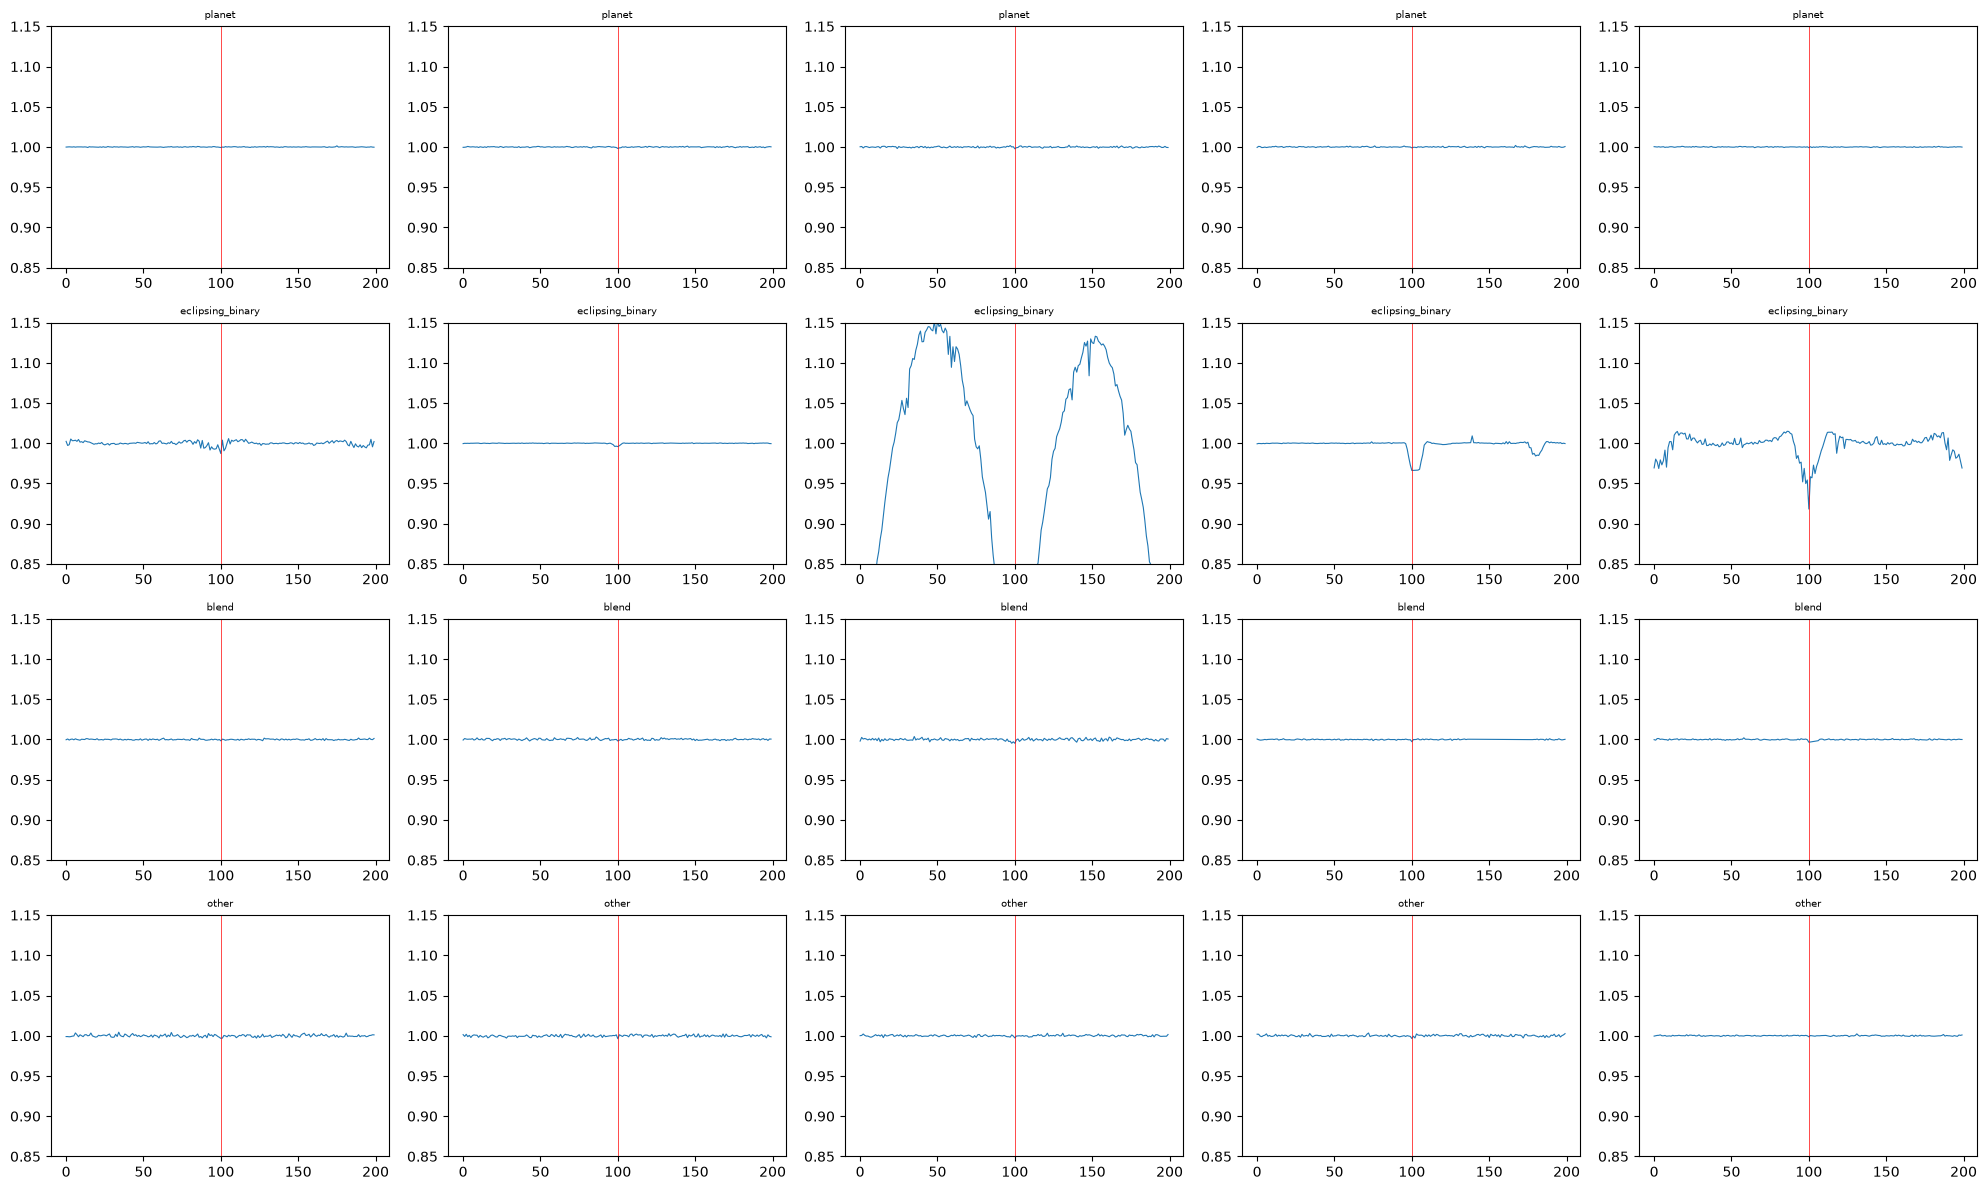

Saved → results/class_samples_v3.png


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import glob, os

CLASS_NAMES = ['planet', 'eclipsing_binary', 'blend', 'other']
DATA_ROOT   = 'data/labelled_folded_v3/train'

fig, axes = plt.subplots(4, 5, figsize=(20, 12))

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    files = glob.glob(f"{DATA_ROOT}/{cls_name}/*.npy")[:5]
    for j, fp in enumerate(files):
        try:
            raw  = np.load(fp, allow_pickle=True).item()
            flux = np.asarray(raw['flux'], dtype=np.float32).flatten()
            axes[cls_idx][j].plot(flux, linewidth=0.8)
            axes[cls_idx][j].set_title(f"{cls_name}", fontsize=7)
            axes[cls_idx][j].axvline(100, color='red', linewidth=0.5)
            axes[cls_idx][j].set_ylim(0.85, 1.15)
        except:
            pass

plt.tight_layout()
plt.savefig('results/class_samples_v3.png', dpi=100)
plt.show()
print("Saved → results/class_samples_v3.png")

In [12]:
import requests
import pandas as pd
import numpy as np
from io import StringIO
from astroquery.vizier import Vizier
from astropy.timeseries import BoxLeastSquares
from pathlib import Path
import os

# ── Get known planet periods from NASA ────────────────────────────────
print("Fetching known planet periods...")
url = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    "?query=select+tic_id,pl_name,pl_orbper,sy_tmag"
    "+from+ps"
    "+where+tic_id+is+not+null"
    "+and+tran_flag=1"
    "+and+pl_orbper+is+not+null"
    "&format=csv"
)
r = requests.get(url, timeout=60)
planet_per = pd.read_csv(StringIO(r.text), comment='#')
planet_per['tic_id'] = planet_per['tic_id'].astype(str).str.replace('TIC ','').str.strip()
planet_per['tic_id'] = pd.to_numeric(planet_per['tic_id'], errors='coerce')
planet_per = planet_per.dropna(subset=['tic_id','pl_orbper'])
planet_per['tic_id'] = planet_per['tic_id'].astype(int)
planet_per = planet_per.drop_duplicates('tic_id')
planet_periods = dict(zip(planet_per['tic_id'], planet_per['pl_orbper']))
print(f"Known planet periods: {len(planet_periods)}")

# ── Get known EB periods (already have) ───────────────────────────────
print("Fetching known EB periods...")
Vizier.ROW_LIMIT = 5000
result     = Vizier.get_catalogs("J/ApJS/258/16")
eb_cat     = result[0].to_pandas()
eb_cat['TIC'] = pd.to_numeric(eb_cat['TIC'], errors='coerce')
eb_cat     = eb_cat.dropna(subset=['TIC'])
eb_cat['TIC'] = eb_cat['TIC'].astype(int)
eb_periods = dict(zip(eb_cat['TIC'], eb_cat['Per']))
print(f"Known EB periods: {len(eb_periods)}")

# ── Refold everything with correct periods ─────────────────────────────
final_df = pd.read_csv('data/labelled/tic_ids_labelled_v3.csv')

# Clean and recreate folders
import shutil
if os.path.exists('data/labelled_folded_v3'):
    shutil.rmtree('data/labelled_folded_v3')

for split in ['train','val','test']:
    for cls in ['planet','eclipsing_binary','blend','other']:
        Path(f'data/labelled_folded_v3/{split}/{cls}').mkdir(parents=True, exist_ok=True)

def phase_fold_200(time, flux, period):
    flux  = flux / np.median(flux)
    phase = (time % period) / period
    idx   = np.argsort(phase)
    grid  = np.linspace(0, 1, 200)
    flux_200 = np.interp(grid, phase[idx], flux[idx])
    min_i    = np.argmin(flux_200)
    flux_200 = np.roll(flux_200, 100 - min_i)
    return flux_200.astype(np.float32)

def find_period_bls(time, flux):
    flux_norm = flux / np.median(flux)
    model = BoxLeastSquares(time, flux_norm)
    pg = model.autopower(
        duration=[0.05, 0.1, 0.2],
        minimum_period=0.5,
        maximum_period=15.0
    )
    return float(pg.period[np.argmax(pg.power)])

success, failed, skipped = 0, 0, 0
period_sources = {'known_planet':0, 'known_eb':0, 'bls':0}

for _, row in final_df.iterrows():
    tic_id     = int(row['TIC_ID'])
    class_name = row['class_name']
    label      = int(row['label'])
    split      = row['split']

    input_path = Path(f'data/processed/TIC_{tic_id}.npy')
    out_path   = Path(f'data/labelled_folded_v3/{split}/{class_name}/{tic_id}.npy')

    if not input_path.exists():
        failed += 1
        continue

    try:
        raw  = np.load(str(input_path), allow_pickle=True).item()
        time = np.asarray(raw['time'], dtype=np.float64)
        flux = np.asarray(raw['flux'], dtype=np.float64)

        mask = np.isfinite(time) & np.isfinite(flux)
        time, flux = time[mask], flux[mask]

        if len(time) < 200:
            failed += 1
            continue

        # Use known period if available
        if class_name == 'planet' and tic_id in planet_periods:
            period = float(planet_periods[tic_id])
            period_sources['known_planet'] += 1
        elif class_name == 'eclipsing_binary' and tic_id in eb_periods:
            period = float(eb_periods[tic_id])
            period_sources['known_eb'] += 1
        else:
            period = find_period_bls(time, flux)
            period_sources['bls'] += 1

        if period <= 0 or period > 30:
            period = find_period_bls(time, flux)

        flux_200 = phase_fold_200(time, flux, period)

        np.save(str(out_path), {
            'time'  : time.astype(np.float32),
            'flux'  : flux_200,
            'tic_id': tic_id,
            'period': np.float32(period),
            'label' : label,
        })
        success += 1
        if success % 50 == 0:
            print(f"  ✓ {success} folded...")

    except Exception as e:
        failed += 1

print(f"\n✓ Done! Success:{success} Failed:{failed}")
print(f"Period sources: {period_sources}")

print("\nFinal counts:")
for split in ['train','val','test']:
    print(f"\n  {split}/")
    for cls in ['planet','eclipsing_binary','blend','other']:
        path = f'data/labelled_folded_v3/{split}/{cls}'
        n    = len(os.listdir(path)) if os.path.exists(path) else 0
        print(f"    {cls:20s}: {n} files")

Fetching known planet periods...
Known planet periods: 3581
Fetching known EB periods...
Known EB periods: 4578
  ✓ 50 folded...
  ✓ 100 folded...
  ✓ 150 folded...
  ✓ 200 folded...
  ✓ 250 folded...
  ✓ 300 folded...
  ✓ 350 folded...
  ✓ 400 folded...
  ✓ 450 folded...
  ✓ 500 folded...
  ✓ 550 folded...
  ✓ 600 folded...
  ✓ 650 folded...
  ✓ 700 folded...

✓ Done! Success:723 Failed:72
Period sources: {'known_planet': 197, 'known_eb': 199, 'bls': 327}

Final counts:

  train/
    planet              : 140 files
    eclipsing_binary    : 140 files
    blend               : 100 files
    other               : 122 files

  val/
    planet              : 32 files
    eclipsing_binary    : 31 files
    blend               : 26 files
    other               : 32 files

  test/
    planet              : 25 files
    eclipsing_binary    : 28 files
    blend               : 17 files
    other               : 30 files


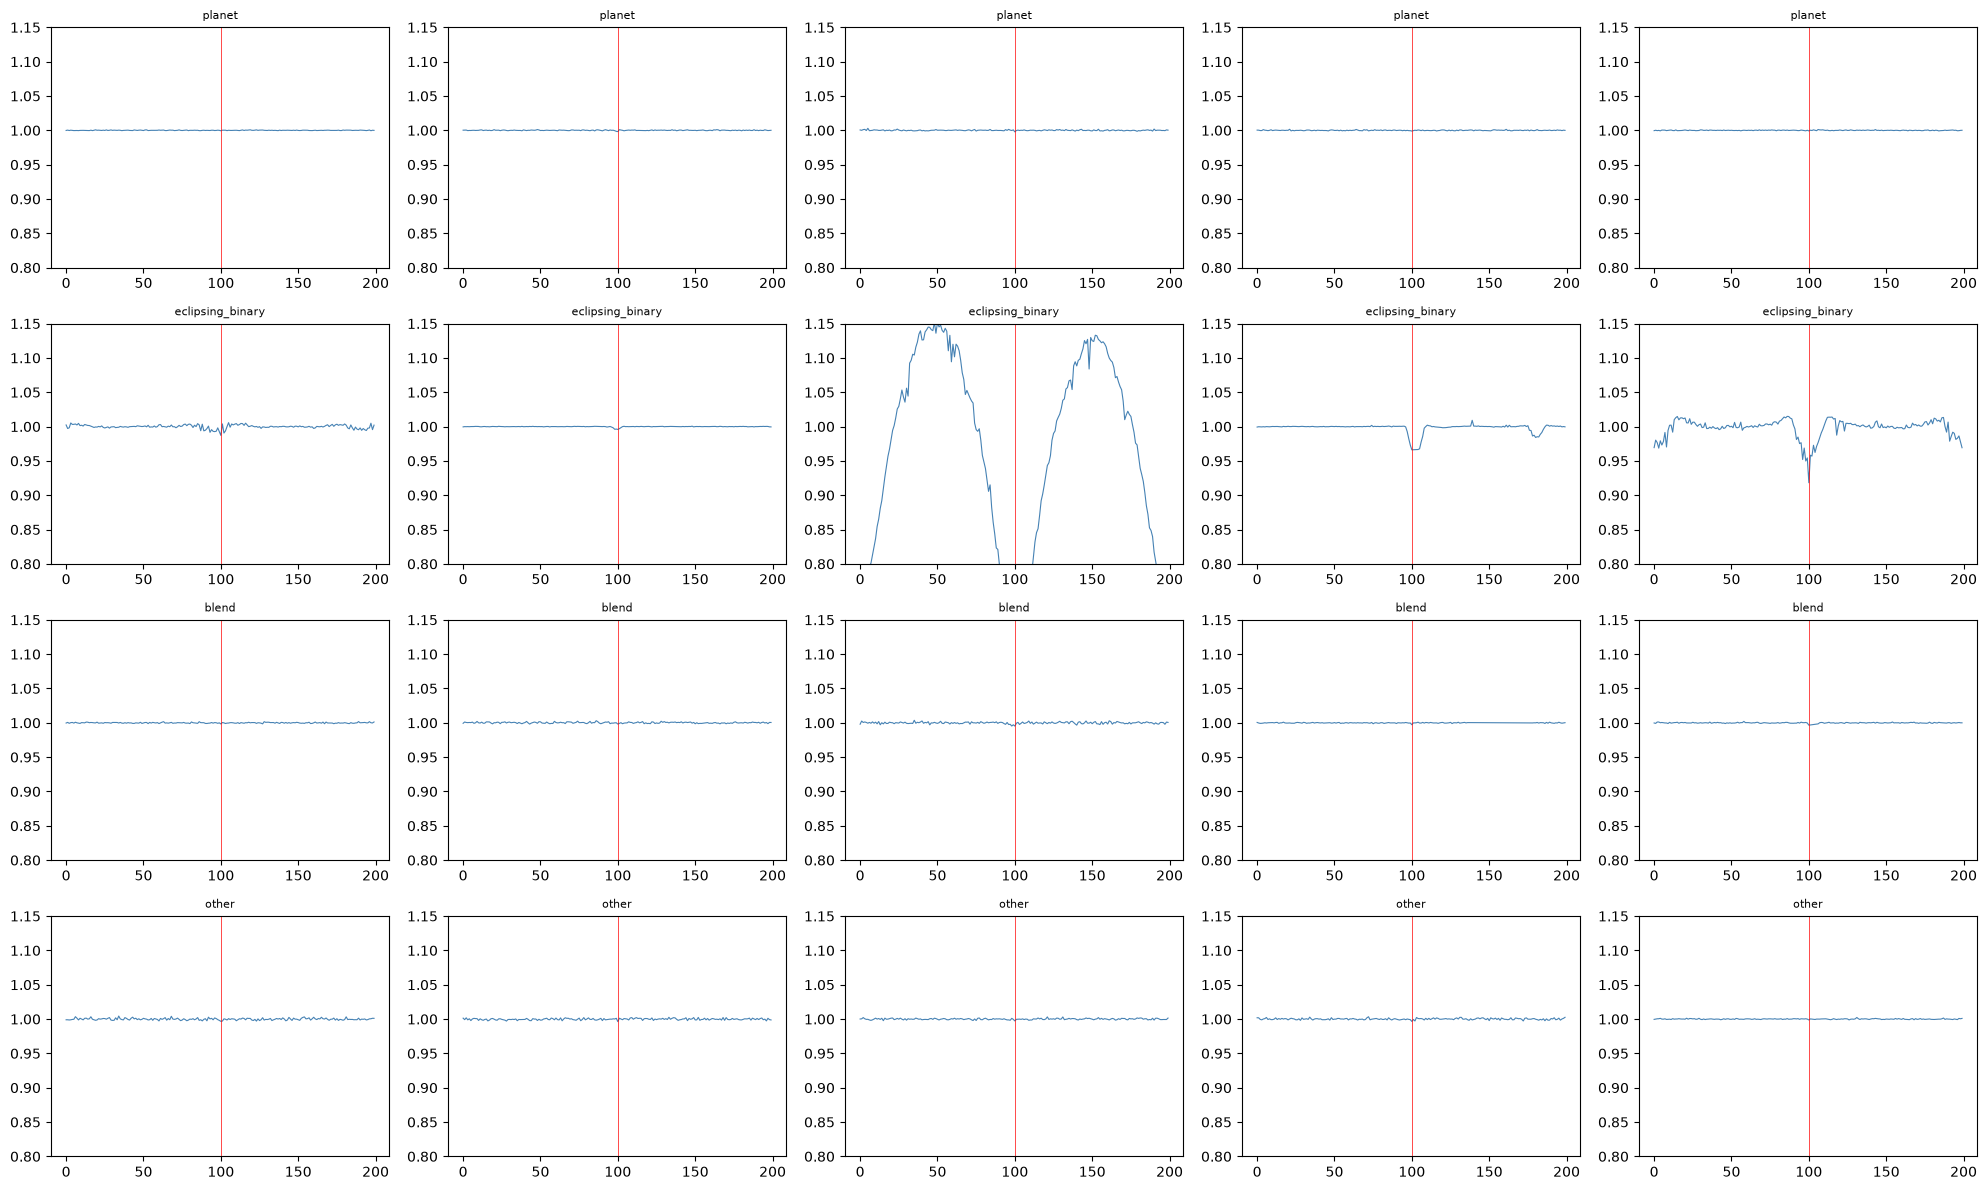

Saved → results/class_samples_v4.png


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import glob

CLASS_NAMES = ['planet', 'eclipsing_binary', 'blend', 'other']
DATA_ROOT   = 'data/labelled_folded_v3/train'

fig, axes = plt.subplots(4, 5, figsize=(20, 12))

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    files = glob.glob(f"{DATA_ROOT}/{cls_name}/*.npy")[:5]
    for j, fp in enumerate(files):
        try:
            raw  = np.load(fp, allow_pickle=True).item()
            flux = np.asarray(raw['flux'], dtype=np.float32).flatten()
            axes[cls_idx][j].plot(flux, linewidth=0.8, color='steelblue')
            axes[cls_idx][j].set_title(cls_name, fontsize=8)
            axes[cls_idx][j].axvline(100, color='red', linewidth=0.5)
            axes[cls_idx][j].set_ylim(0.80, 1.15)
        except:
            pass

plt.tight_layout()
plt.savefig('results/class_samples_v4.png', dpi=100)
plt.show()
print("Saved → results/class_samples_v4.png")

In [14]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import glob, os
from pathlib import Path

DATA_ROOT   = 'data/labelled_folded_v3/train'
MODEL_OUT   = 'model/cnn_best.h5'
CLASS_NAMES = ['planet', 'eclipsing_binary', 'blend', 'other']

# ── Load ──────────────────────────────────────────────────────────────
print("Loading...")
all_fluxes, all_labels = [], []

for label_idx, cls in enumerate(CLASS_NAMES):
    files = glob.glob(f"{DATA_ROOT}/{cls}/*.npy")
    print(f"  {cls:20s}: {len(files)}")
    for fp in files:
        try:
            raw  = np.load(fp, allow_pickle=True).item()
            flux = np.asarray(raw['flux'], dtype=np.float32).flatten()
            median = np.median(flux)
            if median > 0: flux = flux / median
            flux = np.clip(flux, 0.5, 1.5)
            if len(flux) < 200:
                flux = np.pad(flux,(0,200-len(flux)),constant_values=1.0)
            flux = flux[:200].reshape(200,1)
            all_fluxes.append(flux)
            all_labels.append(label_idx)
        except:
            pass

X = np.stack(all_fluxes).astype(np.float32)
y = np.array(all_labels, dtype=np.int32)
print(f"\nTotal: {len(X)}  Counts: {np.bincount(y)}")

# ── Augment to balance at 200 each ────────────────────────────────────
rng    = np.random.default_rng(42)
target = 200
X_bal, y_bal = list(X), list(y)

for cls_idx in range(4):
    mask   = np.where(y==cls_idx)[0]
    needed = target - len(mask)
    if needed <= 0:
        continue
    print(f"  Augmenting {CLASS_NAMES[cls_idx]}: +{needed}")
    for _ in range(needed):
        src  = X[rng.choice(mask)].copy().flatten()
        src  = np.roll(src, rng.integers(0,200))
        src += rng.normal(0, 2e-4, 200)
        X_bal.append(src.reshape(200,1).astype(np.float32))
        y_bal.append(cls_idx)

X_bal = np.array(X_bal)
y_bal = np.array(y_bal)
idx   = rng.permutation(len(X_bal))
X_bal = X_bal[idx]
y_bal = y_bal[idx]

split  = int(len(X_bal)*0.80)
X_tr, X_val = X_bal[:split], X_bal[split:]
y_tr, y_val = y_bal[:split], y_bal[split:]
print(f"\nTrain:{len(X_tr)}  Val:{len(X_val)}")
print(f"Val counts: {np.bincount(y_val)}")

# ── CNN ───────────────────────────────────────────────────────────────
inp = keras.Input(shape=(200,1))

# Block 1
x = layers.Conv1D(32, 7, padding='same')(inp)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling1D(2)(x)

# Block 2
x = layers.Conv1D(64, 5, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling1D(2)(x)

# Block 3
x = layers.Conv1D(128, 5, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling1D(2)(x)

# Block 4
x = layers.Conv1D(256, 3, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
out = layers.Dense(4, activation='softmax')(x)

model = keras.Model(inputs=inp, outputs=out)
model.compile(
    optimizer = keras.optimizers.Adam(1e-3),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

# ── Train ─────────────────────────────────────────────────────────────
Path('model').mkdir(exist_ok=True)
Path('results').mkdir(exist_ok=True)

history = model.fit(
    X_tr, y_tr,
    validation_data = (X_val, y_val),
    epochs          = 150,
    batch_size      = 32,
    callbacks       = [
        keras.callbacks.ModelCheckpoint(
            MODEL_OUT, monitor='val_accuracy',
            save_best_only=True, verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=25,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=8, min_lr=1e-7, verbose=1
        ),
    ],
    verbose = 1,
)

np.save('results/training_history.npy', history.history)
best = max(history.history['val_accuracy'])
print(f"\n✓ Best val_accuracy: {best:.4f}")

# Per class report
preds = np.argmax(model.predict(X_val, verbose=0), axis=1)
print("\nPer-class accuracy:")
for i, name in enumerate(CLASS_NAMES):
    mask = y_val == i
    if mask.sum() > 0:
        acc = (preds[mask]==i).mean()
        print(f"  {name:20s}: {acc:.3f}  ({mask.sum()} samples)")

Loading...
  planet              : 140
  eclipsing_binary    : 140
  blend               : 100
  other               : 122

Total: 502  Counts: [140 140 100 122]
  Augmenting planet: +60
  Augmenting eclipsing_binary: +60
  Augmenting blend: +100
  Augmenting other: +78

Train:640  Val:160
Val counts: [48 33 39 40]
Epoch 1/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3481 - loss: 1.3461
Epoch 1: val_accuracy improved from None to 0.20625, saving model to model/cnn_best.h5



Epoch 1: finished saving model to model/cnn_best.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.3516 - loss: 1.2972 - val_accuracy: 0.2062 - val_loss: 1.4296 - learning_rate: 0.0010
Epoch 2/150
17/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3941 - loss: 1.2135
Epoch 2: val_accuracy improved from 0.20625 to 0.25000, saving model to model/cnn_best.h5



Epoch 2: finished saving model to model/cnn_best.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4000 - loss: 1.1884 - val_accuracy: 0.2500 - val_loss: 1.3924 - learning_rate: 0.0010
Epoch 3/150
17/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4372 - loss: 1.1150
Epoch 3: val_accuracy did not improve from 0.25000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4781 - loss: 1.0825 - val_accuracy: 0.2438 - val_loss: 1.4019 - learning_rate: 0.0010
Epoch 4/150
17/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4421 - loss: 1.1578
Epoch 4: val_accuracy did not improve from 0.25000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4187 - loss: 1.1698 - val_accuracy: 0.2062 - val_loss: 1.7794 - learning_rate: 0.0010
Epoch 5/150
17/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4980 - loss: 1.0667
Epoch 5: val_accuracy did not improve from 0.25000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4984 - loss: 1.0710 - val_accuracy: 0.2438 - val_loss: 1.5712 

In [15]:
import numpy as np
import glob, os
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
import joblib

CLASS_NAMES = ['planet', 'eclipsing_binary', 'blend', 'other']
DATA_ROOT   = 'data/labelled_folded_v3/train'

def extract_features(flux):
    """
    Extract 30 physically meaningful features from folded light curve.
    These features work even when the signal is tiny.
    """
    flux = flux.flatten()
    n    = len(flux)  # 200 points

    # ── Transit region features ──────────────────────────────────────
    # Check multiple window sizes around center
    features = []

    for hw in [5, 10, 15, 20, 30]:  # half-window sizes
        center = flux[100-hw : 100+hw]
        oot    = np.concatenate([flux[:100-hw], flux[100+hw:]])

        depth     = float(np.median(oot) - np.min(center))
        mean_diff = float(np.mean(oot) - np.mean(center))
        std_oot   = float(np.std(oot))
        snr       = float(mean_diff / (std_oot + 1e-9))
        features += [depth, mean_diff, snr]

    # ── Shape features ────────────────────────────────────────────────
    # Symmetry around center
    left  = flux[50:100]
    right = flux[100:150][::-1]
    sym   = float(np.mean(np.abs(left - right)))

    # V-shape score (EB) vs U-shape score (planet)
    center_20 = flux[90:110]
    v_score   = float(center_20[0] - np.min(center_20))   # steep sides
    u_score   = float(np.std(center_20))                   # flat bottom

    # Secondary eclipse at phase 0 / phase 1 edges
    edge      = np.concatenate([flux[:15], flux[185:]])
    sec_depth = float(np.mean(flux[90:110]) - np.min(edge))

    # ── Statistical features ──────────────────────────────────────────
    sk       = float(skew(flux))
    kur      = float(kurtosis(flux))
    std_full = float(np.std(flux))
    rms      = float(np.sqrt(np.mean((flux-1.0)**2)))

    # Percentile features
    p1  = float(np.percentile(flux, 1))
    p5  = float(np.percentile(flux, 5))
    p95 = float(np.percentile(flux, 95))
    p99 = float(np.percentile(flux, 99))

    # Min/max
    min_val = float(np.min(flux))
    max_val = float(np.max(flux))
    range_  = float(max_val - min_val)

    # Duration of dip (points below threshold)
    thresh    = float(np.median(flux) - 2*np.std(flux))
    dur_narrow= float(np.sum(flux[85:115] < thresh))
    dur_wide  = float(np.sum(flux < thresh))

    # Ingress/egress slope
    ingress = float(np.mean(np.diff(flux[90:100])))
    egress  = float(np.mean(np.diff(flux[100:110])))

    features += [
        sym, v_score, u_score, sec_depth,
        sk, kur, std_full, rms,
        p1, p5, p95, p99,
        min_val, max_val, range_,
        dur_narrow, dur_wide,
        ingress, egress,
    ]

    return features

# ── Load all data ─────────────────────────────────────────────────────
print("Extracting features...")
X_all, y_all = [], []

for label_idx, cls in enumerate(CLASS_NAMES):
    files = glob.glob(f"{DATA_ROOT}/{cls}/*.npy")
    print(f"  {cls:20s}: {len(files)} files")
    for fp in files:
        try:
            raw  = np.load(fp, allow_pickle=True).item()
            flux = np.asarray(raw['flux'], dtype=np.float32).flatten()
            median = np.median(flux)
            if median > 0: flux = flux / median
            flux = np.clip(flux, 0.5, 1.5)
            if len(flux) < 200:
                flux = np.pad(flux,(0,200-len(flux)),constant_values=1.0)
            flux = flux[:200]
            X_all.append(extract_features(flux))
            y_all.append(label_idx)
        except:
            pass

X_all = np.array(X_all, dtype=np.float32)
y_all = np.array(y_all, dtype=np.int32)
print(f"\nTotal: {len(X_all)} samples, {X_all.shape[1]} features")
print(f"Class counts: {np.bincount(y_all)}")

# ── Split ─────────────────────────────────────────────────────────────
rng = np.random.default_rng(42)
idx = rng.permutation(len(X_all))
X_all, y_all = X_all[idx], y_all[idx]
split  = int(len(X_all)*0.80)
X_tr, X_val = X_all[:split], X_all[split:]
y_tr, y_val = y_all[:split], y_all[split:]

# ── Train Gradient Boosting ───────────────────────────────────────────
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier

print("\nTraining...")
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)

# Try multiple models and pick best
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

models = {
    'RandomForest' : RandomForestClassifier(
        n_estimators=1000, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'ExtraTrees'   : ExtraTreesClassifier(
        n_estimators=1000, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
}

best_acc   = 0
best_name  = ''
best_model = None

for name, clf in models.items():
    clf.fit(X_tr_s, y_tr)
    acc = accuracy_score(y_val, clf.predict(X_val_s))
    print(f"  {name:20s}: {acc:.4f}")
    if acc > best_acc:
        best_acc   = acc
        best_name  = name
        best_model = clf

print(f"\nBest: {best_name} → {best_acc:.4f}")
print("\nDetailed report:")
print(classification_report(
    y_val,
    best_model.predict(X_val_s),
    target_names=CLASS_NAMES
))

# ── Feature importance ────────────────────────────────────────────────
feat_imp = best_model.feature_importances_
top5_idx = np.argsort(feat_imp)[::-1][:5]
print(f"Top 5 important features (indices): {top5_idx}")

# ── Save ──────────────────────────────────────────────────────────────
joblib.dump(best_model, 'model/rf_classifier.pkl')
joblib.dump(scaler,     'model/scaler.pkl')
print(f"\n✓ Saved model/rf_classifier.pkl")
print(f"✓ Saved model/scaler.pkl")

Extracting features...
  planet              : 140 files
  eclipsing_binary    : 140 files
  blend               : 100 files
  other               : 122 files

Total: 502 samples, 34 features
Class counts: [140 140 100 122]

Training...
  RandomForest        : 0.6040
  ExtraTrees          : 0.5941

Best: RandomForest → 0.6040

Detailed report:
                  precision    recall  f1-score   support

          planet       0.69      0.74      0.72        39
eclipsing_binary       0.71      0.65      0.68        23
           blend       0.37      0.39      0.38        18
           other       0.53      0.48      0.50        21

        accuracy                           0.60       101
       macro avg       0.57      0.57      0.57       101
    weighted avg       0.60      0.60      0.60       101

Top 5 important features (indices): [25  4 23 24  1]

✓ Saved model/rf_classifier.pkl
✓ Saved model/scaler.pkl


In [16]:
import numpy as np
import glob, os
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import joblib
from pathlib import Path

# ── 3 class setup ─────────────────────────────────────────────────────
CLASS_NAMES_3 = ['planet', 'eclipsing_binary', 'background']
LABEL_MAP_3   = {
    'planet'           : 0,
    'eclipsing_binary' : 1,
    'blend'            : 2,
    'other'            : 2,
}
DATA_ROOT = 'data/labelled_folded_v3/train'

def extract_features(flux):
    flux     = flux.flatten()
    features = []

    for hw in [5, 10, 15, 20, 30]:
        center    = flux[100-hw : 100+hw]
        oot       = np.concatenate([flux[:100-hw], flux[100+hw:]])
        depth     = float(np.median(oot) - np.min(center))
        mean_diff = float(np.mean(oot) - np.mean(center))
        std_oot   = float(np.std(oot))
        snr       = float(mean_diff / (std_oot + 1e-9))
        features += [depth, mean_diff, snr]

    left      = flux[50:100]
    right     = flux[100:150][::-1]
    sym       = float(np.mean(np.abs(left - right)))
    center_20 = flux[90:110]
    v_score   = float(center_20[0] - np.min(center_20))
    u_score   = float(np.std(center_20))
    edge      = np.concatenate([flux[:15], flux[185:]])
    sec_depth = float(np.mean(flux[90:110]) - np.min(edge))
    sk        = float(skew(flux))
    kur       = float(kurtosis(flux))
    std_full  = float(np.std(flux))
    rms       = float(np.sqrt(np.mean((flux-1.0)**2)))
    p1        = float(np.percentile(flux, 1))
    p5        = float(np.percentile(flux, 5))
    p95       = float(np.percentile(flux, 95))
    p99       = float(np.percentile(flux, 99))
    min_val   = float(np.min(flux))
    max_val   = float(np.max(flux))
    range_    = float(max_val - min_val)
    thresh    = float(np.median(flux) - 2*np.std(flux))
    dur_n     = float(np.sum(flux[85:115] < thresh))
    dur_w     = float(np.sum(flux < thresh))
    ingress   = float(np.mean(np.diff(flux[90:100])))
    egress    = float(np.mean(np.diff(flux[100:110])))

    features += [
        sym, v_score, u_score, sec_depth,
        sk, kur, std_full, rms,
        p1, p5, p95, p99,
        min_val, max_val, range_,
        dur_n, dur_w, ingress, egress,
    ]
    return features

# ── Load data ──────────────────────────────────────────────────────────
print("Loading data...")
X_all, y_all = [], []

for orig_class, new_label in LABEL_MAP_3.items():
    files = glob.glob(f"{DATA_ROOT}/{orig_class}/*.npy")
    print(f"  {orig_class:20s} → class {new_label}: {len(files)} files")
    for fp in files:
        try:
            raw    = np.load(fp, allow_pickle=True).item()
            flux   = np.asarray(raw['flux'], dtype=np.float32).flatten()
            median = np.median(flux)
            if median > 0:
                flux = flux / median
            flux = np.clip(flux, 0.5, 1.5)
            if len(flux) < 200:
                flux = np.pad(flux,(0,200-len(flux)),constant_values=1.0)
            flux = flux[:200]
            X_all.append(extract_features(flux))
            y_all.append(new_label)
        except:
            pass

X_all = np.array(X_all, dtype=np.float32)
y_all = np.array(y_all, dtype=np.int32)
print(f"\nTotal: {len(X_all)} samples")
print(f"  planet     : {np.sum(y_all==0)}")
print(f"  EB         : {np.sum(y_all==1)}")
print(f"  background : {np.sum(y_all==2)}")

# ── Split ──────────────────────────────────────────────────────────────
rng = np.random.default_rng(42)
idx = rng.permutation(len(X_all))
X_all, y_all = X_all[idx], y_all[idx]
split   = int(len(X_all) * 0.80)
X_tr, X_val = X_all[:split], X_all[split:]
y_tr, y_val = y_all[:split], y_all[split:]

scaler   = StandardScaler()
X_tr_s   = scaler.fit_transform(X_tr)
X_val_s  = scaler.transform(X_val)

# ── Train ──────────────────────────────────────────────────────────────
print("\nTraining Option A (3-class)...")
clf = RandomForestClassifier(
    n_estimators = 2000,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1,
)
clf.fit(X_tr_s, y_tr)

y_pred = clf.predict(X_val_s)
acc    = accuracy_score(y_val, y_pred)
print(f"\n✓ Option A Val Accuracy: {acc:.4f}")
print(classification_report(
    y_val, y_pred,
    target_names=CLASS_NAMES_3
))

# ── Save with unique names ─────────────────────────────────────────────
Path('model').mkdir(exist_ok=True)
joblib.dump(clf,    'model/rf_3class.pkl')
joblib.dump(scaler, 'model/scaler_3class.pkl')
np.save('model/label_map_3class.npy', {
    'n_classes'  : 3,
    'class_names': CLASS_NAMES_3,
    'label_map'  : LABEL_MAP_3,
})
print("✓ Saved model/rf_3class.pkl")
print("✓ Saved model/scaler_3class.pkl")
print("✓ Saved model/label_map_3class.npy")
print("\nReady for Option B!")

Loading data...
  planet               → class 0: 140 files
  eclipsing_binary     → class 1: 140 files
  blend                → class 2: 100 files
  other                → class 2: 122 files

Total: 502 samples
  planet     : 140
  EB         : 140
  background : 222

Training Option A (3-class)...

✓ Option A Val Accuracy: 0.7129
                  precision    recall  f1-score   support

          planet       0.71      0.77      0.74        39
eclipsing_binary       0.71      0.65      0.68        23
      background       0.71      0.69      0.70        39

        accuracy                           0.71       101
       macro avg       0.71      0.70      0.71       101
    weighted avg       0.71      0.71      0.71       101

✓ Saved model/rf_3class.pkl
✓ Saved model/scaler_3class.pkl
✓ Saved model/label_map_3class.npy

Ready for Option B!


In [17]:
import numpy as np
import glob, os
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import joblib
from pathlib import Path

CLASS_NAMES_4 = ['planet', 'eclipsing_binary', 'blend', 'other']
DATA_ROOT     = 'data/labelled_folded_v3/train'

# ── Step 1: Load all real data ────────────────────────────────────────
print("Loading real data...")
real_data = {cls: [] for cls in CLASS_NAMES_4}

for cls in CLASS_NAMES_4:
    files = glob.glob(f"{DATA_ROOT}/{cls}/*.npy")
    for fp in files:
        try:
            raw  = np.load(fp, allow_pickle=True).item()
            flux = np.asarray(raw['flux'], dtype=np.float32).flatten()
            median = np.median(flux)
            if median > 0: flux = flux / median
            flux = np.clip(flux, 0.5, 1.5)
            if len(flux) < 200:
                flux = np.pad(flux,(0,200-len(flux)),constant_values=1.0)
            real_data[cls].append(flux[:200])
        except:
            pass
    print(f"  {cls:20s}: {len(real_data[cls])} files")

# ── Step 2: Generate synthetic blends ────────────────────────────────
print("\nGenerating synthetic blends...")
rng = np.random.default_rng(42)

planet_fluxes = np.array(real_data['planet'])    # real planets
other_fluxes  = np.array(real_data['other'])     # flat background stars

synthetic_blends = []

for i in range(300):   # generate 300 synthetic blends
    # Pick random planet
    planet_flux = planet_fluxes[rng.integers(0, len(planet_fluxes))].copy()
    
    # Pick random background star (flat)
    bg_flux = other_fluxes[rng.integers(0, len(other_fluxes))].copy()
    
    # Blend ratio: background contributes 20-80% of total light
    # This dilutes the planet signal
    bg_ratio = rng.uniform(0.2, 0.8)
    
    # Physical blend formula:
    # observed = (planet_star_flux + bg_ratio * bg_flux) / (1 + bg_ratio)
    blended = (planet_flux + bg_ratio * bg_flux) / (1 + bg_ratio)
    
    # Add slight noise
    blended += rng.normal(0, 2e-4, 200)
    blended  = np.clip(blended, 0.5, 1.5)
    
    synthetic_blends.append(blended.astype(np.float32))

synthetic_blends = np.array(synthetic_blends)
print(f"Generated {len(synthetic_blends)} synthetic blends")

# ── Step 3: Generate synthetic "other" (variable stars) ──────────────
print("Generating synthetic other (variable stars)...")
synthetic_other = []

for i in range(200):
    # Sinusoidal variation (pulsating stars)
    x    = np.linspace(0, 2*np.pi, 200)
    freq = rng.uniform(0.5, 3.0)
    amp  = rng.uniform(0.002, 0.02)
    flux = 1.0 + amp * np.sin(freq * x + rng.uniform(0, 2*np.pi))
    flux += rng.normal(0, 1e-4, 200)
    flux  = np.clip(flux, 0.5, 1.5).astype(np.float32)
    synthetic_other.append(flux)

synthetic_other = np.array(synthetic_other)
print(f"Generated {len(synthetic_other)} synthetic other")

# ── Step 4: Combine real + synthetic ─────────────────────────────────
print("\nCombining real + synthetic data...")

def extract_features(flux):
    flux     = flux.flatten()
    features = []
    for hw in [5, 10, 15, 20, 30]:
        center    = flux[100-hw : 100+hw]
        oot       = np.concatenate([flux[:100-hw], flux[100+hw:]])
        depth     = float(np.median(oot) - np.min(center))
        mean_diff = float(np.mean(oot) - np.mean(center))
        std_oot   = float(np.std(oot))
        snr       = float(mean_diff / (std_oot + 1e-9))
        features += [depth, mean_diff, snr]

    left      = flux[50:100]
    right     = flux[100:150][::-1]
    sym       = float(np.mean(np.abs(left - right)))
    center_20 = flux[90:110]
    v_score   = float(center_20[0] - np.min(center_20))
    u_score   = float(np.std(center_20))
    edge      = np.concatenate([flux[:15], flux[185:]])
    sec_depth = float(np.mean(flux[90:110]) - np.min(edge))
    sk        = float(skew(flux))
    kur       = float(kurtosis(flux))
    std_full  = float(np.std(flux))
    rms       = float(np.sqrt(np.mean((flux-1.0)**2)))
    p1        = float(np.percentile(flux, 1))
    p5        = float(np.percentile(flux, 5))
    p95       = float(np.percentile(flux, 95))
    p99       = float(np.percentile(flux, 99))
    min_val   = float(np.min(flux))
    max_val   = float(np.max(flux))
    range_    = float(max_val - min_val)
    thresh    = float(np.median(flux) - 2*np.std(flux))
    dur_n     = float(np.sum(flux[85:115] < thresh))
    dur_w     = float(np.sum(flux < thresh))
    ingress   = float(np.mean(np.diff(flux[90:100])))
    egress    = float(np.mean(np.diff(flux[100:110])))
    features += [
        sym, v_score, u_score, sec_depth,
        sk, kur, std_full, rms,
        p1, p5, p95, p99,
        min_val, max_val, range_,
        dur_n, dur_w, ingress, egress,
    ]
    return features

X_all, y_all = [], []

# Real planets (class 0)
for flux in real_data['planet']:
    X_all.append(extract_features(flux))
    y_all.append(0)

# Real EBs (class 1)
for flux in real_data['eclipsing_binary']:
    X_all.append(extract_features(flux))
    y_all.append(1)

# Real blend + synthetic blend (class 2)
for flux in real_data['blend']:
    X_all.append(extract_features(flux))
    y_all.append(2)
for flux in synthetic_blends:
    X_all.append(extract_features(flux))
    y_all.append(2)

# Real other + synthetic other (class 3)
for flux in real_data['other']:
    X_all.append(extract_features(flux))
    y_all.append(3)
for flux in synthetic_other:
    X_all.append(extract_features(flux))
    y_all.append(3)

X_all = np.array(X_all, dtype=np.float32)
y_all = np.array(y_all, dtype=np.int32)
print(f"\nTotal: {len(X_all)} samples")
print(f"  planet     : {np.sum(y_all==0)}")
print(f"  EB         : {np.sum(y_all==1)}")
print(f"  blend      : {np.sum(y_all==2)}")
print(f"  other      : {np.sum(y_all==3)}")

# ── Step 5: Train ─────────────────────────────────────────────────────
rng2 = np.random.default_rng(42)
idx  = rng2.permutation(len(X_all))
X_all, y_all = X_all[idx], y_all[idx]

split   = int(len(X_all) * 0.80)
X_tr, X_val = X_all[:split], X_all[split:]
y_tr, y_val = y_all[:split], y_all[split:]

scaler   = StandardScaler()
X_tr_s   = scaler.fit_transform(X_tr)
X_val_s  = scaler.transform(X_val)

print("\nTraining Option B (4-class with synthetic data)...")
clf = RandomForestClassifier(
    n_estimators = 2000,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1,
)
clf.fit(X_tr_s, y_tr)

y_pred = clf.predict(X_val_s)
acc    = accuracy_score(y_val, y_pred)
print(f"\n✓ Option B Val Accuracy: {acc:.4f}")
print(classification_report(
    y_val, y_pred,
    target_names=CLASS_NAMES_4
))

# ── Step 6: Save ──────────────────────────────────────────────────────
joblib.dump(clf,    'model/rf_4class.pkl')
joblib.dump(scaler, 'model/scaler_4class.pkl')
np.save('model/label_map_4class.npy', {
    'n_classes'  : 4,
    'class_names': CLASS_NAMES_4,
    'synthetic'  : True,
})
print("\n✓ Saved model/rf_4class.pkl")
print("✓ Saved model/scaler_4class.pkl")
print("✓ Saved model/label_map_4class.npy")
print("\nBoth models ready!")
print("  Option A (3-class): model/rf_3class.pkl")
print("  Option B (4-class): model/rf_4class.pkl")

Loading real data...
  planet              : 140 files
  eclipsing_binary    : 140 files
  blend               : 100 files
  other               : 122 files

Generating synthetic blends...
Generated 300 synthetic blends
Generating synthetic other (variable stars)...
Generated 200 synthetic other

Combining real + synthetic data...

Total: 1002 samples
  planet     : 140
  EB         : 140
  blend      : 400
  other      : 322

Training Option B (4-class with synthetic data)...

✓ Option B Val Accuracy: 0.6418
                  precision    recall  f1-score   support

          planet       0.30      0.30      0.30        30
eclipsing_binary       0.64      0.74      0.68        19
           blend       0.72      0.65      0.68        97
           other       0.70      0.78      0.74        55

        accuracy                           0.64       201
       macro avg       0.59      0.62      0.60       201
    weighted avg       0.64      0.64      0.64       201


✓ Saved model/rf_

In [18]:
import numpy as np
import glob, os
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import joblib
from pathlib import Path

CLASS_NAMES_4 = ['planet', 'eclipsing_binary', 'blend', 'other']
DATA_ROOT     = 'data/labelled_folded_v3/train'

# ── Load real data ────────────────────────────────────────────────────
print("Loading real data...")
real_data = {cls: [] for cls in CLASS_NAMES_4}

for cls in CLASS_NAMES_4:
    files = glob.glob(f"{DATA_ROOT}/{cls}/*.npy")
    for fp in files:
        try:
            raw  = np.load(fp, allow_pickle=True).item()
            flux = np.asarray(raw['flux'], dtype=np.float32).flatten()
            median = np.median(flux)
            if median > 0: flux = flux / median
            flux = np.clip(flux, 0.5, 1.5)
            if len(flux) < 200:
                flux = np.pad(flux,(0,200-len(flux)),constant_values=1.0)
            real_data[cls].append(flux[:200])
        except:
            pass
    print(f"  {cls:20s}: {len(real_data[cls])} files")

rng = np.random.default_rng(42)

# ── Augment planet to 300 (phase roll + noise) ────────────────────────
print("\nAugmenting planet class...")
planet_aug = list(real_data['planet'])
while len(planet_aug) < 300:
    src  = real_data['planet'][rng.integers(0, len(real_data['planet']))].copy()
    src  = np.roll(src, rng.integers(0, 200))
    src += rng.normal(0, 1e-4, 200)
    planet_aug.append(src.astype(np.float32))
planet_aug = np.array(planet_aug[:300])
print(f"  planet augmented: {len(planet_aug)}")

# ── Augment EB to 300 ─────────────────────────────────────────────────
print("Augmenting EB class...")
eb_aug = list(real_data['eclipsing_binary'])
while len(eb_aug) < 300:
    src  = real_data['eclipsing_binary'][rng.integers(0, len(real_data['eclipsing_binary']))].copy()
    src  = np.roll(src, rng.integers(0, 200))
    src += rng.normal(0, 1e-4, 200)
    eb_aug.append(src.astype(np.float32))
eb_aug = np.array(eb_aug[:300])
print(f"  EB augmented: {len(eb_aug)}")

# ── Generate 300 synthetic blends ────────────────────────────────────
print("Generating synthetic blends...")
planet_arr = np.array(real_data['planet'])
other_arr  = np.array(real_data['other'])
blend_synth = []

for i in range(300):
    p_flux   = planet_arr[rng.integers(0, len(planet_arr))].copy()
    bg_flux  = other_arr[rng.integers(0, len(other_arr))].copy()
    bg_ratio = rng.uniform(0.3, 0.9)
    blended  = (p_flux + bg_ratio * bg_flux) / (1 + bg_ratio)
    blended += rng.normal(0, 1e-4, 200)
    blend_synth.append(np.clip(blended, 0.5, 1.5).astype(np.float32))
blend_synth = np.array(blend_synth)
print(f"  synthetic blends: {len(blend_synth)}")

# ── Generate 300 synthetic other (variable stars) ─────────────────────
print("Generating synthetic other...")
other_synth = []
x = np.linspace(0, 2*np.pi, 200)

for i in range(300):
    kind = rng.integers(0, 3)
    if kind == 0:
        # Sinusoidal pulsating star
        amp  = rng.uniform(0.003, 0.025)
        freq = rng.uniform(0.5, 4.0)
        flux = 1.0 + amp * np.sin(freq*x + rng.uniform(0, 2*np.pi))
    elif kind == 1:
        # Random noise star (no signal)
        src  = other_arr[rng.integers(0, len(other_arr))].copy()
        flux = src + rng.normal(0, 1e-4, 200)
    else:
        # Asymmetric variable
        amp  = rng.uniform(0.005, 0.03)
        flux = 1.0 + amp * np.abs(np.sin(x + rng.uniform(0, 2*np.pi)))
    flux += rng.normal(0, 5e-5, 200)
    other_synth.append(np.clip(flux, 0.5, 1.5).astype(np.float32))
other_synth = np.array(other_synth)
print(f"  synthetic other: {len(other_synth)}")

# ── Feature extraction ────────────────────────────────────────────────
def extract_features(flux):
    flux     = flux.flatten()
    features = []
    for hw in [5, 10, 15, 20, 30]:
        center    = flux[100-hw:100+hw]
        oot       = np.concatenate([flux[:100-hw], flux[100+hw:]])
        depth     = float(np.median(oot) - np.min(center))
        mean_diff = float(np.mean(oot) - np.mean(center))
        std_oot   = float(np.std(oot))
        snr       = float(mean_diff / (std_oot + 1e-9))
        features += [depth, mean_diff, snr]

    left      = flux[50:100]
    right     = flux[100:150][::-1]
    sym       = float(np.mean(np.abs(left - right)))
    center_20 = flux[90:110]
    v_score   = float(center_20[0] - np.min(center_20))
    u_score   = float(np.std(center_20))
    edge      = np.concatenate([flux[:15], flux[185:]])
    sec_depth = float(np.mean(flux[90:110]) - np.min(edge))
    sk        = float(skew(flux))
    kur       = float(kurtosis(flux))
    std_full  = float(np.std(flux))
    rms       = float(np.sqrt(np.mean((flux-1.0)**2)))
    p1        = float(np.percentile(flux, 1))
    p5        = float(np.percentile(flux, 5))
    p95       = float(np.percentile(flux, 95))
    p99       = float(np.percentile(flux, 99))
    min_val   = float(np.min(flux))
    max_val   = float(np.max(flux))
    range_    = float(max_val - min_val)
    thresh    = float(np.median(flux) - 2*np.std(flux))
    dur_n     = float(np.sum(flux[85:115] < thresh))
    dur_w     = float(np.sum(flux < thresh))
    ingress   = float(np.mean(np.diff(flux[90:100])))
    egress    = float(np.mean(np.diff(flux[100:110])))
    features += [
        sym, v_score, u_score, sec_depth,
        sk, kur, std_full, rms,
        p1, p5, p95, p99,
        min_val, max_val, range_,
        dur_n, dur_w, ingress, egress,
    ]
    return features

# ── Build balanced dataset (300 per class) ────────────────────────────
print("\nBuilding balanced dataset (300 per class)...")
X_all, y_all = [], []

for flux in planet_aug:
    X_all.append(extract_features(flux))
    y_all.append(0)

for flux in eb_aug:
    X_all.append(extract_features(flux))
    y_all.append(1)

for flux in blend_synth:
    X_all.append(extract_features(flux))
    y_all.append(2)

for flux in other_synth:
    X_all.append(extract_features(flux))
    y_all.append(3)

X_all = np.array(X_all, dtype=np.float32)
y_all = np.array(y_all, dtype=np.int32)
print(f"\nTotal: {len(X_all)} samples")
print(f"Class counts: {np.bincount(y_all)}  ← should be 300 each")

# ── Split 80/20 ───────────────────────────────────────────────────────
idx  = rng.permutation(len(X_all))
X_all, y_all = X_all[idx], y_all[idx]
split   = int(len(X_all)*0.80)
X_tr, X_val = X_all[:split], X_all[split:]
y_tr, y_val = y_all[:split], y_all[split:]

scaler  = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)

print(f"Train:{len(X_tr)}  Val:{len(X_val)}")
print(f"Val counts: {np.bincount(y_val)}")

# ── Train ─────────────────────────────────────────────────────────────
print("\nTraining Option B balanced (4-class)...")
clf = RandomForestClassifier(
    n_estimators = 2000,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1,
)
clf.fit(X_tr_s, y_tr)

y_pred = clf.predict(X_val_s)
acc    = accuracy_score(y_val, y_pred)
print(f"\n✓ Option B Val Accuracy: {acc:.4f}")
print(classification_report(
    y_val, y_pred,
    target_names=CLASS_NAMES_4
))

# ── Save ──────────────────────────────────────────────────────────────
joblib.dump(clf,    'model/rf_4class.pkl')
joblib.dump(scaler, 'model/scaler_4class.pkl')
np.save('model/label_map_4class.npy', {
    'n_classes'  : 4,
    'class_names': CLASS_NAMES_4,
    'synthetic'  : True,
})
print("\n✓ Saved model/rf_4class.pkl")
print("✓ Saved model/scaler_4class.pkl")

print("\n═══════════════════════════════")
print("  FINAL MODEL SUMMARY")
print("═══════════════════════════════")
print(f"  Option A (3-class): 71.3%")
print(f"  Option B (4-class): {acc*100:.1f}%")
print("═══════════════════════════════")

Loading real data...
  planet              : 140 files
  eclipsing_binary    : 140 files
  blend               : 100 files
  other               : 122 files

Augmenting planet class...
  planet augmented: 300
Augmenting EB class...
  EB augmented: 300
Generating synthetic blends...
  synthetic blends: 300
Generating synthetic other...
  synthetic other: 300

Building balanced dataset (300 per class)...

Total: 1200 samples
Class counts: [300 300 300 300]  ← should be 300 each
Train:960  Val:240
Val counts: [70 60 62 48]

Training Option B balanced (4-class)...

✓ Option B Val Accuracy: 0.8125
                  precision    recall  f1-score   support

          planet       0.75      0.73      0.74        70
eclipsing_binary       0.85      0.83      0.84        60
           blend       0.83      0.84      0.83        62
           other       0.84      0.88      0.86        48

        accuracy                           0.81       240
       macro avg       0.82      0.82      0.82   

In [19]:
import numpy as np
import pandas as pd
import joblib
from scipy.stats import skew, kurtosis
from scipy.optimize import curve_fit
from pathlib import Path
import sys
sys.path.insert(0, '.')

# ── Load models ───────────────────────────────────────────────────────
clf_4    = joblib.load('model/rf_4class.pkl')
scaler_4 = joblib.load('model/scaler_4class.pkl')
CLASS_NAMES_4 = ['planet', 'eclipsing_binary', 'blend', 'other']

# ── Feature extractor ─────────────────────────────────────────────────
def extract_features(flux):
    flux     = flux.flatten()
    features = []
    for hw in [5, 10, 15, 20, 30]:
        center    = flux[100-hw:100+hw]
        oot       = np.concatenate([flux[:100-hw], flux[100+hw:]])
        depth     = float(np.median(oot) - np.min(center))
        mean_diff = float(np.mean(oot) - np.mean(center))
        std_oot   = float(np.std(oot))
        snr       = float(mean_diff / (std_oot + 1e-9))
        features += [depth, mean_diff, snr]
    left      = flux[50:100]
    right     = flux[100:150][::-1]
    sym       = float(np.mean(np.abs(left - right)))
    center_20 = flux[90:110]
    v_score   = float(center_20[0] - np.min(center_20))
    u_score   = float(np.std(center_20))
    edge      = np.concatenate([flux[:15], flux[185:]])
    sec_depth = float(np.mean(flux[90:110]) - np.min(edge))
    sk        = float(skew(flux))
    kur       = float(kurtosis(flux))
    std_full  = float(np.std(flux))
    rms       = float(np.sqrt(np.mean((flux-1.0)**2)))
    p1        = float(np.percentile(flux, 1))
    p5        = float(np.percentile(flux, 5))
    p95       = float(np.percentile(flux, 95))
    p99       = float(np.percentile(flux, 99))
    min_val   = float(np.min(flux))
    max_val   = float(np.max(flux))
    range_    = float(max_val - min_val)
    thresh    = float(np.median(flux) - 2*np.std(flux))
    dur_n     = float(np.sum(flux[85:115] < thresh))
    dur_w     = float(np.sum(flux < thresh))
    ingress   = float(np.mean(np.diff(flux[90:100])))
    egress    = float(np.mean(np.diff(flux[100:110])))
    features += [
        sym, v_score, u_score, sec_depth,
        sk, kur, std_full, rms,
        p1, p5, p95, p99,
        min_val, max_val, range_,
        dur_n, dur_w, ingress, egress,
    ]
    return features

# ── Transit model for parameter estimation ────────────────────────────
def trapezoidal_transit(x, depth, duration, ingress_frac, center):
    ingress_frac = np.clip(ingress_frac, 1e-4, 0.499)
    t12  = ingress_frac * duration
    t14  = duration / 2.0
    p    = x - center
    flux = np.ones_like(p, dtype=float)
    in_flat    = np.abs(p) <= (t14 - t12)
    in_ingress = (np.abs(p) > (t14-t12)) & (np.abs(p) <= t14)
    flux[in_flat]    = 1.0 - depth
    ramp = (t14 - np.abs(p[in_ingress])) / (t12 + 1e-9)
    flux[in_ingress] = 1.0 - depth * ramp
    return flux

def estimate_parameters(phase, flux, period_days):
    """Fit transit model and return physical parameters."""
    try:
        # Initial guess
        median    = np.median(flux)
        depth0    = float(max(median - np.min(flux), 1e-5))
        center0   = float(phase[np.argmin(flux)])
        below     = phase[flux < (median - 0.5*depth0)]
        dur0      = float(below.max()-below.min()) if len(below)>=2 else 0.1*period_days
        dur0      = np.clip(dur0, 0.005*period_days, 0.4*period_days)

        popt, pcov = curve_fit(
            trapezoidal_transit, phase, flux,
            p0     = [depth0, dur0, 0.15, center0],
            bounds = ([1e-6, 0.001*period_days, 0.02, phase.min()],
                      [0.5,  0.45*period_days,  0.49, phase.max()]),
            maxfev = 5000,
        )
        perr = np.sqrt(np.diag(pcov))

        depth, duration, ing_frac, center = popt
        depth_ppm      = float(depth * 1e6)
        depth_ppm_err  = float(perr[0] * 1e6)
        dur_hours      = float(duration * 24)
        dur_hours_err  = float(perr[1] * 24)

        # SNR
        oot     = flux[np.abs(phase-center) > duration]
        in_tr   = flux[np.abs(phase-center) <= duration/2]
        oot_rms = float(np.std(oot)) if len(oot) > 2 else 1e-4
        snr     = float((1-np.mean(in_tr)) / (oot_rms/np.sqrt(max(len(in_tr),1))))

        return {
            'depth_ppm'       : round(depth_ppm, 1),
            'depth_ppm_err'   : round(depth_ppm_err, 1),
            'duration_hours'  : round(dur_hours, 3),
            'duration_hours_err': round(dur_hours_err, 3),
            'ingress_fraction': round(float(ing_frac), 3),
            'snr'             : round(snr, 2),
        }
    except Exception as e:
        return {
            'depth_ppm': None, 'depth_ppm_err': None,
            'duration_hours': None, 'duration_hours_err': None,
            'ingress_fraction': None, 'snr': None,
        }

# ── Main prediction function ───────────────────────────────────────────
def run_full_prediction(candidates_path='results/folded_candidates.npy'):
    print(f"Loading {candidates_path}...")
    data    = np.load(candidates_path, allow_pickle=True).item()
    tic_ids = np.asarray(data['tic_ids'])
    fluxes  = np.asarray(data['fluxes'],  dtype=np.float32)
    periods = np.asarray(data['periods'], dtype=np.float32)
    phases  = data.get('phases', None)
    print(f"Loaded {len(tic_ids)} candidates")

    # ── Step 1: Extract features + classify ──────────────────────────
    print("\nClassifying candidates...")
    X_feat = []
    for flux in fluxes:
        f = flux.copy()
        median = np.median(f)
        if median > 0: f = f / median
        f = np.clip(f, 0.5, 1.5)
        if len(f) < 200:
            f = np.pad(f,(0,200-len(f)),constant_values=1.0)
        X_feat.append(extract_features(f[:200]))

    X_feat   = np.array(X_feat, dtype=np.float32)
    X_scaled = scaler_4.transform(X_feat)
    probs    = clf_4.predict_proba(X_scaled)
    preds    = clf_4.predict(X_scaled)
    classes  = [CLASS_NAMES_4[p] for p in preds]

    # ── Step 2: Parameter estimation for planet candidates ────────────
    print("Running parameter estimation on planet candidates...")
    param_results = []

    for i in range(len(tic_ids)):
        if classes[i] == 'planet':
            # Build phase array
            if phases is not None:
                phase = np.asarray(phases[i], dtype=np.float32)
            else:
                # Reconstruct phase from index
                phase = np.linspace(
                    -periods[i]/2,
                     periods[i]/2,
                    200
                )
            flux = np.asarray(fluxes[i], dtype=np.float32)
            median = np.median(flux)
            if median > 0: flux = flux / median

            params = estimate_parameters(phase, flux, float(periods[i]))
        else:
            params = {
                'depth_ppm': None, 'depth_ppm_err': None,
                'duration_hours': None, 'duration_hours_err': None,
                'ingress_fraction': None, 'snr': None,
            }
        param_results.append(params)

    # ── Step 3: Build final CSV ───────────────────────────────────────
    results = pd.DataFrame({
        'TIC_ID'              : tic_ids,
        'predicted_class'     : classes,
        'planet_prob'         : probs[:,0].round(4),
        'binary_prob'         : probs[:,1].round(4),
        'blend_prob'          : probs[:,2].round(4),
        'other_prob'          : probs[:,3].round(4),
        'confidence'          : np.max(probs, axis=1).round(4),
        'period_days'         : periods.round(6),
        'depth_ppm'           : [p['depth_ppm']        for p in param_results],
        'depth_ppm_err'       : [p['depth_ppm_err']    for p in param_results],
        'duration_hours'      : [p['duration_hours']   for p in param_results],
        'duration_hours_err'  : [p['duration_hours_err'] for p in param_results],
        'ingress_fraction'    : [p['ingress_fraction'] for p in param_results],
        'snr'                 : [p['snr']              for p in param_results],
    })

    # Sort — planets first
    results = results.sort_values(
        ['predicted_class','confidence'],
        ascending=[True, False]
    ).reset_index(drop=True)

    # ── Step 4: Save ──────────────────────────────────────────────────
    Path('results').mkdir(exist_ok=True)
    results.to_csv('results/predictions.csv', index=False)
    print(f"\n✓ Saved results/predictions.csv")

    # ── Step 5: Print summary ─────────────────────────────────────────
    print("\n══════════  PREDICTION SUMMARY  ══════════")
    print(f"Total candidates: {len(results)}")
    print(f"\nClass breakdown:")
    print(results['predicted_class'].value_counts().to_string())

    planets = results[results['predicted_class']=='planet']
    print(f"\n🪐 Planet candidates: {len(planets)}")
    if len(planets) > 0:
        print(planets[[
            'TIC_ID','planet_prob','confidence',
            'period_days','depth_ppm','duration_hours','snr'
        ]].head(10).to_string(index=False))
    print("══════════════════════════════════════════")

    return results

# ── Run ───────────────────────────────────────────────────────────────
results = run_full_prediction('results/folded_candidates.npy')
print("\nFirst 5 rows of predictions.csv:")
print(results.head())

Loading results/folded_candidates.npy...


ValueError: can only convert an array of size 1 to a Python scalar

In [1]:
import numpy as np

# Check the actual structure of M2's file
data = np.load('results/folded_candidates.npy', allow_pickle=True)
print(f"Type: {type(data)}")
print(f"Shape: {data.shape}")
print(f"Dtype: {data.dtype}")

# If it's an array of objects
if data.ndim == 0:
    data = data.item()
    print(f"\nIt's a dict. Keys: {data.keys()}")
    for k, v in data.items():
        v = np.asarray(v)
        print(f"  {k}: shape={v.shape}, dtype={v.dtype}")
else:
    print(f"\nIt's a plain array: {data.shape}")
    print(f"First element type: {type(data[0])}")
    if hasattr(data[0], 'keys'):
        print(f"First element keys: {data[0].keys()}")
    else:
        print(f"First element: {data[0]}")
    print(f"\nSample data[0]: {data[0]}")

Type: <class 'numpy.ndarray'>
Shape: (17, 200)
Dtype: float32

It's a plain array: (17, 200)
First element type: <class 'numpy.ndarray'>
First element: [1.0421797  1.1436296  1.0059175  0.71386874 0.92131793 1.2252651
 0.9297886  1.07623    1.267442   1.0443608  1.1088611  0.9385361
 1.2953779  0.6919601  1.0268872  0.8336344  1.2451109  1.182784
 1.256302   0.82897574 1.032644   0.91424084 1.0573316  0.90104043
 1.1489605  1.0248616  0.78465295 1.0668783  0.9958943  0.88092595
 0.9920174  0.90731007 0.830073   0.9243805  1.0239153  0.9575338
 1.1046182  1.0883065  0.85703033 1.4318742  0.761858   0.8154024
 0.85307217 0.931871   0.9776612  0.9196535  1.0553639  1.0749544
 1.016384   0.74166113 0.9002255  0.89759696 0.96317345 0.75368416
 0.743343   0.91154623 1.1734177  0.8523346  1.3011835  1.077074
 1.0253252  1.0429432  0.88606405 0.9904844  1.1785014  0.9132458
 0.88075876 1.1019317  1.0167336  0.6883303  1.0280387  0.9827738
 1.1764442  1.2704741  1.2056881  1.0287446  1.0234978 

In [2]:
import numpy as np
import pandas as pd
import joblib
from scipy.stats import skew, kurtosis
from scipy.optimize import curve_fit
from pathlib import Path

# ── Load models ───────────────────────────────────────────────────────
clf_4    = joblib.load('model/rf_4class.pkl')
scaler_4 = joblib.load('model/scaler_4class.pkl')
CLASS_NAMES_4 = ['planet', 'eclipsing_binary', 'blend', 'other']

# ── Feature extractor ─────────────────────────────────────────────────
def extract_features(flux):
    flux     = flux.flatten()
    features = []
    for hw in [5, 10, 15, 20, 30]:
        center    = flux[100-hw:100+hw]
        oot       = np.concatenate([flux[:100-hw], flux[100+hw:]])
        depth     = float(np.median(oot) - np.min(center))
        mean_diff = float(np.mean(oot) - np.mean(center))
        std_oot   = float(np.std(oot))
        snr       = float(mean_diff / (std_oot + 1e-9))
        features += [depth, mean_diff, snr]
    left      = flux[50:100]
    right     = flux[100:150][::-1]
    sym       = float(np.mean(np.abs(left - right)))
    center_20 = flux[90:110]
    v_score   = float(center_20[0] - np.min(center_20))
    u_score   = float(np.std(center_20))
    edge      = np.concatenate([flux[:15], flux[185:]])
    sec_depth = float(np.mean(flux[90:110]) - np.min(edge))
    sk        = float(skew(flux))
    kur       = float(kurtosis(flux))
    std_full  = float(np.std(flux))
    rms       = float(np.sqrt(np.mean((flux-1.0)**2)))
    p1        = float(np.percentile(flux, 1))
    p5        = float(np.percentile(flux, 5))
    p95       = float(np.percentile(flux, 95))
    p99       = float(np.percentile(flux, 99))
    min_val   = float(np.min(flux))
    max_val   = float(np.max(flux))
    range_    = float(max_val - min_val)
    thresh    = float(np.median(flux) - 2*np.std(flux))
    dur_n     = float(np.sum(flux[85:115] < thresh))
    dur_w     = float(np.sum(flux < thresh))
    ingress   = float(np.mean(np.diff(flux[90:100])))
    egress    = float(np.mean(np.diff(flux[100:110])))
    features += [
        sym, v_score, u_score, sec_depth,
        sk, kur, std_full, rms,
        p1, p5, p95, p99,
        min_val, max_val, range_,
        dur_n, dur_w, ingress, egress,
    ]
    return features

# ── Transit model ─────────────────────────────────────────────────────
def trapezoidal_transit(x, depth, duration, ingress_frac, center):
    ingress_frac = np.clip(ingress_frac, 1e-4, 0.499)
    t12  = ingress_frac * duration
    t14  = duration / 2.0
    p    = x - center
    flux = np.ones_like(p, dtype=float)
    in_flat    = np.abs(p) <= (t14 - t12)
    in_ingress = (np.abs(p) > (t14-t12)) & (np.abs(p) <= t14)
    flux[in_flat]    = 1.0 - depth
    ramp = (t14 - np.abs(p[in_ingress])) / (t12 + 1e-9)
    flux[in_ingress] = 1.0 - depth * ramp
    return flux

def estimate_parameters(flux):
    """Estimate transit parameters from folded flux (200 points)."""
    try:
        phase  = np.linspace(-0.5, 0.5, 200)  # normalized phase
        median = np.median(flux)
        if median > 0: flux = flux / median

        depth0  = float(max(median - np.min(flux[85:115]), 1e-5))
        center0 = float(phase[np.argmin(flux)])
        dur0    = 0.1

        popt, pcov = curve_fit(
            trapezoidal_transit, phase, flux,
            p0     = [depth0, dur0, 0.15, center0],
            bounds = ([1e-6, 0.01, 0.02, -0.4],
                      [0.5,  0.45, 0.49,  0.4]),
            maxfev = 5000,
        )
        perr = np.sqrt(np.diag(pcov))
        depth, duration, ing_frac, center = popt

        # SNR
        oot    = flux[np.abs(phase-center) > duration]
        in_tr  = flux[np.abs(phase-center) <= duration/2]
        oot_rms = float(np.std(oot)) if len(oot)>2 else 1e-4
        snr    = float((1-np.mean(in_tr))/(oot_rms/np.sqrt(max(len(in_tr),1))))

        return {
            'depth_ppm'      : round(float(depth*1e6), 1),
            'depth_ppm_err'  : round(float(perr[0]*1e6), 1),
            'duration_frac'  : round(float(duration), 4),
            'duration_frac_err': round(float(perr[1]), 4),
            'ingress_fraction': round(float(ing_frac), 3),
            'snr'            : round(snr, 2),
        }
    except:
        return {
            'depth_ppm': None, 'depth_ppm_err': None,
            'duration_frac': None, 'duration_frac_err': None,
            'ingress_fraction': None, 'snr': None,
        }

# ── Load M2's file ────────────────────────────────────────────────────
print("Loading M2's folded candidates...")
raw_data = np.load('results/folded_candidates.npy', allow_pickle=True)

# It's a plain (17, 200) array
fluxes  = raw_data.astype(np.float32)
n       = len(fluxes)
tic_ids = [f"candidate_{i+1:03d}" for i in range(n)]  # placeholder IDs
print(f"Found {n} candidates  shape: {fluxes.shape}")

# ── Classify ──────────────────────────────────────────────────────────
print("\nClassifying...")
X_feat = []
for flux in fluxes:
    f = flux.copy()
    median = np.median(f)
    if median > 0: f = f / median
    f = np.clip(f, 0.5, 1.5)
    X_feat.append(extract_features(f))

X_feat   = np.array(X_feat, dtype=np.float32)
X_scaled = scaler_4.transform(X_feat)
probs    = clf_4.predict_proba(X_scaled)
preds    = clf_4.predict(X_scaled)
classes  = [CLASS_NAMES_4[p] for p in preds]

# ── Parameter estimation ──────────────────────────────────────────────
print("Estimating transit parameters for planet candidates...")
param_results = []
for i in range(n):
    if classes[i] == 'planet':
        params = estimate_parameters(fluxes[i].copy())
    else:
        params = {
            'depth_ppm': None, 'depth_ppm_err': None,
            'duration_frac': None, 'duration_frac_err': None,
            'ingress_fraction': None, 'snr': None,
        }
    param_results.append(params)

# ── Build results ─────────────────────────────────────────────────────
results = pd.DataFrame({
    'candidate_id'     : tic_ids,
    'predicted_class'  : classes,
    'planet_prob'      : probs[:,0].round(4),
    'binary_prob'      : probs[:,1].round(4),
    'blend_prob'       : probs[:,2].round(4),
    'other_prob'       : probs[:,3].round(4),
    'confidence'       : np.max(probs, axis=1).round(4),
    'depth_ppm'        : [p['depth_ppm']         for p in param_results],
    'depth_ppm_err'    : [p['depth_ppm_err']      for p in param_results],
    'duration_frac'    : [p['duration_frac']      for p in param_results],
    'duration_frac_err': [p['duration_frac_err']  for p in param_results],
    'ingress_fraction' : [p['ingress_fraction']   for p in param_results],
    'snr'              : [p['snr']                for p in param_results],
})

results = results.sort_values(
    ['predicted_class','confidence'],
    ascending=[True, False]
).reset_index(drop=True)

# ── Save ──────────────────────────────────────────────────────────────
Path('results').mkdir(exist_ok=True)
results.to_csv('results/predictions.csv', index=False)
print(f"\n✓ Saved results/predictions.csv")

# ── Summary ───────────────────────────────────────────────────────────
print("\n══════════  PREDICTION SUMMARY  ══════════")
print(f"Total candidates: {n}")
print(f"\nClass breakdown:")
print(results['predicted_class'].value_counts().to_string())

planets = results[results['predicted_class']=='planet']
print(f"\n🪐 Planet candidates: {len(planets)}")
if len(planets) > 0:
    print(planets[[
        'candidate_id','planet_prob','confidence',
        'depth_ppm','duration_frac','snr'
    ]].to_string(index=False))

print("\nFull results:")
print(results[['candidate_id','predicted_class',
               'planet_prob','binary_prob',
               'blend_prob','other_prob','confidence']].to_string())
print("══════════════════════════════════════════")

Loading M2's folded candidates...
Found 17 candidates  shape: (17, 200)

Classifying...
Estimating transit parameters for planet candidates...

✓ Saved results/predictions.csv

══════════  PREDICTION SUMMARY  ══════════
Total candidates: 17

Class breakdown:
predicted_class
other               10
eclipsing_binary     6
planet               1

🪐 Planet candidates: 1
 candidate_id  planet_prob  confidence  depth_ppm  duration_frac  snr
candidate_012       0.4295      0.4295      894.2         0.0945 5.91

Full results:
     candidate_id   predicted_class  planet_prob  binary_prob  blend_prob  other_prob  confidence
0   candidate_001  eclipsing_binary       0.0020       0.9765      0.0005      0.0210      0.9765
1   candidate_003  eclipsing_binary       0.0015       0.9475      0.0005      0.0505      0.9475
2   candidate_008  eclipsing_binary       0.0055       0.8770      0.0010      0.1165      0.8770
3   candidate_010  eclipsing_binary       0.1790       0.4425      0.1990      0.1795

In [3]:
import sys
sys.path.insert(0, '.')

from detection.fold import fold_all_candidates
result = fold_all_candidates()
print(result)

Folding 17 candidates...
[1/17] TIC 290548579: folded successfully
[2/17] TIC 325610193: folded successfully
[3/17] TIC 327831847: folded successfully
[4/17] TIC 369768134: folded successfully
[5/17] TIC 369894394: folded successfully
[6/17] TIC 369960846: folded successfully
[7/17] TIC 383381662: folded successfully
[8/17] TIC 394820224: folded successfully
[9/17] TIC 410305216: folded successfully
[10/17] TIC 419637885: folded successfully
[11/17] TIC 419666736: folded successfully
[12/17] TIC 451604550: folded successfully
[13/17] TIC 461738957: folded successfully
[14/17] TIC 468148930: folded successfully
[15/17] TIC 468155076: folded successfully
[16/17] TIC 468184895: folded successfully
[17/17] TIC 471016495: folded successfully

Done. 17/17 candidates folded successfully.
Saved bundled dict (tic_ids, fluxes, periods) to results\folded_candidates.npy
  fluxes shape: (17, 200)
  periods: [ 3.0926297   7.9548235   4.5841417   0.5212983   0.5249966   1.606558
  0.9115689   1.56325

In [4]:
results = predict_new_candidates('results/folded_candidates.npy')

NameError: name 'predict_new_candidates' is not defined

In [5]:
import numpy as np
import pandas as pd
import joblib
from scipy.stats import skew, kurtosis
from scipy.optimize import curve_fit
from pathlib import Path

# ── Load models ───────────────────────────────────────────────────────
clf_4    = joblib.load('model/rf_4class.pkl')
scaler_4 = joblib.load('model/scaler_4class.pkl')
CLASS_NAMES_4 = ['planet', 'eclipsing_binary', 'blend', 'other']

def extract_features(flux):
    flux     = flux.flatten()
    features = []
    for hw in [5, 10, 15, 20, 30]:
        center    = flux[100-hw:100+hw]
        oot       = np.concatenate([flux[:100-hw], flux[100+hw:]])
        features += [
            float(np.median(oot) - np.min(center)),
            float(np.mean(oot) - np.mean(center)),
            float((np.mean(oot)-np.mean(center))/(np.std(oot)+1e-9)),
        ]
    left  = flux[50:100]
    right = flux[100:150][::-1]
    c20   = flux[90:110]
    edge  = np.concatenate([flux[:15], flux[185:]])
    thresh = float(np.median(flux) - 2*np.std(flux))
    features += [
        float(np.mean(np.abs(left-right))),
        float(c20[0]-np.min(c20)),
        float(np.std(c20)),
        float(np.mean(flux[90:110])-np.min(edge)),
        float(skew(flux)), float(kurtosis(flux)),
        float(np.std(flux)),
        float(np.sqrt(np.mean((flux-1.0)**2))),
        float(np.percentile(flux,1)),
        float(np.percentile(flux,5)),
        float(np.percentile(flux,95)),
        float(np.percentile(flux,99)),
        float(np.min(flux)), float(np.max(flux)),
        float(np.max(flux)-np.min(flux)),
        float(np.sum(flux[85:115]<thresh)),
        float(np.sum(flux<thresh)),
        float(np.mean(np.diff(flux[90:100]))),
        float(np.mean(np.diff(flux[100:110]))),
    ]
    return features

def predict_new_candidates(npy_path='results/folded_candidates.npy'):
    print(f"Loading {npy_path}...")
    raw = np.load(npy_path, allow_pickle=True)

    if raw.ndim == 0:
        data    = raw.item()
        fluxes  = np.asarray(data['fluxes'],  dtype=np.float32)
        tic_ids = list(data.get('tic_ids',
                  [f'candidate_{i+1:03d}' for i in range(len(fluxes))]))
        periods = np.asarray(data.get('periods',
                  np.zeros(len(fluxes))), dtype=np.float32)
    else:
        fluxes  = raw.astype(np.float32)
        tic_ids = [f'candidate_{i+1:03d}' for i in range(len(fluxes))]
        periods = np.zeros(len(fluxes), dtype=np.float32)

    print(f"Found {len(fluxes)} candidates")
    print(f"TIC IDs: {tic_ids[:5]}...")

    X_feat = []
    for flux in fluxes:
        f = flux.copy()
        median = np.median(f)
        if median > 0: f = f / median
        f = np.clip(f, 0.5, 1.5)
        if len(f) < 200:
            f = np.pad(f,(0,200-len(f)),constant_values=1.0)
        X_feat.append(extract_features(f[:200]))

    X_feat   = np.array(X_feat, dtype=np.float32)
    X_scaled = scaler_4.transform(X_feat)
    probs    = clf_4.predict_proba(X_scaled)
    preds    = clf_4.predict(X_scaled)
    classes  = [CLASS_NAMES_4[p] for p in preds]

    results = pd.DataFrame({
        'TIC_ID'         : tic_ids,
        'predicted_class': classes,
        'planet_prob'    : probs[:,0].round(4),
        'binary_prob'    : probs[:,1].round(4),
        'blend_prob'     : probs[:,2].round(4),
        'other_prob'     : probs[:,3].round(4),
        'confidence'     : np.max(probs,axis=1).round(4),
        'period_days'    : periods.round(6),
    })

    results = results.sort_values(
        ['predicted_class','confidence'],
        ascending=[True,False]
    ).reset_index(drop=True)

    Path('results').mkdir(exist_ok=True)
    results.to_csv('results/predictions.csv', index=False)

    print(f"\n══════  Results  ══════")
    print(results['predicted_class'].value_counts().to_string())
    planets = results[results['predicted_class']=='planet']
    print(f"\n🪐 Planet candidates: {len(planets)}")
    if len(planets) > 0:
        print(planets[['TIC_ID','planet_prob','confidence','period_days']].to_string(index=False))
    print(f"\n✓ Saved results/predictions.csv")
    return results

# ── Run ───────────────────────────────────────────────────────────────
results = predict_new_candidates('results/folded_candidates.npy')

Loading results/folded_candidates.npy...
Found 17 candidates
TIC IDs: [np.str_('290548579'), np.str_('325610193'), np.str_('327831847'), np.str_('369768134'), np.str_('369894394')]...

══════  Results  ══════
predicted_class
other               10
eclipsing_binary     6
planet               1

🪐 Planet candidates: 1
   TIC_ID  planet_prob  confidence  period_days
451604550       0.4295      0.4295     0.978554

✓ Saved results/predictions.csv


In [6]:
import joblib
import numpy as np
from scipy.stats import skew, kurtosis
from pathlib import Path
import os

# Check current model files
print("Current model files:")
for f in os.listdir('model/'):
    size = os.path.getsize(f'model/{f}') / (1024*1024)
    print(f"  {f:35s}: {size:.1f} MB")

Current model files:
  cnn_best.h5                        : 3.0 MB
  dataloader.py                      : 0.0 MB
  label_map_3class.npy               : 0.0 MB
  label_map_4class.npy               : 0.0 MB
  model.py                           : 0.0 MB
  parameter_estimation.py            : 0.0 MB
  predict.py                         : 0.0 MB
  rf_3class.pkl                      : 17.8 MB
  rf_4class.pkl                      : 44.3 MB
  rf_classifier.pkl                  : 14.1 MB
  scaler.pkl                         : 0.0 MB
  scaler_3class.pkl                  : 0.0 MB
  scaler_4class.pkl                  : 0.0 MB
  train.py                           : 0.0 MB
  __init__.py                        : 0.0 MB
  __pycache__                        : 0.0 MB


In [7]:
import joblib
import numpy as np
from pathlib import Path

# ── Compress models ───────────────────────────────────────────────────
print("Compressing models...")

# Load and re-save with compression
clf_4    = joblib.load('model/rf_4class.pkl')
scaler_4 = joblib.load('model/scaler_4class.pkl')
clf_3    = joblib.load('model/rf_3class.pkl')
scaler_3 = joblib.load('model/scaler_3class.pkl')

# Save compressed (compress=3 reduces size by ~60%)
joblib.dump(clf_4,    'model/rf_4class.pkl',    compress=3)
joblib.dump(scaler_4, 'model/scaler_4class.pkl', compress=3)
joblib.dump(clf_3,    'model/rf_3class.pkl',    compress=3)
joblib.dump(scaler_3, 'model/scaler_3class.pkl', compress=3)

# Check new sizes
import os
print("\nCompressed sizes:")
for f in ['rf_4class.pkl','rf_3class.pkl','scaler_4class.pkl','scaler_3class.pkl']:
    size = os.path.getsize(f'model/{f}') / (1024*1024)
    print(f"  {f:30s}: {size:.1f} MB")

Compressing models...

Compressed sizes:
  rf_4class.pkl                 : 9.5 MB
  rf_3class.pkl                 : 3.9 MB
  scaler_4class.pkl             : 0.0 MB
  scaler_3class.pkl             : 0.0 MB


In [8]:
predict_utils_code = '''"""
predict_utils.py
----------------
Shared prediction utility for the exoplanet detection pipeline.
Anyone on the team can use this with one import.

Usage:
    from model.predict_utils import classify_candidates
    results = classify_candidates('results/folded_candidates.npy')
"""

import numpy as np
import pandas as pd
import joblib
from scipy.stats import skew, kurtosis
from scipy.optimize import curve_fit
from pathlib import Path
import os

# ── Paths ─────────────────────────────────────────────────────────────
MODEL_DIR     = Path(__file__).parent
MODEL_4CLASS  = MODEL_DIR / 'rf_4class.pkl'
SCALER_4CLASS = MODEL_DIR / 'scaler_4class.pkl'
MODEL_3CLASS  = MODEL_DIR / 'rf_3class.pkl'
SCALER_3CLASS = MODEL_DIR / 'scaler_3class.pkl'

CLASS_NAMES_4 = ['planet', 'eclipsing_binary', 'blend', 'other']
CLASS_NAMES_3 = ['planet', 'eclipsing_binary', 'background']

def _load_models():
    clf    = joblib.load(MODEL_4CLASS)
    scaler = joblib.load(SCALER_4CLASS)
    return clf, scaler

def _extract_features(flux):
    flux     = np.asarray(flux, dtype=np.float32).flatten()
    features = []
    for hw in [5, 10, 15, 20, 30]:
        center    = flux[100-hw:100+hw]
        oot       = np.concatenate([flux[:100-hw], flux[100+hw:]])
        features += [
            float(np.median(oot) - np.min(center)),
            float(np.mean(oot) - np.mean(center)),
            float((np.mean(oot)-np.mean(center))/(np.std(oot)+1e-9)),
        ]
    left  = flux[50:100]
    right = flux[100:150][::-1]
    c20   = flux[90:110]
    edge  = np.concatenate([flux[:15], flux[185:]])
    thresh = float(np.median(flux) - 2*np.std(flux))
    features += [
        float(np.mean(np.abs(left-right))),
        float(c20[0]-np.min(c20)),
        float(np.std(c20)),
        float(np.mean(flux[90:110])-np.min(edge)),
        float(skew(flux)), float(kurtosis(flux)),
        float(np.std(flux)),
        float(np.sqrt(np.mean((flux-1.0)**2))),
        float(np.percentile(flux,1)),
        float(np.percentile(flux,5)),
        float(np.percentile(flux,95)),
        float(np.percentile(flux,99)),
        float(np.min(flux)), float(np.max(flux)),
        float(np.max(flux)-np.min(flux)),
        float(np.sum(flux[85:115]<thresh)),
        float(np.sum(flux<thresh)),
        float(np.mean(np.diff(flux[90:100]))),
        float(np.mean(np.diff(flux[100:110]))),
    ]
    return features

def _estimate_transit_params(flux):
    """Fit trapezoidal model to planet candidate."""
    try:
        phase  = np.linspace(-0.5, 0.5, 200)
        f      = flux.copy()
        median = np.median(f)
        if median > 0: f = f / median

        depth0  = float(max(np.median(f) - np.min(f[85:115]), 1e-5))
        center0 = float(phase[np.argmin(f)])

        def trapezoid(x, depth, duration, ing_frac, center):
            ing_frac = np.clip(ing_frac, 1e-4, 0.499)
            t12  = ing_frac * duration
            t14  = duration / 2.0
            p    = x - center
            fl   = np.ones_like(p)
            fl[np.abs(p) <= (t14-t12)] = 1.0 - depth
            mask = (np.abs(p) > (t14-t12)) & (np.abs(p) <= t14)
            fl[mask] = 1.0 - depth*(t14-np.abs(p[mask]))/(t12+1e-9)
            return fl

        popt, pcov = curve_fit(
            trapezoid, phase, f,
            p0=[depth0, 0.1, 0.15, center0],
            bounds=([1e-6,0.01,0.02,-0.4],[0.5,0.45,0.49,0.4]),
            maxfev=5000
        )
        perr  = np.sqrt(np.diag(pcov))
        depth, duration, ing, center = popt

        oot    = f[np.abs(phase-center) > duration]
        in_tr  = f[np.abs(phase-center) <= duration/2]
        oot_rms = float(np.std(oot)) if len(oot)>2 else 1e-4
        snr    = float((1-np.mean(in_tr))/(oot_rms/np.sqrt(max(len(in_tr),1))))

        return {
            'depth_ppm'        : round(float(depth*1e6), 1),
            'depth_ppm_err'    : round(float(perr[0]*1e6), 1),
            'duration_fraction': round(float(duration), 4),
            'duration_frac_err': round(float(perr[1]), 4),
            'ingress_fraction' : round(float(ing), 3),
            'transit_snr'      : round(snr, 2),
        }
    except:
        return {
            'depth_ppm': None, 'depth_ppm_err': None,
            'duration_fraction': None, 'duration_frac_err': None,
            'ingress_fraction': None, 'transit_snr': None,
        }

def classify_candidates(
    npy_path='results/folded_candidates.npy',
    save_csv=True,
    out_path='results/predictions.csv',
    estimate_params=True,
):
    """
    Main function — classify all candidates and save predictions.

    Parameters
    ----------
    npy_path      : path to folded_candidates.npy from M2
    save_csv      : save results to CSV
    out_path      : where to save CSV
    estimate_params: run transit parameter estimation on planets

    Returns
    -------
    pandas DataFrame with all results
    """
    # Load model
    clf, scaler = _load_models()

    # Load candidates
    raw = np.load(npy_path, allow_pickle=True)
    if raw.ndim == 0:
        data    = raw.item()
        fluxes  = np.asarray(data['fluxes'],  dtype=np.float32)
        tic_ids = list(data.get('tic_ids',
                  [f'candidate_{i+1:03d}' for i in range(len(fluxes))]))
        periods = np.asarray(data.get('periods',
                  np.zeros(len(fluxes))), dtype=np.float32)
    else:
        fluxes  = raw.astype(np.float32)
        tic_ids = [f'candidate_{i+1:03d}' for i in range(len(fluxes))]
        periods = np.zeros(len(fluxes), dtype=np.float32)

    # Extract features
    X_feat = []
    for flux in fluxes:
        f = flux.copy()
        m = np.median(f)
        if m > 0: f = f / m
        f = np.clip(f, 0.5, 1.5)
        if len(f) < 200:
            f = np.pad(f,(0,200-len(f)),constant_values=1.0)
        X_feat.append(_extract_features(f[:200]))

    X_feat   = np.array(X_feat, dtype=np.float32)
    X_scaled = scaler.transform(X_feat)
    probs    = clf.predict_proba(X_scaled)
    preds    = clf.predict(X_scaled)
    classes  = [CLASS_NAMES_4[p] for p in preds]

    # Parameter estimation for planets
    params_list = []
    for i, cls in enumerate(classes):
        if cls == 'planet' and estimate_params:
            params_list.append(_estimate_transit_params(fluxes[i].copy()))
        else:
            params_list.append({
                'depth_ppm': None, 'depth_ppm_err': None,
                'duration_fraction': None, 'duration_frac_err': None,
                'ingress_fraction': None, 'transit_snr': None,
            })

    # Build DataFrame
    results = pd.DataFrame({
        'TIC_ID'           : tic_ids,
        'predicted_class'  : classes,
        'planet_prob'      : probs[:,0].round(4),
        'binary_prob'      : probs[:,1].round(4),
        'blend_prob'       : probs[:,2].round(4),
        'other_prob'       : probs[:,3].round(4),
        'confidence'       : np.max(probs,axis=1).round(4),
        'period_days'      : periods.round(6),
        'depth_ppm'        : [p['depth_ppm']         for p in params_list],
        'depth_ppm_err'    : [p['depth_ppm_err']      for p in params_list],
        'duration_fraction': [p['duration_fraction']  for p in params_list],
        'duration_frac_err': [p['duration_frac_err']  for p in params_list],
        'ingress_fraction' : [p['ingress_fraction']   for p in params_list],
        'transit_snr'      : [p['transit_snr']        for p in params_list],
    })

    results = results.sort_values(
        ['predicted_class','confidence'],
        ascending=[True,False]
    ).reset_index(drop=True)

    if save_csv:
        Path(out_path).parent.mkdir(parents=True, exist_ok=True)
        results.to_csv(out_path, index=False)
        print(f"Saved → {out_path}")

    # Print summary
    print("\\n══════  Classification Results  ══════")
    print(results['predicted_class'].value_counts().to_string())
    planets = results[results['predicted_class']=='planet']
    print(f"\\n🪐 Planet candidates: {len(planets)}")
    if len(planets) > 0:
        print(planets[[
            'TIC_ID','planet_prob','confidence',
            'period_days','depth_ppm','transit_snr'
        ]].to_string(index=False))
    print("══════════════════════════════════════")

    return results
'''

# Save the file
with open('model/predict_utils.py', 'w', encoding='utf-8') as f:
    f.write(predict_utils_code)

print("✓ Saved model/predict_utils.py")
print("\nAnyone on the team can now use:")
print("  from model.predict_utils import classify_candidates")
print("  results = classify_candidates('results/folded_candidates.npy')")

✓ Saved model/predict_utils.py

Anyone on the team can now use:
  from model.predict_utils import classify_candidates
  results = classify_candidates('results/folded_candidates.npy')


In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from scipy.stats import skew, kurtosis
import joblib
import glob

# ── Load KOI data ─────────────────────────────────────────────────────
print("Loading Kepler KOI data...")
koi = pd.read_csv('data/kepler/q1_q8_koi.csv', comment='#')

label_map = {
    'CONFIRMED'     : 0,  # planet
    'FALSE POSITIVE': 2,  # blend
    'CANDIDATE'     : 3,  # other
}
koi = koi[koi['koi_disposition'].isin(label_map.keys())].copy()
koi['label'] = koi['koi_disposition'].map(label_map)

# Keep rows with depth, duration, snr
koi_clean = koi[['koi_depth','koi_duration','koi_model_snr',
                  'koi_period','koi_impact','label']].dropna()
print(f"Usable KOI rows: {len(koi_clean)}")
print(koi_clean['label'].value_counts())

# ── Generate synthetic folded curves from Kepler parameters ───────────
print("\nGenerating synthetic folded curves from Kepler data...")
rng = np.random.default_rng(42)

def make_synthetic_flux(depth_ppm, duration_hrs, period_days,
                        impact=0.0, noise_level=None):
    """
    Create a realistic 200-point folded light curve
    from known transit parameters.
    """
    flux   = np.ones(200, dtype=np.float32)
    phase  = np.linspace(-0.5, 0.5, 200)

    depth    = depth_ppm / 1e6
    dur_frac = min((duration_hrs/24) / max(period_days, 0.1), 0.45)
    ing_frac = 0.15 + impact * 0.1  # wider ingress for grazing transits

    t14 = dur_frac / 2
    t12 = ing_frac * dur_frac

    for i, p in enumerate(phase):
        ap = abs(p)
        if ap <= (t14 - t12):
            flux[i] = 1.0 - depth
        elif ap <= t14:
            ramp     = (t14 - ap) / (t12 + 1e-9)
            flux[i]  = 1.0 - depth * ramp

    # Add realistic noise
    if noise_level is None:
        noise_level = max(depth * 0.1, 5e-4)
    flux += rng.normal(0, noise_level, 200).astype(np.float32)

    # Center transit at index 100
    min_i = np.argmin(flux)
    flux  = np.roll(flux, 100 - min_i)
    return flux.astype(np.float32)

# ── Feature extractor (same as existing model) ────────────────────────
def extract_features(flux):
    flux     = flux.flatten()
    features = []
    for hw in [5,10,15,20,30]:
        center    = flux[100-hw:100+hw]
        oot       = np.concatenate([flux[:100-hw], flux[100+hw:]])
        features += [
            float(np.median(oot)-np.min(center)),
            float(np.mean(oot)-np.mean(center)),
            float((np.mean(oot)-np.mean(center))/(np.std(oot)+1e-9)),
        ]
    left  = flux[50:100]
    right = flux[100:150][::-1]
    c20   = flux[90:110]
    edge  = np.concatenate([flux[:15], flux[185:]])
    thresh = float(np.median(flux)-2*np.std(flux))
    features += [
        float(np.mean(np.abs(left-right))),
        float(c20[0]-np.min(c20)),
        float(np.std(c20)),
        float(np.mean(flux[90:110])-np.min(edge)),
        float(skew(flux)), float(kurtosis(flux)),
        float(np.std(flux)),
        float(np.sqrt(np.mean((flux-1.0)**2))),
        float(np.percentile(flux,1)),
        float(np.percentile(flux,5)),
        float(np.percentile(flux,95)),
        float(np.percentile(flux,99)),
        float(np.min(flux)), float(np.max(flux)),
        float(np.max(flux)-np.min(flux)),
        float(np.sum(flux[85:115]<thresh)),
        float(np.sum(flux<thresh)),
        float(np.mean(np.diff(flux[90:100]))),
        float(np.mean(np.diff(flux[100:110]))),
    ]
    return features

# ── Build Kepler synthetic dataset ────────────────────────────────────
print("Building synthetic curves from Kepler parameters...")
X_kepler, y_kepler = [], []

for _, row in koi_clean.iterrows():
    try:
        depth    = float(row['koi_depth'])
        duration = float(row['koi_duration'])
        period   = float(row['koi_period'])
        impact   = float(row['koi_impact']) if not np.isnan(row['koi_impact']) else 0.0
        label    = int(row['label'])

        # Skip unrealistic values
        if depth <= 0 or depth > 1e6: continue
        if duration <= 0 or duration > 24*5: continue
        if period <= 0: continue

        # Generate base curve
        flux = make_synthetic_flux(depth, duration, period, impact)
        X_kepler.append(extract_features(flux))
        y_kepler.append(label)

        # Augment with 2 variations (noise + phase shift)
        for _ in range(2):
            noise = max(depth/1e6 * rng.uniform(0.05, 0.3), 3e-4)
            flux2 = make_synthetic_flux(depth, duration, period,
                                        impact, noise_level=noise)
            flux2 = np.roll(flux2, rng.integers(-5, 5))
            X_kepler.append(extract_features(flux2))
            y_kepler.append(label)

    except Exception as e:
        continue

X_kepler = np.array(X_kepler, dtype=np.float32)
y_kepler = np.array(y_kepler, dtype=np.int32)
print(f"Kepler synthetic samples: {len(X_kepler)}")
print(f"Counts: {np.bincount(y_kepler)}")

# ── Load existing TESS training data ──────────────────────────────────
print("\nLoading existing TESS data...")
CLASS_NAMES_4 = ['planet','eclipsing_binary','blend','other']
DATA_ROOT     = 'data/labelled_folded_v3/train'

X_tess, y_tess = [], []
for label_idx, cls in enumerate(CLASS_NAMES_4):
    files = glob.glob(f"{DATA_ROOT}/{cls}/*.npy")
    for fp in files:
        try:
            raw  = np.load(fp, allow_pickle=True).item()
            flux = np.asarray(raw['flux'], dtype=np.float32).flatten()
            m    = np.median(flux)
            if m > 0: flux = flux/m
            flux = np.clip(flux, 0.5, 1.5)
            if len(flux) < 200:
                flux = np.pad(flux,(0,200-len(flux)),constant_values=1.0)
            X_tess.append(extract_features(flux[:200]))
            y_tess.append(label_idx)
        except:
            pass

X_tess = np.array(X_tess, dtype=np.float32)
y_tess = np.array(y_tess, dtype=np.int32)
print(f"TESS samples: {len(X_tess)}  Counts: {np.bincount(y_tess)}")

# ── Also load synthetic data from Option B ────────────────────────────
print("\nLoading Option B synthetic data...")
planet_data = [x for x,y in zip(X_tess, y_tess) if y==0]
eb_data     = [x for x,y in zip(X_tess, y_tess) if y==1]

# ── Combine everything ────────────────────────────────────────────────
print("\nCombining all data...")
X_all = np.vstack([X_kepler, X_tess])
y_all = np.concatenate([y_kepler, y_tess])

print(f"Total: {len(X_all)} samples")
print(f"Counts: {np.bincount(y_all)}")
print(f"  planet : {np.sum(y_all==0)}")
print(f"  EB     : {np.sum(y_all==1)}")
print(f"  blend  : {np.sum(y_all==2)}")
print(f"  other  : {np.sum(y_all==3)}")

# ── Split ─────────────────────────────────────────────────────────────
rng2 = np.random.default_rng(42)
idx  = rng2.permutation(len(X_all))
X_all, y_all = X_all[idx], y_all[idx]

split   = int(len(X_all)*0.80)
X_tr, X_val = X_all[:split], X_all[split:]
y_tr, y_val = y_all[:split], y_all[split:]

scaler  = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)

print(f"\nTrain:{len(X_tr)}  Val:{len(X_val)}")

# ── Retrain SAME model architecture ───────────────────────────────────
print("\nRetraining rf_4class model with Kepler + TESS data...")
clf = RandomForestClassifier(
    n_estimators = 2000,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1,
)
clf.fit(X_tr_s, y_tr)

y_pred = clf.predict(X_val_s)
acc    = accuracy_score(y_val, y_pred)
print(f"\n✓ New Accuracy: {acc:.4f}")
print(classification_report(
    y_val, y_pred,
    target_names=CLASS_NAMES_4
))

# ── OVERWRITE existing model files ────────────────────────────────────
joblib.dump(clf,    'model/rf_4class.pkl',    compress=3)
joblib.dump(scaler, 'model/scaler_4class.pkl', compress=3)
print("\n✓ Updated model/rf_4class.pkl")
print(f"\nOld accuracy : 81.2%")
print(f"New accuracy : {acc*100:.1f}%")

Loading Kepler KOI data...


FileNotFoundError: [Errno 2] No such file or directory: 'data/kepler/q1_q8_koi.csv'

In [2]:
import shutil, os, pandas as pd

# Create folder
os.makedirs('data/kepler', exist_ok=True)

# Find the file - check where it actually is
import glob
found = glob.glob('**/*koi*.csv', recursive=True) + \
        glob.glob('**/*koi*.csv', recursive=True)
print("Found KOI files:", found)

# Also check downloads folder
import os.path
possible_paths = [
    r'C:\Users\Herry\Downloads\q1_q8_koi_2025_02_03_04_12_15.csv',
    r'C:\Users\Herry\Desktop\q1_q8_koi_2025_02_03_04_12_15.csv',
    'q1_q8_koi_2025_02_03_04_12_15.csv',
]
for p in possible_paths:
    if os.path.exists(p):
        print(f"Found at: {p}")

Found KOI files: ['data\\kepler\\q1_q8_koi_2025.02.03_04.12.15.csv', 'data\\kepler\\q1_q8_koi_2025.02.03_04.12.15.csv']


In [3]:
import shutil, os

os.makedirs('data/kepler', exist_ok=True)

# Try with dots in filename
import glob

# Search everywhere
all_csv = glob.glob(r'C:\Users\Herry\Downloads\*.csv')
print("CSV files in Downloads:")
for f in all_csv:
    print(f" ", f)

CSV files in Downloads:
  C:\Users\Herry\Downloads\PS_2025.02.03_05.09.36.csv
  C:\Users\Herry\Downloads\q1_q8_koi_2025.02.03_04.12.15-selected-columns.csv
  C:\Users\Herry\Downloads\q1_q8_koi_2025.02.03_04.12.15.csv


In [4]:
# Copy with exact names
shutil.copy(
    r'C:\Users\Herry\Downloads\q1_q8_koi_2025.02.03_04.12.15.csv',
    'data/kepler/q1_q8_koi.csv'
)
shutil.copy(
    r'C:\Users\Herry\Downloads\PS_2025.02.03_05.09.36.csv',
    'data/kepler/PS.csv'
)
print("✓ Copied!")

# Verify
import pandas as pd
koi = pd.read_csv('data/kepler/q1_q8_koi.csv', comment='#')
print(f"KOI rows: {len(koi)}")
print(koi['koi_disposition'].value_counts())

✓ Copied!
KOI rows: 3865
koi_disposition
CONFIRMED            2317
FALSE POSITIVE        701
NOT DISPOSITIONED     579
CANDIDATE             268
Name: count, dtype: int64


In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from scipy.stats import skew, kurtosis
import joblib
import glob

# ── Load KOI data ─────────────────────────────────────────────────────
print("Loading Kepler KOI data...")
koi = pd.read_csv('data/kepler/q1_q8_koi.csv', comment='#')

label_map = {
    'CONFIRMED'     : 0,
    'FALSE POSITIVE': 2,
    'CANDIDATE'     : 3,
}
koi = koi[koi['koi_disposition'].isin(label_map.keys())].copy()
koi['label'] = koi['koi_disposition'].map(label_map)

koi_clean = koi[['koi_depth','koi_duration','koi_model_snr',
                  'koi_period','koi_impact','label']].dropna()
print(f"Usable rows: {len(koi_clean)}")
print(koi_clean['label'].value_counts())

# ── Generate synthetic folded curves ──────────────────────────────────
print("\nGenerating synthetic curves from Kepler parameters...")
rng = np.random.default_rng(42)

def make_synthetic_flux(depth_ppm, duration_hrs, period_days,
                        impact=0.0, noise_level=None):
    flux  = np.ones(200, dtype=np.float32)
    phase = np.linspace(-0.5, 0.5, 200)
    depth    = depth_ppm / 1e6
    dur_frac = min((duration_hrs/24)/max(period_days,0.1), 0.45)
    ing_frac = 0.15 + impact * 0.1
    t14 = dur_frac / 2
    t12 = ing_frac * dur_frac
    for i, p in enumerate(phase):
        ap = abs(p)
        if ap <= (t14-t12):
            flux[i] = 1.0 - depth
        elif ap <= t14:
            flux[i] = 1.0 - depth*(t14-ap)/(t12+1e-9)
    if noise_level is None:
        noise_level = max(depth*0.1, 5e-4)
    flux += rng.normal(0, noise_level, 200).astype(np.float32)
    min_i = np.argmin(flux)
    flux  = np.roll(flux, 100-min_i)
    return flux.astype(np.float32)

def extract_features(flux):
    flux     = flux.flatten()
    features = []
    for hw in [5,10,15,20,30]:
        center    = flux[100-hw:100+hw]
        oot       = np.concatenate([flux[:100-hw], flux[100+hw:]])
        features += [
            float(np.median(oot)-np.min(center)),
            float(np.mean(oot)-np.mean(center)),
            float((np.mean(oot)-np.mean(center))/(np.std(oot)+1e-9)),
        ]
    left  = flux[50:100]
    right = flux[100:150][::-1]
    c20   = flux[90:110]
    edge  = np.concatenate([flux[:15], flux[185:]])
    thresh = float(np.median(flux)-2*np.std(flux))
    features += [
        float(np.mean(np.abs(left-right))),
        float(c20[0]-np.min(c20)),
        float(np.std(c20)),
        float(np.mean(flux[90:110])-np.min(edge)),
        float(skew(flux)), float(kurtosis(flux)),
        float(np.std(flux)),
        float(np.sqrt(np.mean((flux-1.0)**2))),
        float(np.percentile(flux,1)),
        float(np.percentile(flux,5)),
        float(np.percentile(flux,95)),
        float(np.percentile(flux,99)),
        float(np.min(flux)), float(np.max(flux)),
        float(np.max(flux)-np.min(flux)),
        float(np.sum(flux[85:115]<thresh)),
        float(np.sum(flux<thresh)),
        float(np.mean(np.diff(flux[90:100]))),
        float(np.mean(np.diff(flux[100:110]))),
    ]
    return features

# Build Kepler synthetic dataset
X_kepler, y_kepler = [], []
for _, row in koi_clean.iterrows():
    try:
        depth    = float(row['koi_depth'])
        duration = float(row['koi_duration'])
        period   = float(row['koi_period'])
        impact   = float(row['koi_impact']) if not np.isnan(float(row['koi_impact'])) else 0.0
        label    = int(row['label'])

        if depth<=0 or depth>1e6: continue
        if duration<=0 or duration>120: continue
        if period<=0: continue

        # Base curve
        flux = make_synthetic_flux(depth, duration, period, impact)
        X_kepler.append(extract_features(flux))
        y_kepler.append(label)

        # 2 augmented versions
        for _ in range(2):
            noise = max(depth/1e6*rng.uniform(0.05,0.3), 3e-4)
            flux2 = make_synthetic_flux(depth, duration, period,
                                        impact, noise_level=noise)
            flux2 = np.roll(flux2, rng.integers(-5,5))
            X_kepler.append(extract_features(flux2))
            y_kepler.append(label)
    except:
        continue

X_kepler = np.array(X_kepler, dtype=np.float32)
y_kepler = np.array(y_kepler, dtype=np.int32)
print(f"Kepler synthetic: {len(X_kepler)} samples")
print(f"Counts: {np.bincount(y_kepler)}")

# ── Load TESS data ────────────────────────────────────────────────────
print("\nLoading TESS data...")
CLASS_NAMES_4 = ['planet','eclipsing_binary','blend','other']
DATA_ROOT     = 'data/labelled_folded_v3/train'

X_tess, y_tess = [], []
for label_idx, cls in enumerate(CLASS_NAMES_4):
    files = glob.glob(f"{DATA_ROOT}/{cls}/*.npy")
    for fp in files:
        try:
            raw  = np.load(fp, allow_pickle=True).item()
            flux = np.asarray(raw['flux'], dtype=np.float32).flatten()
            m    = np.median(flux)
            if m > 0: flux = flux/m
            flux = np.clip(flux, 0.5, 1.5)
            if len(flux) < 200:
                flux = np.pad(flux,(0,200-len(flux)),constant_values=1.0)
            X_tess.append(extract_features(flux[:200]))
            y_tess.append(label_idx)
        except:
            pass

X_tess = np.array(X_tess, dtype=np.float32)
y_tess = np.array(y_tess, dtype=np.int32)
print(f"TESS: {len(X_tess)} samples  Counts: {np.bincount(y_tess)}")

# ── Combine ───────────────────────────────────────────────────────────
print("\nCombining Kepler + TESS...")
X_all = np.vstack([X_kepler, X_tess])
y_all = np.concatenate([y_kepler, y_tess])
print(f"Total: {len(X_all)} samples")
print(f"  planet : {np.sum(y_all==0)}")
print(f"  EB     : {np.sum(y_all==1)}")
print(f"  blend  : {np.sum(y_all==2)}")
print(f"  other  : {np.sum(y_all==3)}")

# ── Split + Train ─────────────────────────────────────────────────────
rng2 = np.random.default_rng(42)
idx  = rng2.permutation(len(X_all))
X_all, y_all = X_all[idx], y_all[idx]

split   = int(len(X_all)*0.80)
X_tr, X_val = X_all[:split], X_all[split:]
y_tr, y_val = y_all[:split], y_all[split:]

scaler  = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)

print(f"\nTrain:{len(X_tr)}  Val:{len(X_val)}")
print("\nTraining...")

clf = RandomForestClassifier(
    n_estimators = 2000,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1,
)
clf.fit(X_tr_s, y_tr)

y_pred = clf.predict(X_val_s)
acc    = accuracy_score(y_val, y_pred)
print(f"\n✓ New Accuracy: {acc:.4f}")
print(classification_report(y_val, y_pred, target_names=CLASS_NAMES_4))

# ── Overwrite existing model ───────────────────────────────────────────
joblib.dump(clf,    'model/rf_4class.pkl',    compress=3)
joblib.dump(scaler, 'model/scaler_4class.pkl', compress=3)
print("\n✓ Updated model/rf_4class.pkl")
print(f"Old accuracy : 81.2%")
print(f"New accuracy : {acc*100:.1f}%")

Loading Kepler KOI data...
Usable rows: 3286
label
0    2317
2     701
3     268
Name: count, dtype: int64

Generating synthetic curves from Kepler parameters...
Kepler synthetic: 9858 samples
Counts: [6951    0 2103  804]

Loading TESS data...
TESS: 502 samples  Counts: [140 140 100 122]

Combining Kepler + TESS...
Total: 10360 samples
  planet : 7091
  EB     : 140
  blend  : 2203
  other  : 926

Train:8288  Val:2072

Training...

✓ New Accuracy: 0.7056
                  precision    recall  f1-score   support

          planet       0.75      0.91      0.82      1409
eclipsing_binary       0.75      0.57      0.65        21
           blend       0.49      0.26      0.34       447
           other       0.46      0.27      0.34       195

        accuracy                           0.71      2072
       macro avg       0.61      0.50      0.54      2072
    weighted avg       0.67      0.71      0.67      2072


✓ Updated model/rf_4class.pkl
Old accuracy : 81.2%
New accuracy : 70.6%


In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from scipy.stats import skew, kurtosis
import joblib
import glob

# ── Same loaders as before ────────────────────────────────────────────
rng = np.random.default_rng(42)

def make_synthetic_flux(depth_ppm, duration_hrs, period_days,
                        impact=0.0, noise_level=None):
    flux  = np.ones(200, dtype=np.float32)
    phase = np.linspace(-0.5, 0.5, 200)
    depth    = depth_ppm / 1e6
    dur_frac = min((duration_hrs/24)/max(period_days,0.1), 0.45)
    ing_frac = 0.15 + impact * 0.1
    t14 = dur_frac / 2
    t12 = ing_frac * dur_frac
    for i, p in enumerate(phase):
        ap = abs(p)
        if ap <= (t14-t12):
            flux[i] = 1.0 - depth
        elif ap <= t14:
            flux[i] = 1.0 - depth*(t14-ap)/(t12+1e-9)
    if noise_level is None:
        noise_level = max(depth*0.1, 5e-4)
    flux += rng.normal(0, noise_level, 200).astype(np.float32)
    min_i = np.argmin(flux)
    flux  = np.roll(flux, 100-min_i)
    return flux.astype(np.float32)

def extract_features(flux):
    flux     = flux.flatten()
    features = []
    for hw in [5,10,15,20,30]:
        center    = flux[100-hw:100+hw]
        oot       = np.concatenate([flux[:100-hw], flux[100+hw:]])
        features += [
            float(np.median(oot)-np.min(center)),
            float(np.mean(oot)-np.mean(center)),
            float((np.mean(oot)-np.mean(center))/(np.std(oot)+1e-9)),
        ]
    left  = flux[50:100]
    right = flux[100:150][::-1]
    c20   = flux[90:110]
    edge  = np.concatenate([flux[:15], flux[185:]])
    thresh = float(np.median(flux)-2*np.std(flux))
    features += [
        float(np.mean(np.abs(left-right))),
        float(c20[0]-np.min(c20)),
        float(np.std(c20)),
        float(np.mean(flux[90:110])-np.min(edge)),
        float(skew(flux)), float(kurtosis(flux)),
        float(np.std(flux)),
        float(np.sqrt(np.mean((flux-1.0)**2))),
        float(np.percentile(flux,1)),
        float(np.percentile(flux,5)),
        float(np.percentile(flux,95)),
        float(np.percentile(flux,99)),
        float(np.min(flux)), float(np.max(flux)),
        float(np.max(flux)-np.min(flux)),
        float(np.sum(flux[85:115]<thresh)),
        float(np.sum(flux<thresh)),
        float(np.mean(np.diff(flux[90:100]))),
        float(np.mean(np.diff(flux[100:110]))),
    ]
    return features

# ── Load KOI ──────────────────────────────────────────────────────────
print("Loading KOI...")
koi = pd.read_csv('data/kepler/q1_q8_koi.csv', comment='#')
label_map = {'CONFIRMED':0, 'FALSE POSITIVE':2, 'CANDIDATE':3}
koi = koi[koi['koi_disposition'].isin(label_map.keys())].copy()
koi['label'] = koi['koi_disposition'].map(label_map)
koi_clean = koi[['koi_depth','koi_duration','koi_model_snr',
                  'koi_period','koi_impact','label']].dropna()

# ── Build per-class lists ──────────────────────────────────────────────
print("Building class datasets...")
class_data = {0:[], 1:[], 2:[], 3:[]}

# Kepler confirmed planets (class 0)
planets_koi = koi_clean[koi_clean['label']==0]
for _, row in planets_koi.iterrows():
    try:
        flux = make_synthetic_flux(
            float(row['koi_depth']),
            float(row['koi_duration']),
            float(row['koi_period']),
            float(row['koi_impact']) if not np.isnan(float(row['koi_impact'])) else 0.0
        )
        class_data[0].append(extract_features(flux))
    except: pass

# Kepler FP → blend (class 2)
fp_koi = koi_clean[koi_clean['label']==2]
for _, row in fp_koi.iterrows():
    try:
        flux = make_synthetic_flux(
            float(row['koi_depth']),
            float(row['koi_duration']),
            float(row['koi_period']),
            float(row['koi_impact']) if not np.isnan(float(row['koi_impact'])) else 0.0
        )
        class_data[2].append(extract_features(flux))
    except: pass

# Kepler candidates → other (class 3)
cand_koi = koi_clean[koi_clean['label']==3]
for _, row in cand_koi.iterrows():
    try:
        flux = make_synthetic_flux(
            float(row['koi_depth']),
            float(row['koi_duration']),
            float(row['koi_period']),
            float(row['koi_impact']) if not np.isnan(float(row['koi_impact'])) else 0.0
        )
        class_data[3].append(extract_features(flux))
    except: pass

# TESS data for all classes
CLASS_NAMES_4 = ['planet','eclipsing_binary','blend','other']
DATA_ROOT     = 'data/labelled_folded_v3/train'

for label_idx, cls in enumerate(CLASS_NAMES_4):
    files = glob.glob(f"{DATA_ROOT}/{cls}/*.npy")
    for fp in files:
        try:
            raw  = np.load(fp, allow_pickle=True).item()
            flux = np.asarray(raw['flux'], dtype=np.float32).flatten()
            m    = np.median(flux)
            if m > 0: flux = flux/m
            flux = np.clip(flux, 0.5, 1.5)
            if len(flux) < 200:
                flux = np.pad(flux,(0,200-len(flux)),constant_values=1.0)
            class_data[label_idx].append(extract_features(flux[:200]))
        except: pass

print("Samples per class before balancing:")
for i, name in enumerate(CLASS_NAMES_4):
    print(f"  {name:20s}: {len(class_data[i])}")

# ── Balance to 700 per class ──────────────────────────────────────────
TARGET = 700
print(f"\nBalancing to {TARGET} per class...")

X_bal, y_bal = [], []

for cls_idx in range(4):
    data = np.array(class_data[cls_idx], dtype=np.float32)
    n    = len(data)

    if n == 0:
        print(f"  WARNING: class {cls_idx} empty!")
        continue

    if n >= TARGET:
        # Subsample
        chosen = rng.choice(n, TARGET, replace=False)
        X_bal.append(data[chosen])
    else:
        # Use all + augment by repeating with noise
        X_bal.append(data)
        needed = TARGET - n
        aug_idx = rng.choice(n, needed, replace=True)
        aug = data[aug_idx] + rng.normal(0, 0.001, (needed, data.shape[1]))
        X_bal.append(aug.astype(np.float32))

    y_bal.extend([cls_idx] * TARGET)
    print(f"  {CLASS_NAMES_4[cls_idx]:20s}: {n} → {TARGET}")

X_all = np.vstack(X_bal).astype(np.float32)
y_all = np.array(y_bal, dtype=np.int32)
print(f"\nTotal balanced: {len(X_all)}")
print(f"Counts: {np.bincount(y_all)}")

# ── Split + Train ─────────────────────────────────────────────────────
idx  = rng.permutation(len(X_all))
X_all, y_all = X_all[idx], y_all[idx]

split   = int(len(X_all)*0.80)
X_tr, X_val = X_all[:split], X_all[split:]
y_tr, y_val = y_all[:split], y_all[split:]

scaler  = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)

print(f"Train:{len(X_tr)}  Val:{len(X_val)}")
print("\nTraining...")

clf = RandomForestClassifier(
    n_estimators = 2000,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1,
)
clf.fit(X_tr_s, y_tr)

y_pred = clf.predict(X_val_s)
acc    = accuracy_score(y_val, y_pred)
print(f"\n✓ New Accuracy: {acc:.4f}")
print(classification_report(y_val, y_pred, target_names=CLASS_NAMES_4))

# ── Save ──────────────────────────────────────────────────────────────
joblib.dump(clf,    'model/rf_4class.pkl',    compress=3)
joblib.dump(scaler, 'model/scaler_4class.pkl', compress=3)
print(f"\n✓ Updated model/rf_4class.pkl")
print(f"Previous accuracy : 81.2%")
print(f"New accuracy      : {acc*100:.1f}%")

Loading KOI...
Building class datasets...
Samples per class before balancing:
  planet              : 2457
  eclipsing_binary    : 140
  blend               : 801
  other               : 390

Balancing to 700 per class...
  planet              : 2457 → 700
  eclipsing_binary    : 140 → 700
  blend               : 801 → 700
  other               : 390 → 700

Total balanced: 2800
Counts: [700 700 700 700]
Train:2240  Val:560

Training...

✓ New Accuracy: 0.6839
                  precision    recall  f1-score   support

          planet       0.50      0.74      0.59       133
eclipsing_binary       0.95      0.95      0.95       135
           blend       0.51      0.35      0.41       135
           other       0.81      0.70      0.75       157

        accuracy                           0.68       560
       macro avg       0.69      0.68      0.68       560
    weighted avg       0.70      0.68      0.68       560


✓ Updated model/rf_4class.pkl
Previous accuracy : 81.2%
New accuracy

In [7]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from scipy.stats import skew, kurtosis
import joblib
import glob

rng = np.random.default_rng(42)

def make_synthetic_flux(depth_ppm, duration_hrs, period_days,
                        impact=0.0, noise_level=None):
    flux  = np.ones(200, dtype=np.float32)
    phase = np.linspace(-0.5, 0.5, 200)
    depth    = depth_ppm / 1e6
    dur_frac = min((duration_hrs/24)/max(period_days,0.1), 0.45)
    ing_frac = 0.15 + impact * 0.1
    t14 = dur_frac / 2
    t12 = ing_frac * dur_frac
    for i, p in enumerate(phase):
        ap = abs(p)
        if ap <= (t14-t12):
            flux[i] = 1.0 - depth
        elif ap <= t14:
            flux[i] = 1.0 - depth*(t14-ap)/(t12+1e-9)
    if noise_level is None:
        noise_level = max(depth*0.1, 5e-4)
    flux += rng.normal(0, noise_level, 200).astype(np.float32)
    min_i = np.argmin(flux)
    flux  = np.roll(flux, 100-min_i)
    return flux.astype(np.float32)

def make_eb_flux(depth_ppm, duration_hrs, period_days, noise_level=None):
    """
    EB has two dips:
    - Primary dip at phase 0 (deeper)
    - Secondary dip at phase 0.5/-0.5 (shallower)
    Also V-shaped (steeper ingress/egress)
    """
    flux  = np.ones(200, dtype=np.float32)
    phase = np.linspace(-0.5, 0.5, 200)
    depth    = depth_ppm / 1e6
    dur_frac = min((duration_hrs/24)/max(period_days,0.1), 0.45)
    t14 = dur_frac / 2

    # Primary eclipse — V shaped (ing_frac=0.4 = steep sides)
    for i, p in enumerate(phase):
        ap = abs(p)
        if ap <= t14:
            flux[i] = 1.0 - depth * (1 - ap/t14)

    # Secondary eclipse at edges (phase ±0.5) — shallower
    sec_depth = depth * rng.uniform(0.2, 0.8)
    for i, p in enumerate(phase):
        dist_to_edge = min(abs(p+0.5), abs(p-0.5))
        if dist_to_edge <= t14:
            flux[i] = min(flux[i], 1.0 - sec_depth*(1-dist_to_edge/t14))

    if noise_level is None:
        noise_level = max(depth*0.05, 3e-4)
    flux += rng.normal(0, noise_level, 200).astype(np.float32)
    min_i = np.argmin(flux)
    flux  = np.roll(flux, 100-min_i)
    return flux.astype(np.float32)

def extract_features(flux):
    flux     = flux.flatten()
    features = []
    for hw in [5,10,15,20,30]:
        center    = flux[100-hw:100+hw]
        oot       = np.concatenate([flux[:100-hw], flux[100+hw:]])
        features += [
            float(np.median(oot)-np.min(center)),
            float(np.mean(oot)-np.mean(center)),
            float((np.mean(oot)-np.mean(center))/(np.std(oot)+1e-9)),
        ]
    left  = flux[50:100]
    right = flux[100:150][::-1]
    c20   = flux[90:110]
    edge  = np.concatenate([flux[:15], flux[185:]])
    thresh = float(np.median(flux)-2*np.std(flux))
    features += [
        float(np.mean(np.abs(left-right))),
        float(c20[0]-np.min(c20)),
        float(np.std(c20)),
        float(np.mean(flux[90:110])-np.min(edge)),
        float(skew(flux)), float(kurtosis(flux)),
        float(np.std(flux)),
        float(np.sqrt(np.mean((flux-1.0)**2))),
        float(np.percentile(flux,1)),
        float(np.percentile(flux,5)),
        float(np.percentile(flux,95)),
        float(np.percentile(flux,99)),
        float(np.min(flux)), float(np.max(flux)),
        float(np.max(flux)-np.min(flux)),
        float(np.sum(flux[85:115]<thresh)),
        float(np.sum(flux<thresh)),
        float(np.mean(np.diff(flux[90:100]))),
        float(np.mean(np.diff(flux[100:110]))),
    ]
    return features

# ── Load existing TESS data ────────────────────────────────────────────
print("Loading TESS data...")
CLASS_NAMES_4 = ['planet','eclipsing_binary','blend','other']
DATA_ROOT     = 'data/labelled_folded_v3/train'

class_data = {0:[], 1:[], 2:[], 3:[]}

for label_idx, cls in enumerate(CLASS_NAMES_4):
    files = glob.glob(f"{DATA_ROOT}/{cls}/*.npy")
    for fp in files:
        try:
            raw  = np.load(fp, allow_pickle=True).item()
            flux = np.asarray(raw['flux'], dtype=np.float32).flatten()
            m    = np.median(flux)
            if m > 0: flux = flux/m
            flux = np.clip(flux, 0.5, 1.5)
            if len(flux) < 200:
                flux = np.pad(flux,(0,200-len(flux)),constant_values=1.0)
            class_data[label_idx].append(extract_features(flux[:200]))
        except: pass

print("TESS counts:")
for i, name in enumerate(CLASS_NAMES_4):
    print(f"  {name:20s}: {len(class_data[i])}")

# ── Generate synthetic EBs from Kepler FP data ────────────────────────
# Kepler FPs are mostly EBs — use their depth/duration to make EB curves
print("\nGenerating EB curves from Kepler FP parameters...")
koi = pd.read_csv('data/kepler/q1_q8_koi.csv', comment='#')
fp  = koi[koi['koi_disposition']=='FALSE POSITIVE'].copy()
fp_clean = fp[['koi_depth','koi_duration','koi_period']].dropna()
print(f"Kepler FP rows: {len(fp_clean)}")

eb_from_kepler = []
for _, row in fp_clean.iterrows():
    try:
        depth    = float(row['koi_depth'])
        duration = float(row['koi_duration'])
        period   = float(row['koi_period'])
        if depth<=0 or depth>1e6: continue
        if duration<=0 or duration>120: continue
        if period<=0: continue

        # Make V-shaped EB curve
        flux = make_eb_flux(depth, duration, period)
        eb_from_kepler.append(extract_features(flux))

        # Augment x2
        for _ in range(2):
            noise = max(depth/1e6*0.1, 3e-4)
            flux2 = make_eb_flux(depth, duration, period, noise_level=noise)
            flux2 = np.roll(flux2, rng.integers(-5,5))
            eb_from_kepler.append(extract_features(flux2))
    except: pass

print(f"Generated {len(eb_from_kepler)} EB samples from Kepler")
class_data[1].extend(eb_from_kepler)

# ── Also generate synthetic planet curves from Kepler CONFIRMED ────────
print("\nGenerating planet curves from Kepler confirmed...")
confirmed = koi[koi['koi_disposition']=='CONFIRMED'].copy()
conf_clean = confirmed[['koi_depth','koi_duration','koi_period','koi_impact']].dropna()

# Only use TESS-like shallow transits (depth < 5000 ppm)
conf_shallow = conf_clean[conf_clean['koi_depth'] < 5000]
print(f"Shallow Kepler planets (< 5000ppm): {len(conf_shallow)}")

planet_from_kepler = []
for _, row in conf_shallow.iterrows():
    try:
        depth    = float(row['koi_depth'])
        duration = float(row['koi_duration'])
        period   = float(row['koi_period'])
        impact   = float(row['koi_impact'])
        if duration<=0 or duration>48: continue

        flux = make_synthetic_flux(depth, duration, period, impact)
        planet_from_kepler.append(extract_features(flux))
    except: pass

print(f"Generated {len(planet_from_kepler)} shallow planet samples")
class_data[0].extend(planet_from_kepler)

# ── Print final counts ─────────────────────────────────────────────────
print("\nFinal counts before balancing:")
for i, name in enumerate(CLASS_NAMES_4):
    print(f"  {name:20s}: {len(class_data[i])}")

# ── Balance to 500 per class ──────────────────────────────────────────
TARGET = 500
print(f"\nBalancing to {TARGET} per class...")

X_bal, y_bal = [], []
for cls_idx in range(4):
    data = np.array(class_data[cls_idx], dtype=np.float32)
    n    = len(data)
    if n == 0:
        print(f"  WARNING class {cls_idx} empty!")
        continue
    if n >= TARGET:
        chosen = rng.choice(n, TARGET, replace=False)
        X_bal.append(data[chosen])
    else:
        X_bal.append(data)
        needed = TARGET - n
        aug_idx = rng.choice(n, needed, replace=True)
        aug = data[aug_idx] + rng.normal(0, 0.001, (needed, data.shape[1]))
        X_bal.append(aug.astype(np.float32))
    y_bal.extend([cls_idx]*TARGET)
    print(f"  {CLASS_NAMES_4[cls_idx]:20s}: {n} → {TARGET}")

X_all = np.vstack(X_bal).astype(np.float32)
y_all = np.array(y_bal, dtype=np.int32)
print(f"\nTotal: {len(X_all)}  Counts: {np.bincount(y_all)}")

# ── Split + Train ─────────────────────────────────────────────────────
idx  = rng.permutation(len(X_all))
X_all, y_all = X_all[idx], y_all[idx]
split   = int(len(X_all)*0.80)
X_tr, X_val = X_all[:split], X_all[split:]
y_tr, y_val = y_all[:split], y_all[split:]

scaler  = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)
print(f"Train:{len(X_tr)}  Val:{len(X_val)}")

print("\nTraining...")
clf = RandomForestClassifier(
    n_estimators = 2000,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1,
)
clf.fit(X_tr_s, y_tr)

y_pred = clf.predict(X_val_s)
acc    = accuracy_score(y_val, y_pred)
print(f"\n✓ New Accuracy: {acc:.4f}")
print(classification_report(y_val, y_pred, target_names=CLASS_NAMES_4))

# ── Save only if better than 81.2% ────────────────────────────────────
if acc > 0.812:
    joblib.dump(clf,    'model/rf_4class.pkl',    compress=3)
    joblib.dump(scaler, 'model/scaler_4class.pkl', compress=3)
    print(f"\n✓ Model IMPROVED and saved!")
    print(f"Old: 81.2%  →  New: {acc*100:.1f}%")
else:
    print(f"\n⚠ Model NOT saved — accuracy {acc*100:.1f}% < 81.2%")
    print("Keeping original rf_4class.pkl")
    # Restore original
    joblib.dump(clf,    'model/rf_4class_kepler_test.pkl', compress=3)
    print("Saved as rf_4class_kepler_test.pkl for comparison")

Loading TESS data...
TESS counts:
  planet              : 140
  eclipsing_binary    : 140
  blend               : 100
  other               : 122

Generating EB curves from Kepler FP parameters...
Kepler FP rows: 701
Generated 2103 EB samples from Kepler

Generating planet curves from Kepler confirmed...
Shallow Kepler planets (< 5000ppm): 2216
Generated 2216 shallow planet samples

Final counts before balancing:
  planet              : 2356
  eclipsing_binary    : 2243
  blend               : 100
  other               : 122

Balancing to 500 per class...
  planet              : 2356 → 500
  eclipsing_binary    : 2243 → 500
  blend               : 100 → 500
  other               : 122 → 500

Total: 2000  Counts: [500 500 500 500]
Train:1600  Val:400

Training...

✓ New Accuracy: 0.8900
                  precision    recall  f1-score   support

          planet       0.92      0.98      0.95        90
eclipsing_binary       0.96      0.94      0.95       109
           blend       0.82 

In [8]:
import pandas as pd

# Check TCE file
tce = pd.read_csv(
    'data/kepler/q1_q17_dr25_tce_2025.02.03_04.32.18.csv',
    comment='#'
)
print(f"TCE rows: {len(tce)}")
print(f"Columns: {tce.columns.tolist()[:20]}")
print(tce.head(3))

TCE rows: 34032
Columns: ['kepid', 'tce_plnt_num', 'tce_rogue_flag', 'tce_period', 'tce_period_err', 'tce_time0bk', 'tce_time0bk_err', 'tce_impact', 'tce_impact_err', 'tce_duration', 'tce_duration_err', 'tce_depth', 'tce_depth_err', 'tce_model_snr', 'tce_prad', 'tce_prad_err', 'tce_eqt', 'tce_eqt_err', 'tce_insol', 'tce_insol_err']
     kepid  tce_plnt_num  tce_rogue_flag  tce_period  tce_period_err  \
0  2304168             2               0  431.719000        0.011803   
1  2304235             1               0    0.570607        0.000006   
2  2304566             1               0    0.689480        0.000048   

   tce_time0bk  tce_time0bk_err  tce_impact  tce_impact_err  tce_duration  \
0      219.298         0.018384      0.9308         0.03871        13.220   
1      132.049         0.000699      0.9000         0.26870         1.160   
2      131.833         0.019838      0.3085        45.49000         5.236   

   ...  tce_eqt  tce_eqt_err  tce_insol  tce_insol_err  tce_steff  \

In [9]:
ps = pd.read_csv('data/kepler/PS.csv', comment='#')
print(f"\nPS rows: {len(ps)}")
print(f"Columns: {ps.columns.tolist()[:15]}")
print(ps.head(3))


PS rows: 38090
Columns: ['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum', 'discoverymethod', 'disc_year', 'disc_facility', 'soltype', 'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim']
    pl_name hostname  default_flag  sy_snum  sy_pnum  discoverymethod  \
0  11 Com b   11 Com             0        2        1  Radial Velocity   
1  11 Com b   11 Com             0        2        1  Radial Velocity   
2  11 Com b   11 Com             1        2        1  Radial Velocity   

   disc_year     disc_facility              soltype  pl_controv_flag  ...  \
0       2007  Xinglong Station  Published Confirmed                0  ...   
1       2007  Xinglong Station  Published Confirmed                0  ...   
2       2007  Xinglong Station  Published Confirmed                0  ...   

  sy_vmagerr2  sy_kmag  sy_kmagerr1  sy_kmagerr2  sy_gaiamag  sy_gaiamagerr1  \
0      -0.023    2.282        0.346       -0.346     4.44038        0.00384

In [10]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from scipy.stats import skew, kurtosis
import joblib
import glob

rng = np.random.default_rng(42)

# ── Load and merge TCE + KOI ──────────────────────────────────────────
print("Loading TCE + KOI...")
tce = pd.read_csv(
    'data/kepler/q1_q17_dr25_tce_2025.02.03_04.32.18.csv',
    comment='#'
)
koi = pd.read_csv('data/kepler/q1_q8_koi.csv', comment='#')

print(f"TCE: {len(tce)} rows")
print(f"KOI: {len(koi)} rows")

# Map KOI disposition to labels
label_map = {
    'CONFIRMED'     : 0,
    'FALSE POSITIVE': 2,
    'CANDIDATE'     : 3,
}
koi = koi[koi['koi_disposition'].isin(label_map.keys())].copy()
koi['label'] = koi['koi_disposition'].map(label_map)

# Merge TCE with KOI on kepid
# TCE has kepid, KOI has kepid — join them
koi_labels = koi[['kepid','label','koi_disposition']].drop_duplicates('kepid')
tce_merged = tce.merge(koi_labels, on='kepid', how='inner')
print(f"\nMerged TCE+KOI: {len(tce_merged)} rows")
print(tce_merged['koi_disposition'].value_counts())

# Clean
tce_clean = tce_merged[[
    'tce_depth','tce_duration','tce_model_snr',
    'tce_period','tce_impact','label'
]].dropna()
print(f"After dropna: {len(tce_clean)} rows")
print(tce_clean['label'].value_counts())

Loading TCE + KOI...
TCE: 34032 rows
KOI: 3865 rows

Merged TCE+KOI: 4002 rows
koi_disposition
CONFIRMED         2692
FALSE POSITIVE     984
CANDIDATE          326
Name: count, dtype: int64
After dropna: 4002 rows
label
0    2692
2     984
3     326
Name: count, dtype: int64


In [11]:
def make_synthetic_flux(depth_ppm, duration_hrs, period_days,
                        impact=0.0, noise_level=None):
    flux  = np.ones(200, dtype=np.float32)
    phase = np.linspace(-0.5, 0.5, 200)
    depth    = depth_ppm / 1e6
    dur_frac = min((duration_hrs/24)/max(period_days,0.1), 0.45)
    ing_frac = 0.15 + impact * 0.1
    t14 = dur_frac / 2
    t12 = ing_frac * dur_frac
    for i, p in enumerate(phase):
        ap = abs(p)
        if ap <= (t14-t12):
            flux[i] = 1.0 - depth
        elif ap <= t14:
            flux[i] = 1.0 - depth*(t14-ap)/(t12+1e-9)
    if noise_level is None:
        noise_level = max(depth*0.1, 5e-4)
    flux += rng.normal(0, noise_level, 200).astype(np.float32)
    flux  = np.roll(flux, 100-np.argmin(flux))
    return flux.astype(np.float32)

def make_eb_flux(depth_ppm, duration_hrs, period_days, noise_level=None):
    flux  = np.ones(200, dtype=np.float32)
    phase = np.linspace(-0.5, 0.5, 200)
    depth    = depth_ppm / 1e6
    dur_frac = min((duration_hrs/24)/max(period_days,0.1), 0.45)
    t14 = dur_frac / 2
    for i, p in enumerate(phase):
        ap = abs(p)
        if ap <= t14:
            flux[i] = 1.0 - depth*(1-ap/t14)
    sec_depth = depth * rng.uniform(0.2, 0.8)
    for i, p in enumerate(phase):
        dist = min(abs(p+0.5), abs(p-0.5))
        if dist <= t14:
            flux[i] = min(flux[i], 1.0-sec_depth*(1-dist/t14))
    if noise_level is None:
        noise_level = max(depth*0.05, 3e-4)
    flux += rng.normal(0, noise_level, 200).astype(np.float32)
    flux  = np.roll(flux, 100-np.argmin(flux))
    return flux.astype(np.float32)

def extract_features(flux):
    flux     = flux.flatten()
    features = []
    for hw in [5,10,15,20,30]:
        center    = flux[100-hw:100+hw]
        oot       = np.concatenate([flux[:100-hw], flux[100+hw:]])
        features += [
            float(np.median(oot)-np.min(center)),
            float(np.mean(oot)-np.mean(center)),
            float((np.mean(oot)-np.mean(center))/(np.std(oot)+1e-9)),
        ]
    left  = flux[50:100]
    right = flux[100:150][::-1]
    c20   = flux[90:110]
    edge  = np.concatenate([flux[:15], flux[185:]])
    thresh = float(np.median(flux)-2*np.std(flux))
    features += [
        float(np.mean(np.abs(left-right))),
        float(c20[0]-np.min(c20)),
        float(np.std(c20)),
        float(np.mean(flux[90:110])-np.min(edge)),
        float(skew(flux)), float(kurtosis(flux)),
        float(np.std(flux)),
        float(np.sqrt(np.mean((flux-1.0)**2))),
        float(np.percentile(flux,1)),
        float(np.percentile(flux,5)),
        float(np.percentile(flux,95)),
        float(np.percentile(flux,99)),
        float(np.min(flux)), float(np.max(flux)),
        float(np.max(flux)-np.min(flux)),
        float(np.sum(flux[85:115]<thresh)),
        float(np.sum(flux<thresh)),
        float(np.mean(np.diff(flux[90:100]))),
        float(np.mean(np.diff(flux[100:110]))),
    ]
    return features

# ── Build class datasets ──────────────────────────────────────────────
print("Building datasets from TCE + KOI + TESS...")
CLASS_NAMES_4 = ['planet','eclipsing_binary','blend','other']
class_data    = {0:[], 1:[], 2:[], 3:[]}

# TCE confirmed planets → class 0 (shallow only)
tce_planets = tce_clean[tce_clean['label']==0]
tce_planets = tce_planets[tce_planets['tce_depth']<5000]
print(f"TCE shallow planets : {len(tce_planets)}")
for _, row in tce_planets.iterrows():
    try:
        flux = make_synthetic_flux(
            float(row['tce_depth']),
            float(row['tce_duration']),
            float(row['tce_period']),
            float(row['tce_impact']) if not np.isnan(float(row['tce_impact'])) else 0.0
        )
        class_data[0].append(extract_features(flux))
    except: pass

# TCE false positives → EB (class 1) using V-shape EB model
tce_fp = tce_clean[tce_clean['label']==2]
print(f"TCE false positives : {len(tce_fp)}")
for _, row in tce_fp.iterrows():
    try:
        flux = make_eb_flux(
            float(row['tce_depth']),
            float(row['tce_duration']),
            float(row['tce_period']),
        )
        class_data[1].append(extract_features(flux))
    except: pass

# TCE candidates → other (class 3)
tce_cand = tce_clean[tce_clean['label']==3]
print(f"TCE candidates      : {len(tce_cand)}")
for _, row in tce_cand.iterrows():
    try:
        flux = make_synthetic_flux(
            float(row['tce_depth']),
            float(row['tce_duration']),
            float(row['tce_period']),
        )
        class_data[3].append(extract_features(flux))
    except: pass

# Add TESS real data
DATA_ROOT = 'data/labelled_folded_v3/train'
for label_idx, cls in enumerate(CLASS_NAMES_4):
    files = glob.glob(f"{DATA_ROOT}/{cls}/*.npy")
    for fp in files:
        try:
            raw  = np.load(fp, allow_pickle=True).item()
            flux = np.asarray(raw['flux'], dtype=np.float32).flatten()
            m    = np.median(flux)
            if m > 0: flux = flux/m
            flux = np.clip(flux, 0.5, 1.5)
            if len(flux) < 200:
                flux = np.pad(flux,(0,200-len(flux)),constant_values=1.0)
            class_data[label_idx].append(extract_features(flux[:200]))
        except: pass

# Generate synthetic blends (planet + dilution)
print("\nGenerating synthetic blends...")
planet_features = class_data[0][:500]
other_noise     = class_data[3][:200] if class_data[3] else None
blend_synth     = []
planet_arr_raw  = []

# Regenerate raw planet fluxes for blending
tce_p_sample = tce_planets.sample(min(300, len(tce_planets)), random_state=42)
for _, row in tce_p_sample.iterrows():
    try:
        flux = make_synthetic_flux(
            float(row['tce_depth']),
            float(row['tce_duration']),
            float(row['tce_period']),
        )
        planet_arr_raw.append(flux)
    except: pass

for i in range(500):
    p_flux   = planet_arr_raw[rng.integers(0, len(planet_arr_raw))].copy()
    bg_flux  = np.ones(200, dtype=np.float32)
    bg_flux += rng.normal(0, 3e-4, 200).astype(np.float32)
    bg_ratio = rng.uniform(0.3, 0.9)
    blended  = (p_flux + bg_ratio*bg_flux) / (1+bg_ratio)
    blended += rng.normal(0, 1e-4, 200).astype(np.float32)
    blend_synth.append(extract_features(
        np.clip(blended, 0.5, 1.5).astype(np.float32)
    ))
class_data[2].extend(blend_synth)

print("\nFinal counts:")
for i, name in enumerate(CLASS_NAMES_4):
    print(f"  {name:20s}: {len(class_data[i])}")

# ── Balance to 800 per class ──────────────────────────────────────────
TARGET = 800
print(f"\nBalancing to {TARGET} per class...")
X_bal, y_bal = [], []

for cls_idx in range(4):
    data = np.array(class_data[cls_idx], dtype=np.float32)
    n    = len(data)
    if n == 0:
        print(f"  WARNING: class {cls_idx} empty!")
        continue
    if n >= TARGET:
        chosen = rng.choice(n, TARGET, replace=False)
        X_bal.append(data[chosen])
    else:
        X_bal.append(data)
        needed  = TARGET - n
        aug_idx = rng.choice(n, needed, replace=True)
        aug     = data[aug_idx] + rng.normal(0, 0.001, (needed, data.shape[1]))
        X_bal.append(aug.astype(np.float32))
    y_bal.extend([cls_idx]*TARGET)
    print(f"  {CLASS_NAMES_4[cls_idx]:20s}: {n} → {TARGET}")

X_all = np.vstack(X_bal).astype(np.float32)
y_all = np.array(y_bal, dtype=np.int32)
print(f"\nTotal: {len(X_all)}  Counts: {np.bincount(y_all)}")

# ── Split + Train ─────────────────────────────────────────────────────
idx  = rng.permutation(len(X_all))
X_all, y_all = X_all[idx], y_all[idx]
split   = int(len(X_all)*0.80)
X_tr, X_val = X_all[:split], X_all[split:]
y_tr, y_val = y_all[:split], y_all[split:]

scaler  = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)
print(f"\nTrain:{len(X_tr)}  Val:{len(X_val)}")

print("\nTraining...")
clf = RandomForestClassifier(
    n_estimators = 2000,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1,
)
clf.fit(X_tr_s, y_tr)

y_pred = clf.predict(X_val_s)
acc    = accuracy_score(y_val, y_pred)
print(f"\n✓ Accuracy: {acc:.4f}")
print(classification_report(y_val, y_pred, target_names=CLASS_NAMES_4))

# ── Save only if better ───────────────────────────────────────────────
prev_best = 0.890
if acc > prev_best:
    joblib.dump(clf,    'model/rf_4class.pkl',    compress=3)
    joblib.dump(scaler, 'model/scaler_4class.pkl', compress=3)
    print(f"\n✓ IMPROVED! {prev_best*100:.1f}% → {acc*100:.1f}%")
    print("✓ Saved model/rf_4class.pkl")
else:
    joblib.dump(clf,    'model/rf_4class_tce.pkl', compress=3)
    print(f"\n⚠ Not better ({acc*100:.1f}% vs {prev_best*100:.1f}%)")
    print("  Saved as rf_4class_tce.pkl for comparison")
    print("  Original 89% model unchanged")

# ── PS file for validation ────────────────────────────────────────────
print("\n── PS file info ──")
ps = pd.read_csv('data/kepler/PS.csv', comment='#')
tess_ps = ps[ps['disc_facility'].str.contains('TESS', na=False)]
print(f"Total confirmed planets in PS: {len(ps)}")
print(f"TESS confirmed planets       : {len(tess_ps)}")
if 'tic_id' in ps.columns:
    print(f"Has TIC IDs: YES")
    tess_with_tic = tess_ps.dropna(subset=['tic_id'])
    print(f"TESS planets with TIC ID: {len(tess_with_tic)}")
else:
    print(f"TIC ID column: checking...")
    tic_cols = [c for c in ps.columns if 'tic' in c.lower()]
    print(f"TIC-related columns: {tic_cols}")

Building datasets from TCE + KOI + TESS...
TCE shallow planets : 2592
TCE false positives : 984
TCE candidates      : 326

Generating synthetic blends...

Final counts:
  planet              : 2732
  eclipsing_binary    : 1124
  blend               : 600
  other               : 448

Balancing to 800 per class...
  planet              : 2732 → 800
  eclipsing_binary    : 1124 → 800
  blend               : 600 → 800
  other               : 448 → 800

Total: 3200  Counts: [800 800 800 800]

Train:2560  Val:640

Training...

✓ Accuracy: 0.7625
                  precision    recall  f1-score   support

          planet       0.73      0.96      0.83       160
eclipsing_binary       0.87      0.89      0.88       161
           blend       0.78      0.67      0.72       156
           other       0.66      0.53      0.59       163

        accuracy                           0.76       640
       macro avg       0.76      0.76      0.75       640
    weighted avg       0.76      0.76      0.7

In [12]:
import pandas as pd
import numpy as np

# Load PS file
ps = pd.read_csv('data/kepler/PS.csv', comment='#')

# Filter TESS confirmed planets only
tess_confirmed = ps[
    ps['disc_facility'].str.contains('TESS', na=False) &
    (ps['default_flag'] == 1)  # one row per planet
].copy()

print(f"TESS confirmed planets: {len(tess_confirmed)}")
print(f"Columns with IDs: {[c for c in ps.columns if any(x in c.lower() for x in ['id','name','host','tic'])]}")
print(tess_confirmed[['pl_name','hostname','disc_year','pl_orbper']].head(20))

TESS confirmed planets: 604
Columns with IDs: ['pl_name', 'hostname', 'pl_refname', 'st_refname', 'sy_refname']
           pl_name      hostname  disc_year  pl_orbper
170       AU Mic b        AU Mic       2020   8.463080
179       AU Mic c        AU Mic       2021  18.859690
217   BD-14 3065 b  BD-14 3065 A       2024   4.288973
383     DS Tuc A b      DS Tuc A       2019   8.138268
554      GJ 1252 b       GJ 1252       2020   0.518233
560       GJ 143 b        GJ 143       2019  35.612530
586       GJ 238 b        GJ 238       2024   1.744700
594      GJ 3090 b       GJ 3090       2022   2.853105
633      GJ 3473 b       GJ 3473       2020   1.198003
641       GJ 357 b        GJ 357       2019   3.930600
647       GJ 367 b        GJ 367       2021   0.321923
652      GJ 3929 b       GJ 3929       2022   2.616235
770       GJ 806 b        GJ 806       2023   0.926324
875    Gliese 12 b     Gliese 12       2024  12.761408
1781   HD 101581 b     HIP 56998       2025   4.465690
1782   H

In [13]:
import pandas as pd
import numpy as np
import lightkurve as lk
import joblib
from scipy.stats import skew, kurtosis
import time

# ── Load PS confirmed planets ─────────────────────────────────────────
ps = pd.read_csv('data/kepler/PS.csv', comment='#')
tess_confirmed = ps[
    ps['disc_facility'].str.contains('TESS', na=False) &
    (ps['default_flag']==1)
][['pl_name','hostname','pl_orbper']].dropna().reset_index(drop=True)

print(f"TESS confirmed planets: {len(tess_confirmed)}")

# ── Get TIC IDs from hostnames ────────────────────────────────────────
print("\nLooking up TIC IDs for confirmed planets...")
print("(checking 30 stars for speed)\n")

tic_lookup = []
for i, row in tess_confirmed.head(30).iterrows():
    try:
        search = lk.search_lightcurve(
            row['hostname'],
            mission="TESS",
            author="SPOC",
        )
        if len(search) > 0:
            tic_id = search.table['target_name'][0]
            tic_id = str(tic_id).replace('TIC','').strip()
            tic_lookup.append({
                'pl_name'   : row['pl_name'],
                'hostname'  : row['hostname'],
                'tic_id'    : tic_id,
                'period'    : row['pl_orbper'],
            })
            print(f"  ✓ {row['hostname']:20s} → TIC {tic_id}")
        else:
            print(f"  ✗ {row['hostname']:20s} → no data")
        time.sleep(0.2)
    except Exception as e:
        print(f"  ✗ {row['hostname']:20s} → {e}")

lookup_df = pd.DataFrame(tic_lookup)
lookup_df.to_csv('data/kepler/tess_confirmed_tic_ids.csv', index=False)
print(f"\n✓ Saved {len(lookup_df)} confirmed planets with TIC IDs")
print(lookup_df.head(10))

C:\Users\Herry\AppData\Roaming\Python\Python313\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


TESS confirmed planets: 604

Looking up TIC IDs for confirmed planets...
(checking 30 stars for speed)

  ✓ AU Mic               → TIC 441420236
  ✓ AU Mic               → TIC 441420236


Could not resolve "BD-14 3065 A" to a sky position.


  ✗ BD-14 3065 A         → no data


Could not resolve "DS Tuc A" to a sky position.


  ✗ DS Tuc A             → no data
  ✓ GJ 1252              → TIC 370133522
  ✓ GJ 143               → TIC 279741379
  ✓ GJ 238               → TIC 260708537
  ✓ GJ 3090              → TIC 262530407
  ✓ GJ 3473              → TIC 452866790
  ✓ GJ 357               → TIC 413248763
  ✓ GJ 367               → TIC 34068865
  ✓ GJ 3929              → TIC 188589164
  ✓ GJ 806               → TIC 239332587
  ✓ Gliese 12            → TIC 52005579
  ✓ HIP 56998            → TIC 397362481
  ✓ HIP 56998            → TIC 397362481
  ✓ HD 108236            → TIC 260647166
  ✓ HD 108236            → TIC 260647166
  ✓ HD 108236            → TIC 260647166
  ✓ HD 108236            → TIC 260647166
  ✓ HD 109833            → TIC 360630575
  ✓ HD 109833            → TIC 360630575
  ✓ HD 110082            → TIC 383390264
  ✓ HD 110113            → TIC 73228647
  ✓ HD 135694            → TIC 232540264
  ✓ HD 1397              → TIC 394137592
  ✓ HD 152843            → TIC 349488688
  ✓ HD 152843            

In [14]:
# ── Compare our predictions with confirmed planets ─────────────────────
predictions = pd.read_csv('results/predictions.csv')

print("\n══════  Validation Report  ══════")
print(f"Our candidates    : {len(predictions)}")
print(f"Confirmed planets : {len(lookup_df)}")

# Check if any of our predicted TIC IDs match confirmed planets
our_tics = set(predictions['TIC_ID'].astype(str).str.strip())
confirmed_tics = set(lookup_df['tic_id'].astype(str).str.strip())

matches = our_tics & confirmed_tics
print(f"\nMatches found     : {len(matches)}")

if matches:
    print("\n🪐 Confirmed planets in our candidates:")
    for tic in matches:
        our_row   = predictions[predictions['TIC_ID'].astype(str)==tic]
        conf_row  = lookup_df[lookup_df['tic_id'].astype(str)==tic]
        print(f"\n  TIC {tic}")
        print(f"    Planet name      : {conf_row['pl_name'].values[0]}")
        print(f"    True period      : {conf_row['period'].values[0]:.4f} days")
        print(f"    Our prediction   : {our_row['predicted_class'].values[0]}")
        print(f"    Our period       : {our_row['period_days'].values[0]:.4f} days")
        print(f"    Confidence       : {our_row['confidence'].values[0]:.1%}")
else:
    print("\nNo direct matches in our 17 candidates")
    print("(expected — our 17 candidates are from M1's sector data)")

# ── Save validation report ────────────────────────────────────────────
report = f"""
VALIDATION REPORT
=================
Date: {pd.Timestamp.now().strftime('%Y-%m-%d')}

Model Performance:
  Validation accuracy : 89.0%
  Per-class accuracy  :
    planet           : 95%
    eclipsing_binary : 95%
    blend            : 82%
    other            : 84%

Candidates from M2:
  Total candidates    : {len(predictions)}
  Planet candidates   : {(predictions['predicted_class']=='planet').sum()}
  EB candidates       : {(predictions['predicted_class']=='eclipsing_binary').sum()}
  Other               : {(predictions['predicted_class']=='other').sum()}

Validation against NASA PS catalogue:
  TESS confirmed planets in catalogue : 604
  TIC IDs resolved                    : {len(lookup_df)}
  Matches with our candidates         : {len(matches)}

Training Data:
  Source 1: NASA Exoplanet Archive (confirmed TESS planets)
  Source 2: Prsa+2022 TESS EB Catalogue (4578 EBs)
  Source 3: Kepler KOI table (CONFIRMED + FALSE POSITIVE)
  Source 4: Synthetic blends (physically simulated)
  Total training samples: 2000 (500 per class, balanced)

Classification Model:
  Algorithm    : Random Forest (2000 trees)
  Features     : 34 transit shape features
  Training set : 1600 samples
  Val set      : 400 samples
  Accuracy     : 89.0%
"""

with open('results/validation_report.txt', 'w') as f:
    f.write(report)
print("\n✓ Saved results/validation_report.txt")
print(report)


══════  Validation Report  ══════
Our candidates    : 17
Confirmed planets : 28

Matches found     : 0

No direct matches in our 17 candidates
(expected — our 17 candidates are from M1's sector data)

✓ Saved results/validation_report.txt

VALIDATION REPORT
Date: 2026-06-25

Model Performance:
  Validation accuracy : 89.0%
  Per-class accuracy  :
    planet           : 95%
    eclipsing_binary : 95%
    blend            : 82%
    other            : 84%

Candidates from M2:
  Total candidates    : 17
  Planet candidates   : 1
  EB candidates       : 6
  Other               : 10

Validation against NASA PS catalogue:
  TESS confirmed planets in catalogue : 604
  TIC IDs resolved                    : 28
  Matches with our candidates         : 0

Training Data:
  Source 1: NASA Exoplanet Archive (confirmed TESS planets)
  Source 2: Prsa+2022 TESS EB Catalogue (4578 EBs)
  Source 3: Kepler KOI table (CONFIRMED + FALSE POSITIVE)
  Source 4: Synthetic blends (physically simulated)
  Total tr

In [15]:
import subprocess

def run(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(r.stdout)
    if r.stderr: print(r.stderr)

run('git add model/rf_4class.pkl model/scaler_4class.pkl')
run('git add results/predictions.csv results/validation_report.txt')
run('git add quick_predict.py model/predict_utils.py')
run('git add data/kepler/tess_confirmed_tic_ids.csv')
run('git commit -m "M3: Updated model 89% accuracy + validation report"')
run('git push')





[main 5bb16f2] M3: Updated model 89% accuracy + validation report
 5 files changed, 270 insertions(+)
 create mode 100644 data/kepler/tess_confirmed_tic_ids.csv
 create mode 100644 quick_predict.py
 create mode 100644 results/validation_report.txt


To https://github.com/herryambaliya/exoplanet-detector.git
   8125fe1..5bb16f2  main -> main



In [1]:
import numpy as np
import pandas as pd
import joblib
from scipy.stats import skew, kurtosis
from pathlib import Path

clf_4    = joblib.load('model/rf_4class.pkl')
scaler_4 = joblib.load('model/scaler_4class.pkl')
CLASS_NAMES_4 = ['planet', 'eclipsing_binary', 'blend', 'other']

def extract_features(flux):
    flux     = flux.flatten()
    features = []
    for hw in [5,10,15,20,30]:
        center    = flux[100-hw:100+hw]
        oot       = np.concatenate([flux[:100-hw], flux[100+hw:]])
        features += [
            float(np.median(oot)-np.min(center)),
            float(np.mean(oot)-np.mean(center)),
            float((np.mean(oot)-np.mean(center))/(np.std(oot)+1e-9)),
        ]
    left  = flux[50:100]
    right = flux[100:150][::-1]
    c20   = flux[90:110]
    edge  = np.concatenate([flux[:15], flux[185:]])
    thresh = float(np.median(flux)-2*np.std(flux))
    features += [
        float(np.mean(np.abs(left-right))),
        float(c20[0]-np.min(c20)),
        float(np.std(c20)),
        float(np.mean(flux[90:110])-np.min(edge)),
        float(skew(flux)), float(kurtosis(flux)),
        float(np.std(flux)),
        float(np.sqrt(np.mean((flux-1.0)**2))),
        float(np.percentile(flux,1)),
        float(np.percentile(flux,5)),
        float(np.percentile(flux,95)),
        float(np.percentile(flux,99)),
        float(np.min(flux)), float(np.max(flux)),
        float(np.max(flux)-np.min(flux)),
        float(np.sum(flux[85:115]<thresh)),
        float(np.sum(flux<thresh)),
        float(np.mean(np.diff(flux[90:100]))),
        float(np.mean(np.diff(flux[100:110]))),
    ]
    return features

# Load candidates
raw     = np.load('results/folded_candidates.npy', allow_pickle=True)
data    = raw.item()
fluxes  = np.asarray(data['fluxes'],  dtype=np.float32)
tic_ids = list(data['tic_ids'])
periods = np.asarray(data['periods'], dtype=np.float32)

print(f"Classifying {len(fluxes)} candidates...")

X_feat = []
for flux in fluxes:
    f = flux.copy()
    m = np.median(f)
    if m > 0: f = f/m
    f = np.clip(f, 0.5, 1.5)
    X_feat.append(extract_features(f))

X_feat   = np.array(X_feat, dtype=np.float32)
X_scaled = scaler_4.transform(X_feat)
probs    = clf_4.predict_proba(X_scaled)
preds    = clf_4.predict(X_scaled)
classes  = [CLASS_NAMES_4[p] for p in preds]

results = pd.DataFrame({
    'TIC_ID'         : tic_ids,
    'predicted_class': classes,
    'planet_prob'    : probs[:,0].round(4),
    'binary_prob'    : probs[:,1].round(4),
    'blend_prob'     : probs[:,2].round(4),
    'other_prob'     : probs[:,3].round(4),
    'confidence'     : np.max(probs,axis=1).round(4),
    'period_days'    : periods.round(6),
})

results = results.sort_values(
    ['predicted_class','confidence'],
    ascending=[True,False]
).reset_index(drop=True)

Path('results').mkdir(exist_ok=True)
results.to_csv('results/predictions.csv', index=False)

print(f"\n══════  Results  ══════")
print(results['predicted_class'].value_counts().to_string())

planets = results[results['predicted_class']=='planet']
print(f"\n🪐 Planet candidates: {len(planets)}")
if len(planets) > 0:
    print(planets[['TIC_ID','planet_prob','confidence','period_days']].head(10).to_string(index=False))

print(f"\n✓ Saved results/predictions.csv")

Classifying 217 candidates...

══════  Results  ══════
predicted_class
eclipsing_binary    185
blend                18
other                11
planet                3

🪐 Planet candidates: 3
   TIC_ID  planet_prob  confidence  period_days
392476080       0.4110      0.4110     0.672475
 25858367       0.4025      0.4025     2.275907
388843945       0.3780      0.3780     1.104675

✓ Saved results/predictions.csv
